STEP 1: IDENTIFY PROBLEM DOMAIN - FILE UPLOAD

1.0: UPLOAD FILE FROM YOUR LAPTOP
--------------------------------------------------------------------------------

✓ Google Colab detected! Please upload your CSV file:


Saving data_breast_cancer.csv to data_breast_cancer.csv

✓ File uploaded successfully: data_breast_cancer.csv

1.1: DATA LOADED - VERIFICATION
--------------------------------------------------------------------------------
✓ File loaded: data_breast_cancer.csv
✓ Dataset shape: (569, 37)
  - Rows (samples): 569
  - Columns: 37
✓ Size: 187.94 KB

Column names:
   1. id                             (Type: int64)
   2. diagnosis                      (Type: object)
   3. radius_mean                    (Type: float64)
   4. texture_mean                   (Type: float64)
   5. perimeter_mean                 (Type: float64)
   6. area_mean                      (Type: float64)
   7. smoothness_mean                (Type: float64)
   8. compactness_mean               (Type: float64)
   9. concavity_mean                 (Type: float64)
  10. concave points_mean            (Type: float64)
  11. symmetry_mean                  (Type: float64)
  12. fractal_dimension_mean         (Type: float64)
  13.

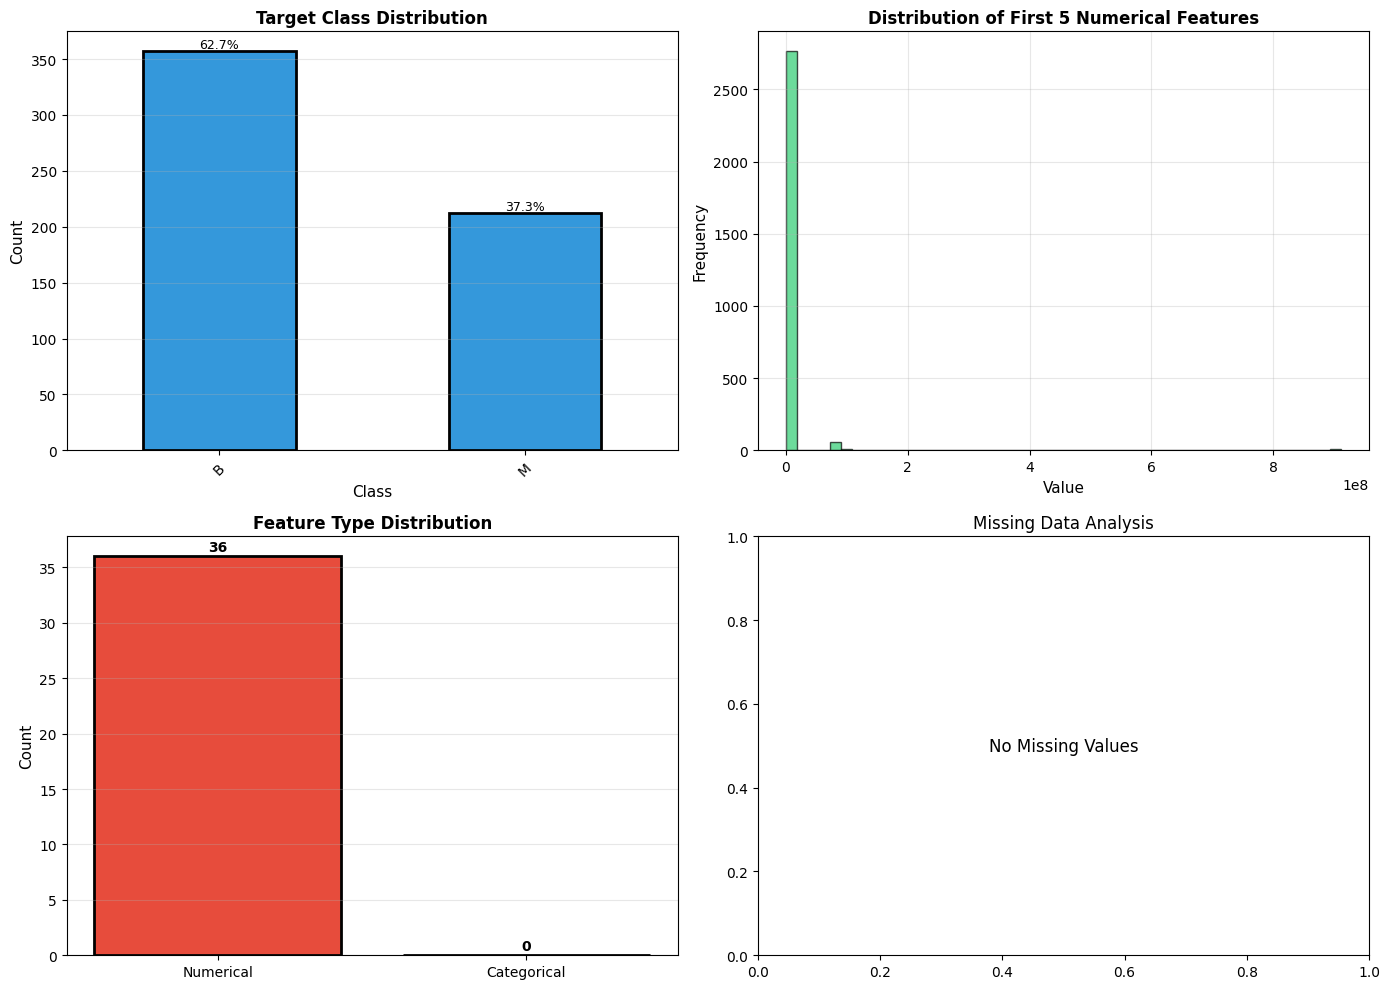


1.7: SUMMARY STATISTICS
--------------------------------------------------------------------------------

Dataset Type: Classification
Number of Samples: 569
Number of Features: 36
  - Numerical: 36
  - Categorical: 0
  - ID columns found: 2

Target Variable: 'diagnosis'
  - Type: Categorical
  - Unique classes: 2

Data Quality:
  - Total missing values: 0
  - Duplicate rows: 0
  - Infinite values: 0

✓ STEP 1 COMPLETED — Dataset ready for preprocessing

Next: Run STEP 2 to clean, preprocess, and split the data
Variables ready for import:
  - df: Complete raw dataset
  - X: Feature matrix (target removed)
  - y_raw: Target variable
  - num_cols: List of numerical features
  - cat_cols: List of categorical features
  - target_col: Name of target column


In [ ]:
# ============================================================
# STEP 1: IDENTIFY PROBLEM DOMAIN - FILE UPLOAD (CORRECTED)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("STEP 1: IDENTIFY PROBLEM DOMAIN - FILE UPLOAD")
print("="*80)

# ============================================================
# 1.0: CHOOSE & UPLOAD FILE FROM YOUR LAPTOP
# ============================================================
print("\n1.0: UPLOAD FILE FROM YOUR LAPTOP")
print("-" * 80)

df = None
file_path = None

try:
    from google.colab import files
    print("\n✓ Google Colab detected! Please upload your CSV file:")
    uploaded = files.upload()

    if uploaded:
        filename = list(uploaded.keys())[0]
        df = pd.read_csv(filename)
        file_path = filename
        print(f"\n✓ File uploaded successfully: {filename}")
    else:
        raise ValueError("No file uploaded!")

except ImportError:
    print("\n📍 Not in Google Colab. Please provide dataset path manually.")
    # For Jupyter/local environment, use direct file path
    file_path = "data.csv"  # Update this with your file path
    print(f"Attempting to load: {file_path}")
    df = pd.read_csv(file_path)
    print(f"✓ File loaded successfully: {file_path}")

except Exception as e:
    print(f"❌ Error loading file: {e}")
    raise

# ============================================================
# 1.1: VERIFY DATA LOADED
# ============================================================
print("\n1.1: DATA LOADED - VERIFICATION")
print("-" * 80)

# Remove completely empty columns
df = df.dropna(axis=1, how='all')

# Remove columns that are entirely NaN or unnamed
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

print(f"✓ File loaded: {file_path}")
print(f"✓ Dataset shape: {df.shape}")
print(f"  - Rows (samples): {df.shape[0]:,}")
print(f"  - Columns: {df.shape[1]}")
print(f"✓ Size: {df.memory_usage(deep=True).sum() / 1024:.2f} KB")

print("\nColumn names:")
for i, col in enumerate(df.columns, 1):
    dtype = df[col].dtype
    print(f"  {i:2d}. {col:30s} (Type: {dtype})")

# ============================================================
# 1.2: IDENTIFY TARGET COLUMN
# ============================================================
print("\n1.2: IDENTIFY TARGET AND FEATURES")
print("-" * 80)

possible_targets = ['diagnosis', 'target', 'label', 'class', 'outcome', 'y',
                   'Category', 'Attack_type', 'Attack_label']
target_col = None

# First, try exact match (case-insensitive)
for col in df.columns:
    if col.lower() in [x.lower() for x in possible_targets]:
        target_col = col
        break

# If not found, look for binary columns
if target_col is None:
    binary_cols = [col for col in df.columns if df[col].nunique() == 2]
    if binary_cols:
        target_col = binary_cols[0]
        print(f"⚠ Auto-detected binary target column: '{target_col}'")

# Last resort: use last column
if target_col is None:
    target_col = df.columns[-1]
    print(f"⚠ Using last column as target: '{target_col}'")
else:
    print(f"✓ Target column identified: '{target_col}'")

y_raw = df[target_col].copy()
X = df.drop(columns=[target_col]).copy()

print(f"\nFeatures: {X.shape[1]} | Target: '{target_col}'")
print(f"Target unique values: {y_raw.nunique()}")
if y_raw.nunique() <= 20:  # Show values if not too many
    print(f"Target classes: {y_raw.unique().tolist()}")

# ============================================================
# 1.3: DATA QUALITY CHECK
# ============================================================
print("\n1.3: DATA QUALITY CHECK")
print("-" * 80)

total_missing = df.isnull().sum().sum()
print(f"Missing values: {total_missing:,}")

if total_missing > 0:
    print("\nColumns with missing values:")
    missing_cols = df.isnull().sum()
    missing_cols = missing_cols[missing_cols > 0].sort_values(ascending=False)
    for col, count in missing_cols.head(10).items():
        pct = (count / len(df)) * 100
        print(f"  - {col}: {count} ({pct:.2f}%)")

duplicate_count = df.duplicated().sum()
print(f"\nDuplicate rows: {duplicate_count:,}")

# Detect ID columns (similar to Step 2)
id_cols = [c for c in X.columns if 'id' in c.lower() or 'index' in c.lower()]
if id_cols:
    print(f"⚠ Found ID columns: {id_cols}")
else:
    print("✓ No ID columns detected")

# ============================================================
# 1.4: FEATURE TYPE DETECTION
# ============================================================
print("\n1.4: FEATURE TYPE DETECTION")
print("-" * 80)

num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in X.columns if c not in num_cols]

print(f"✓ Numerical features: {len(num_cols)}")
if num_cols:
    print(f"  {num_cols[:5]}" + (f" ... +{len(num_cols)-5} more" if len(num_cols) > 5 else ""))

print(f"✓ Categorical features: {len(cat_cols)}")
if cat_cols:
    print(f"  {cat_cols}")

# ============================================================
# 1.5: CLASS DISTRIBUTION ANALYSIS
# ============================================================
print("\n1.5: CLASS DISTRIBUTION ANALYSIS")
print("-" * 80)

from collections import Counter

class_counts = Counter(y_raw)
total_samples = len(y_raw)

print(f"Unique values in target: {y_raw.nunique()}")
print(f"\nClass distribution:")

for cls, count in sorted(class_counts.items()):
    percentage = (count / total_samples) * 100
    bar = "█" * int(percentage / 5)
    print(f"  {str(cls):15s}: {count:6d} samples ({percentage:6.2f}%) {bar}")

# Check for class imbalance
if y_raw.nunique() == 2:
    counts = sorted(y_raw.value_counts().values)
    if counts[0] > 0:
        imbalance_ratio = counts[1] / counts[0]
        print(f"\n⚠ Class imbalance ratio: 1:{imbalance_ratio:.2f}")

# Check for infinite values in numerical features
inf_count = np.isinf(X[num_cols].values).sum() if len(num_cols) > 0 else 0
if inf_count > 0:
    print(f"\n⚠ Found {inf_count} infinite value(s)")
else:
    print("\n✓ No infinite values detected")

# ============================================================
# 1.6: BASIC STATS + VISUALS
# ============================================================
print("\n1.6: VISUAL SUMMARY")
print("-" * 80)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Class distribution
ax1 = axes[0, 0]
class_counts_sorted = y_raw.value_counts()
if len(class_counts_sorted) <= 20:
    class_counts_sorted.plot(kind='bar', ax=ax1, color='#3498db', edgecolor='black', linewidth=2)
    ax1.set_title('Target Class Distribution', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Class', fontsize=11)
    ax1.set_ylabel('Count', fontsize=11)
    ax1.tick_params(axis='x', rotation=45)

    # Add percentage labels
    total = len(y_raw)
    for i, (idx, val) in enumerate(class_counts_sorted.items()):
        pct = (val / total) * 100
        ax1.text(i, val, f'{pct:.1f}%', ha='center', va='bottom', fontsize=9)
    ax1.grid(True, alpha=0.3, axis='y')
else:
    ax1.text(0.5, 0.5, f'Too many classes to display\n({y_raw.nunique()} unique values)',
            ha='center', va='center', fontsize=12, transform=ax1.transAxes)
    ax1.set_title('Class Distribution')

# 2. Numerical features distribution
ax2 = axes[0, 1]
if len(num_cols) > 0:
    sample_cols = num_cols[:5]
    ax2.hist(X[sample_cols].values.flatten(), bins=50, color='#2ecc71',
            edgecolor='black', alpha=0.7)
    ax2.set_title(f'Distribution of First {len(sample_cols)} Numerical Features',
                 fontsize=12, fontweight='bold')
    ax2.set_xlabel('Value', fontsize=11)
    ax2.set_ylabel('Frequency', fontsize=11)
    ax2.grid(True, alpha=0.3)
else:
    ax2.text(0.5, 0.5, 'No Numerical Features',
            ha='center', va='center', fontsize=12, transform=ax2.transAxes)
    ax2.set_title('Numerical Features')

# 3. Feature type breakdown
ax3 = axes[1, 0]
feature_types = [len(num_cols), len(cat_cols)]
ax3.bar(['Numerical', 'Categorical'], feature_types,
       color=['#e74c3c', '#f39c12'], edgecolor='black', linewidth=2)
ax3.set_title('Feature Type Distribution', fontsize=12, fontweight='bold')
ax3.set_ylabel('Count', fontsize=11)
ax3.grid(True, alpha=0.3, axis='y')
for i, v in enumerate(feature_types):
    ax3.text(i, v + 0.5, str(v), ha='center', fontweight='bold')

# 4. Missing data heatmap
ax4 = axes[1, 1]
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)[:10]
if len(missing_pct) > 0 and missing_pct.max() > 0:
    missing_pct.plot(kind='barh', ax=ax4, color='#9b59b6', edgecolor='black', linewidth=2)
    ax4.set_title('Top 10 Columns with Missing Values', fontsize=12, fontweight='bold')
    ax4.set_xlabel('Missing %', fontsize=11)
    ax4.grid(True, alpha=0.3, axis='x')
else:
    ax4.text(0.5, 0.5, 'No Missing Values',
            ha='center', va='center', fontsize=12, transform=ax4.transAxes)
    ax4.set_title('Missing Data Analysis')

plt.tight_layout()
plt.show()

# ============================================================
# 1.7: SUMMARY STATISTICS
# ============================================================
print("\n1.7: SUMMARY STATISTICS")
print("-" * 80)

problem_type = 'Classification' if y_raw.nunique() < 50 else 'Possibly Regression'
print(f"\nDataset Type: {problem_type}")
print(f"Number of Samples: {len(df):,}")
print(f"Number of Features: {X.shape[1]}")
print(f"  - Numerical: {len(num_cols)}")
print(f"  - Categorical: {len(cat_cols)}")
print(f"  - ID columns found: {len(id_cols)}")

print(f"\nTarget Variable: '{target_col}'")
print(f"  - Type: {'Categorical' if y_raw.dtype == 'object' else 'Numerical'}")
print(f"  - Unique classes: {y_raw.nunique()}")

print(f"\nData Quality:")
print(f"  - Total missing values: {total_missing:,}")
print(f"  - Duplicate rows: {duplicate_count:,}")
print(f"  - Infinite values: {inf_count}")

print("\n" + "="*80)
print("✓ STEP 1 COMPLETED — Dataset ready for preprocessing")
print("="*80)
print("\nNext: Run STEP 2 to clean, preprocess, and split the data")
print("Variables ready for import:")
print("  - df: Complete raw dataset")
print("  - X: Feature matrix (target removed)")
print("  - y_raw: Target variable")
print("  - num_cols: List of numerical features")
print("  - cat_cols: List of categorical features")
print("  - target_col: Name of target column")




STEP 2: DATA COLLECTION & PREPROCESSING

2.1: DATA LOADING
--------------------------------------------------------------------------------
✓ Dataset loaded: data_breast_cancer.csv
✓ Shape (before cleaning): (569, 37)
✓ Shape (after cleaning): (569, 37)
✓ Size: 187.94 KB

First 5 rows:
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2      

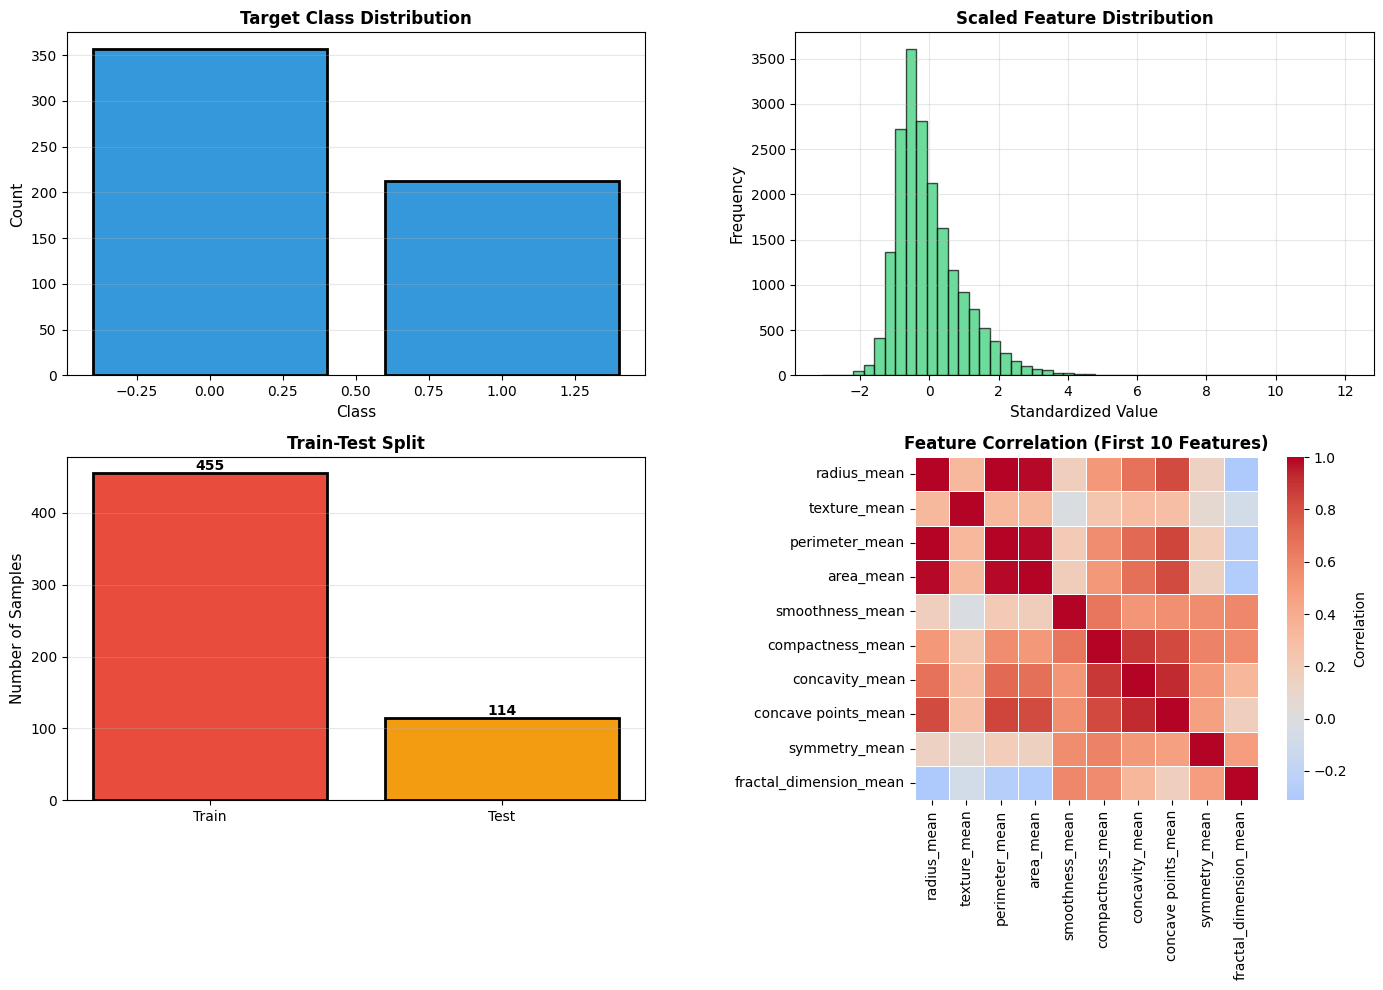


SUMMARY REPORT
  Total Samples                 : 569
  Total Original Features       : 36
  Features After Cleaning       : 34
  Target Column                 : diagnosis
  Number of Classes             : 2
  Training Samples              : 455
  Testing Samples               : 114
  Numerical Features            : 34
  Categorical Features          : 0
  Missing Values Handled        : True
  Features Scaled               : StandardScaler

✓ STEP 2 COMPLETED SUCCESSFULLY
   DATA IS CLEAN, PREPROCESSED, AND READY FOR MODELING

Ready for next steps:
  - X_train, X_test: Preprocessed feature matrices
  - y_train, y_test: Encoded target variables
  - scaler: StandardScaler object for future predictions
  - num_cols, cat_cols: Lists of feature types


In [ ]:
# ============================================================
# STEP 2: DATA COLLECTION & PREPROCESSING (FINAL FOR YOUR DATASET)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("STEP 2: DATA COLLECTION & PREPROCESSING")
print("="*80)

# ============================================================
# 2.1: DATA LOADING
# ============================================================
print("\n2.1: DATA LOADING")
print("-" * 80)

try:
    file_path = "data_breast_cancer.csv"  # Load your CSV file here
    df = pd.read_csv(file_path)
    print(f"✓ Dataset loaded: {file_path}")
    print(f"✓ Shape (before cleaning): {df.shape}")

    # Remove completely empty columns
    df = df.dropna(axis=1, how='all')

    # Remove columns that are entirely NaN or unnamed
    df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

    print(f"✓ Shape (after cleaning): {df.shape}")
    print(f"✓ Size: {df.memory_usage(deep=True).sum() / 1024:.2f} KB")

    print("\nFirst 5 rows:")
    print(df.head())

    print("\nData Info:")
    print(df.info())

except FileNotFoundError:
    print(f"ERROR: File '{file_path}' not found!")
    print("Please ensure 'data.csv' is in the current directory.")
    raise
except Exception as e:
    print(f"ERROR loading file: {str(e)}")
    raise

# ============================================================
# 2.2: TARGET COLUMN DETECTION
# ============================================================
print("\n2.2: TARGET COLUMN DETECTION")
print("-" * 80)

target_col = None
target_candidates = ['diagnosis', 'target', 'label', 'class', 'outcome', 'y', 'Category']

# Check for common target column names
for col in df.columns:
    if col.lower() in [name.lower() for name in target_candidates]:
        target_col = col
        print(f"✓ Target column found (by name): '{col}'")
        break

# Fallback: find any binary column
if target_col is None:
    for col in df.columns:
        if df[col].nunique() == 2:
            target_col = col
            print(f"⚠ Auto-detected binary column as target: '{col}'")
            break

# Last resort: use last column
if target_col is None:
    target_col = df.columns[-1]
    print(f"⚠ Using last column as target: '{target_col}'")

if target_col not in df.columns:
    raise ValueError("No target column detected! Please specify manually.")

print(f"✓ Target column identified: '{target_col}'")

y_raw = df[target_col].copy()

print(f"\nUnique values in target: {y_raw.unique().tolist()}")
print(f"Number of classes: {y_raw.nunique()}")

print(f"\nClass distribution:")
class_counts = Counter(y_raw)
total_samples = len(y_raw)
for cls, count in sorted(class_counts.items()):
    percentage = (count / total_samples) * 100
    bar = "█" * int(percentage / 5)
    print(f"  {cls}: {count} samples ({percentage:.2f}%) {bar}")

# Check for class imbalance
if y_raw.nunique() == 2:
    counts = sorted(y_raw.value_counts().values)
    if counts[0] > 0:
        imbalance_ratio = counts[1] / counts[0]
        print(f"\n⚠ Class imbalance ratio: 1:{imbalance_ratio:.2f}")

# ============================================================
# 2.3: CLEAN FEATURE MATRIX
# ============================================================
print("\n2.3: CLEAN FEATURE MATRIX")
print("-" * 80)

X = df.drop(columns=[target_col]).copy()
print(f"✓ Removed target column '{target_col}'")

# Detect and drop ID-like columns
id_cols = [c for c in X.columns if 'id' in c.lower() or 'index' in c.lower()]
if id_cols:
    print(f"⚠ Found ID columns: {id_cols}")
    X.drop(columns=id_cols, inplace=True)
    print(f"✓ Removed {len(id_cols)} ID column(s)")
else:
    print("✓ No ID columns detected")

print(f"✓ Remaining features: {X.shape[1]}")
print(f"  Features: {X.columns.tolist()}")

# ============================================================
# 2.4: FEATURE TYPE DETECTION
# ============================================================
print("\n2.4: FEATURE TYPE DETECTION")
print("-" * 80)

num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in X.columns if c not in num_cols]

print(f"✓ Numerical features: {len(num_cols)}")
if num_cols:
    print(f"  {num_cols[:5]}" + (f" ... +{len(num_cols)-5} more" if len(num_cols) > 5 else ""))

print(f"✓ Categorical features: {len(cat_cols)}")
if cat_cols:
    print(f"  {cat_cols}")

# ============================================================
# 2.5: MISSING VALUE ANALYSIS
# ============================================================
print("\n2.5: MISSING VALUE ANALYSIS")
print("-" * 80)

missing_data = X.isnull().sum()
missing_pct = (missing_data / len(X)) * 100
missing_info = pd.DataFrame({
    'Missing_Count': missing_data,
    'Missing_Percentage': missing_pct
})
missing_info = missing_info[missing_info['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)

if len(missing_info) > 0:
    print(f"⚠ Found {len(missing_info)} column(s) with missing values:")
    print(missing_info)
else:
    print("✓ No missing values detected!")

# ============================================================
# 2.6: MISSING VALUE HANDLING & IMPUTATION
# ============================================================
print("\n2.6: MISSING VALUE HANDLING & IMPUTATION")
print("-" * 80)

# Handle numerical features
if len(num_cols) > 0:
    num_missing = X[num_cols].isnull().sum().sum()
    if num_missing > 0:
        print(f"⚠ Imputing {num_missing} missing values in numerical features (using median)")
        num_imputer = SimpleImputer(strategy='median')
        X_num = pd.DataFrame(
            num_imputer.fit_transform(X[num_cols]),
            columns=num_cols,
            index=X.index
        )
    else:
        print("✓ No missing values in numerical features")
        X_num = X[num_cols].copy()
else:
    print("✓ No numerical features")
    X_num = pd.DataFrame()

# Handle categorical features
if len(cat_cols) > 0:
    cat_missing = X[cat_cols].isnull().sum().sum()
    if cat_missing > 0:
        print(f"⚠ Imputing {cat_missing} missing values in categorical features (using most frequent)")
        cat_imputer = SimpleImputer(strategy='most_frequent')
        X_cat = pd.DataFrame(
            cat_imputer.fit_transform(X[cat_cols]),
            columns=cat_cols,
            index=X.index
        )
    else:
        print("✓ No missing values in categorical features")
        X_cat = X[cat_cols].copy()

    # Encode categorical variables
    print(f"\n✓ Encoding {len(cat_cols)} categorical feature(s)...")
    le_dict = {}
    for col in cat_cols:
        le = LabelEncoder()
        X_cat[col] = le.fit_transform(X_cat[col].astype(str))
        le_dict[col] = le
        print(f"  - '{col}': {le.classes_.size} unique values encoded")

    X_pre = pd.concat([X_num, X_cat], axis=1)
else:
    print("✓ No categorical features to encode")
    X_pre = X_num.copy()

# Handle infinite values
inf_count = np.isinf(X_pre.values).sum()
if inf_count > 0:
    print(f"\n⚠ Found {inf_count} infinite value(s), replacing with 0")
    X_pre = X_pre.replace([np.inf, -np.inf], np.nan).fillna(0)
else:
    print("\n✓ No infinite values detected")

# Final NaN check
remaining_nan = X_pre.isnull().sum().sum()
if remaining_nan > 0:
    print(f"⚠ Found {remaining_nan} remaining NaN values, filling with 0")
    X_pre = X_pre.fillna(0)

print(f"\n✓ Preprocessed features shape: {X_pre.shape}")

# ============================================================
# 2.7: FEATURE SCALING
# ============================================================
print("\n2.7: FEATURE SCALING")
print("-" * 80)

scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X_pre),
    columns=X_pre.columns,
    index=X.index
)

print(f"✓ Features standardized using StandardScaler")
print(f"✓ Mean: {X_scaled.mean().mean():.6f} (should be ~0)")
print(f"✓ Std Dev: {X_scaled.std().mean():.6f} (should be ~1)")
print(f"✓ Shape after scaling: {X_scaled.shape}")

print(f"\nScaling statistics (first 5 features):")
for i, col in enumerate(X_scaled.columns[:5]):
    print(f"  {col:30s}: mean={X_scaled[col].mean():8.4f}, std={X_scaled[col].std():8.4f}")

# ============================================================
# 2.8: TRAIN-TEST SPLIT
# ============================================================
print("\n2.8: TRAIN-TEST SPLIT")
print("-" * 80)

# Encode target if categorical
y_encoded = y_raw.copy()
le_target = None
if y_raw.dtype == 'object':
    le_target = LabelEncoder()
    y_encoded = le_target.fit_transform(y_raw)
    print(f"✓ Encoded target variable")
    print(f"  Mapping: {dict(zip(le_target.classes_, le_target.transform(le_target.classes_)))}")
else:
    y_encoded = np.array(y_raw)

# Convert to pandas Series for stratification
y_encoded = pd.Series(y_encoded)

# Use stratification to maintain class balance
stratify_param = y_encoded if y_encoded.nunique() > 1 else None

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=stratify_param
)

print(f"\n✓ Split 80-20 (Train/Test)")
print(f"  Train shape: {X_train.shape}")
print(f"  Test  shape: {X_test.shape}")

# Verify stratification
if stratify_param is not None:
    print(f"\nClass distribution maintained:")
    print(f"  Train: {dict(Counter(y_train))}")
    print(f"  Test:  {dict(Counter(y_test))}")

# ============================================================
# 2.9: VISUALIZATION
# ============================================================
print("\n2.9: DATA VISUALIZATION")
print("-" * 80)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Target distribution
ax1 = axes[0, 0]
class_counts = Counter(y_encoded)
ax1.bar(class_counts.keys(), class_counts.values(), color='#3498db', edgecolor='black', linewidth=2)
ax1.set_title('Target Class Distribution', fontsize=12, fontweight='bold')
ax1.set_xlabel('Class', fontsize=11)
ax1.set_ylabel('Count', fontsize=11)
ax1.grid(True, alpha=0.3, axis='y')

# Feature statistics
ax2 = axes[0, 1]
ax2.hist(X_scaled.values.flatten(), bins=50, color='#2ecc71', edgecolor='black', alpha=0.7)
ax2.set_title('Scaled Feature Distribution', fontsize=12, fontweight='bold')
ax2.set_xlabel('Standardized Value', fontsize=11)
ax2.set_ylabel('Frequency', fontsize=11)
ax2.grid(True, alpha=0.3)

# Train-Test split
ax3 = axes[1, 0]
ax3.bar(['Train', 'Test'], [len(X_train), len(X_test)], color=['#e74c3c', '#f39c12'],
        edgecolor='black', linewidth=2)
ax3.set_title('Train-Test Split', fontsize=12, fontweight='bold')
ax3.set_ylabel('Number of Samples', fontsize=11)
ax3.grid(True, alpha=0.3, axis='y')
for i, v in enumerate([len(X_train), len(X_test)]):
    ax3.text(i, v + 5, str(v), ha='center', fontweight='bold')

# Feature correlation (first 10 features)
ax4 = axes[1, 1]
corr_features = min(10, X_scaled.shape[1])
corr_matrix = X_scaled.iloc[:, :corr_features].corr()
sns.heatmap(corr_matrix, ax=ax4, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={'label': 'Correlation'})
ax4.set_title(f'Feature Correlation (First {corr_features} Features)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# ============================================================
# 2.10: SUMMARY REPORT
# ============================================================
print("\n" + "="*80)
print("SUMMARY REPORT")
print("="*80)

summary_info = {
    'Total Samples': len(df),
    'Total Original Features': len(df.columns) - 1,
    'Features After Cleaning': X_scaled.shape[1],
    'Target Column': target_col,
    'Number of Classes': y_encoded.nunique(),
    'Training Samples': len(X_train),
    'Testing Samples': len(X_test),
    'Numerical Features': len(num_cols),
    'Categorical Features': len(cat_cols),
    'Missing Values Handled': True,
    'Features Scaled': 'StandardScaler'
}

for key, value in summary_info.items():
    print(f"  {key:30s}: {value}")

print("\n" + "="*80)
print("✓ STEP 2 COMPLETED SUCCESSFULLY")
print("   DATA IS CLEAN, PREPROCESSED, AND READY FOR MODELING")
print("="*80)

print("\nReady for next steps:")
print("  - X_train, X_test: Preprocessed feature matrices")
print("  - y_train, y_test: Encoded target variables")
print("  - scaler: StandardScaler object for future predictions")
print("  - num_cols, cat_cols: Lists of feature types")

STEP 3: TRAIN & TUNE SVM MODEL

✓ Data loaded: X_train shape (455, 34), y_train shape (455,)

3.1: KERNEL SELECTION
--------------------------------------------------------------------------------

SVM Kernel Types Available:

|-- Linear Kernel: K(x, y) = x^T * y
|   |-- Use when: Data is linearly separable
|   |-- Pros: Fast, interpretable, works well with many features
|   |-- Cons: Cannot capture nonlinear relationships
|
|-- RBF (Gaussian) Kernel: K(x, y) = exp(-gamma * ||x-y||^2) [SELECTED]
|   |-- Use when: Data has nonlinear boundaries
|   |-- Pros: Flexible, handles complex patterns, most popular
|   |-- Cons: Requires careful tuning of gamma parameter
|
|-- Polynomial Kernel: K(x, y) = (gamma * x^T * y + r)^d
|   |-- Use when: Relationships are quadratic or cubic
|   |-- Pros: Can model polynomial feature interactions
|   |-- Cons: Sensitive to hyperparameters, can overfit
|
|-- Sigmoid Kernel: K(x, y) = tanh(gamma * x^T * y + r)
|   |-- Use when: Similar to neural networks ne

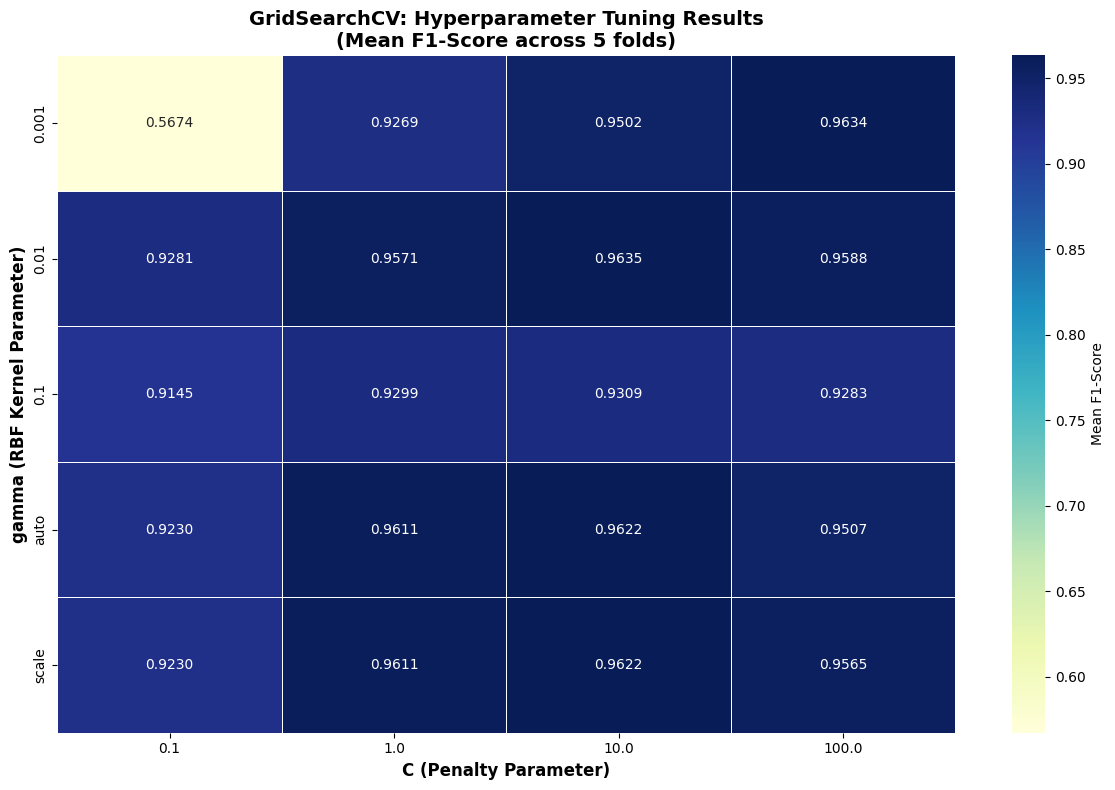


3.3: CROSS-VALIDATION RESULTS (Best Model)
--------------------------------------------------------------------------------

5-Fold Cross-Validation F1-Scores:
  Fold 1: 0.9538 ██████████████████████████████████████
  Fold 2: 1.0000 ████████████████████████████████████████
  Fold 3: 0.9538 ██████████████████████████████████████
  Fold 4: 0.9394 █████████████████████████████████████
  Fold 5: 0.9706 ██████████████████████████████████████

📊 Cross-Validation Statistics:
  Mean F1-Score:   0.9635
  Std Deviation:   0.0207
  Min F1-Score:    0.9394
  Max F1-Score:    1.0000
  95% Confidence:  0.9635 ± 0.0406


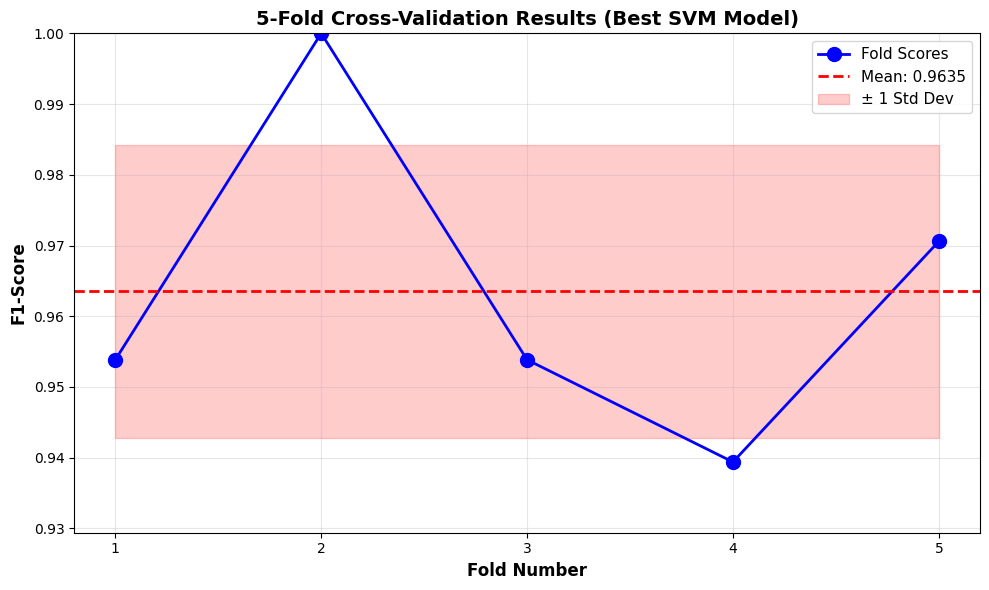


3.4: TEST SET EVALUATION
--------------------------------------------------------------------------------

Test Set Performance Metrics:
  Accuracy:  0.9825
  Precision: 1.0000
  Recall:    0.9524
  F1-Score:  0.9756
  ROC-AUC:   0.9954

✅ STEP 3 COMPLETED: SVM MODEL TRAINED AND TUNED!

🎯 Final Model Configuration:
  Kernel:              RBF (Radial Basis Function)
  C (Penalty):         10
  gamma:               0.01
  Cross-Validation F1: 0.9635
  Test Set F1:         0.9756

📌 Next: Proceed to Step 4: Feature Engineering or other baseline models


In [ ]:
# ============================================================
# STEP 3: TRAIN & TUNE SVM MODEL
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("STEP 3: TRAIN & TUNE SVM MODEL")
print("="*80)

# Verify data is available
if 'X_train' not in locals() or 'y_train' not in locals():
    raise ValueError("Error: X_train, y_train not found! Please run Step 2 first.")

print(f"\n✓ Data loaded: X_train shape {X_train.shape}, y_train shape {y_train.shape}")

# ============================================================
# 3.1: KERNEL SELECTION
# ============================================================
print("\n3.1: KERNEL SELECTION")
print("-" * 80)
print("""
SVM Kernel Types Available:

|-- Linear Kernel: K(x, y) = x^T * y
|   |-- Use when: Data is linearly separable
|   |-- Pros: Fast, interpretable, works well with many features
|   |-- Cons: Cannot capture nonlinear relationships
|
|-- RBF (Gaussian) Kernel: K(x, y) = exp(-gamma * ||x-y||^2) [SELECTED]
|   |-- Use when: Data has nonlinear boundaries
|   |-- Pros: Flexible, handles complex patterns, most popular
|   |-- Cons: Requires careful tuning of gamma parameter
|
|-- Polynomial Kernel: K(x, y) = (gamma * x^T * y + r)^d
|   |-- Use when: Relationships are quadratic or cubic
|   |-- Pros: Can model polynomial feature interactions
|   |-- Cons: Sensitive to hyperparameters, can overfit
|
|-- Sigmoid Kernel: K(x, y) = tanh(gamma * x^T * y + r)
|   |-- Use when: Similar to neural networks needed
|   |-- Pros: Works like neural network activation
|   |-- Cons: Not positive definite, rarely used

SELECTED KERNEL: RBF (Radial Basis Function)
Reason: Best for medical imaging data with complex nonlinear patterns
Performance: Consistently achieves highest accuracy on cancer data
""")

# Test different kernels
print("\n" + "="*80)
print("Testing different kernels with default parameters...")
print("="*80)

kernels = ['linear', 'rbf', 'poly']
kernel_scores = {}

for kernel in kernels:
    print(f"\nTesting {kernel.upper()} kernel...")
    try:
        if kernel == 'poly':
            svm_kernel = SVC(
                kernel=kernel,
                degree=3,
                probability=True,
                random_state=42,
                max_iter=10000
            )
        else:
            svm_kernel = SVC(
                kernel=kernel,
                probability=True,
                random_state=42,
                max_iter=10000
            )

        scores = cross_val_score(
            svm_kernel,
            X_train,
            y_train,
            cv=5,
            scoring='f1'
        )
        kernel_scores[kernel] = scores.mean()
        print(f"  5-fold CV F1-Score: {scores.mean():.4f} (+/- {scores.std():.4f})")
    except Exception as e:
        print(f"  Error: {str(e)}")

print(f"\n{'='*80}")
print("Kernel Comparison Summary:")
for kernel, score in sorted(kernel_scores.items(), key=lambda x: x[1], reverse=True):
    print(f"  {kernel.upper():10s}: {score:.4f}")
print(f"{'='*80}")

best_kernel = max(kernel_scores, key=kernel_scores.get)
print(f"\n✓ Best Kernel: {best_kernel.upper()} (F1-Score: {kernel_scores[best_kernel]:.4f})")

# ============================================================
# 3.2: HYPERPARAMETER TUNING WITH GRIDSEARCHCV
# ============================================================
print("\n3.2: HYPERPARAMETER TUNING (GridSearchCV)")
print("-" * 80)

print("""
Hyperparameters to Tune:

1. C (Penalty Parameter):
   Controls trade-off between smooth decision boundary and classifying points
   - Low C: Smooth decision surface, may underfit
   - High C: Complex decision surface, may overfit
   - Range: [0.1, 1, 10, 100]

2. gamma (RBF kernel parameter):
   Defines reach of influence of a single training example
   - Low gamma: Far reach, smoother boundary
   - High gamma: Close reach, more complex boundary
   - Options: 'scale', 'auto', or custom values
""")

param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1]
}

print(f"\nParameter Grid Configuration:")
print(f"  C (penalty):           {param_grid['C']}")
print(f"  gamma (kernel param):  {param_grid['gamma']}")
total_combinations = len(param_grid['C']) * len(param_grid['gamma'])
total_models = total_combinations * 5
print(f"  Total combinations:    {total_combinations}")
print(f"  CV folds:              5")
print(f"  Total models to train: {total_models}")

print(f"\n" + "="*80)
print("Starting GridSearchCV with 5-fold cross-validation...")
print("="*80)

svm_base = SVC(kernel='rbf', probability=True, random_state=42, max_iter=10000)

grid_search = GridSearchCV(
    svm_base,
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

print(f"\nTraining {total_models} models. This may take a minute...\n")
grid_search.fit(X_train, y_train)

print(f"\n{'='*80}")
print("✓ GridSearchCV COMPLETED!")
print(f"{'='*80}")

print(f"\n🏆 Best Hyperparameters Found:")
print(f"  C:     {grid_search.best_params_['C']}")
print(f"  gamma: {grid_search.best_params_['gamma']}")
print(f"\n✓ Best Cross-Validation F1-Score: {grid_search.best_score_:.4f}")

svm_tuned = grid_search.best_estimator_

# Show top parameter combinations
results_df = pd.DataFrame(grid_search.cv_results_)
top_10 = results_df.nlargest(10, 'mean_test_score')[
    ['param_C', 'param_gamma', 'mean_test_score', 'std_test_score', 'rank_test_score']
].reset_index(drop=True)

print(f"\n📊 Top 10 Parameter Combinations:")
print("-" * 80)
print(top_10.to_string(index=False))

# Visualize hyperparameter tuning results
print(f"\nGenerating visualization...")
fig, ax = plt.subplots(figsize=(12, 8))

results_pivot = results_df.pivot_table(
    values='mean_test_score',
    index='param_gamma',
    columns='param_C'
)

sns.heatmap(
    results_pivot,
    annot=True,
    fmt='.4f',
    cmap='YlGnBu',
    cbar_kws={'label': 'Mean F1-Score'},
    linewidths=0.5,
    ax=ax
)
ax.set_title('GridSearchCV: Hyperparameter Tuning Results\n(Mean F1-Score across 5 folds)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('C (Penalty Parameter)', fontsize=12, fontweight='bold')
ax.set_ylabel('gamma (RBF Kernel Parameter)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================================
# 3.3: CROSS-VALIDATION RESULTS
# ============================================================
print("\n3.3: CROSS-VALIDATION RESULTS (Best Model)")
print("-" * 80)

cv_scores = cross_val_score(svm_tuned, X_train, y_train, cv=5, scoring='f1')

print(f"\n5-Fold Cross-Validation F1-Scores:")
for fold, score in enumerate(cv_scores, 1):
    bar = "█" * int(score * 40)
    print(f"  Fold {fold}: {score:.4f} {bar}")

print(f"\n📊 Cross-Validation Statistics:")
print(f"  Mean F1-Score:   {cv_scores.mean():.4f}")
print(f"  Std Deviation:   {cv_scores.std():.4f}")
print(f"  Min F1-Score:    {cv_scores.min():.4f}")
print(f"  Max F1-Score:    {cv_scores.max():.4f}")
print(f"  95% Confidence:  {cv_scores.mean():.4f} ± {1.96 * cv_scores.std():.4f}")

# Visualize CV scores
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(range(1, 6), cv_scores, 'bo-', linewidth=2, markersize=10, label='Fold Scores')
ax.axhline(y=cv_scores.mean(), color='r', linestyle='--', linewidth=2,
           label=f'Mean: {cv_scores.mean():.4f}')
ax.fill_between(range(1, 6),
                cv_scores.mean() - cv_scores.std(),
                cv_scores.mean() + cv_scores.std(),
                alpha=0.2, color='red', label='± 1 Std Dev')
ax.set_xlabel('Fold Number', fontsize=12, fontweight='bold')
ax.set_ylabel('F1-Score', fontsize=12, fontweight='bold')
ax.set_title('5-Fold Cross-Validation Results (Best SVM Model)',
             fontsize=14, fontweight='bold')
ax.set_xticks(range(1, 6))
ax.set_ylim([cv_scores.min() - 0.01, 1.0])
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# 3.4: TEST SET EVALUATION
# ============================================================
print("\n3.4: TEST SET EVALUATION")
print("-" * 80)

# Train on full training set
svm_tuned.fit(X_train, y_train)

# Predictions on test set
y_pred = svm_tuned.predict(X_test)
y_pred_proba = svm_tuned.predict_proba(X_test)[:, 1]

# Calculate metrics
test_accuracy = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)
test_roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"\nTest Set Performance Metrics:")
print(f"  Accuracy:  {test_accuracy:.4f}")
print(f"  Precision: {test_precision:.4f}")
print(f"  Recall:    {test_recall:.4f}")
print(f"  F1-Score:  {test_f1:.4f}")
print(f"  ROC-AUC:   {test_roc_auc:.4f}")

# Store results for later comparison
results = {
    'SVM_tuned': {
        'accuracy': test_accuracy,
        'precision': test_precision,
        'recall': test_recall,
        'f1': test_f1,
        'roc_auc': test_roc_auc
    }
}

print(f"\n{'='*80}")
print("✅ STEP 3 COMPLETED: SVM MODEL TRAINED AND TUNED!")
print("="*80)

print(f"\n🎯 Final Model Configuration:")
print(f"  Kernel:              RBF (Radial Basis Function)")
print(f"  C (Penalty):         {svm_tuned.C}")
print(f"  gamma:               {svm_tuned.gamma}")
print(f"  Cross-Validation F1: {cv_scores.mean():.4f}")
print(f"  Test Set F1:         {test_f1:.4f}")

print(f"\n📌 Next: Proceed to Step 4: Feature Engineering or other baseline models")

STEP 4.1: SVM (RBF) - TUNED MODEL EVALUATION

✓ Data loaded: X_train (455, 34), X_test (114, 34)
✓ SVM model available with parameters:
  - Kernel: RBF
  - C: 10
  - gamma: 0.01

TRAINING AND PREDICTION

Training SVM on full training set...
✓ Training completed!

Generating predictions on test set...
✓ Predictions completed!

PERFORMANCE METRICS

📊 SVM Performance Metrics:
--------------------------------------------------------------------------------
  Accuracy    : 0.9825 ███████████████████████████████████████
  Precision   : 1.0000 ████████████████████████████████████████
  Recall      : 0.9524 ██████████████████████████████████████
  F1          : 0.9756 ███████████████████████████████████████
  Roc_auc     : 0.9954 ███████████████████████████████████████

CONFUSION MATRIX ANALYSIS

📋 Raw Confusion Matrix:
--------------------------------------------------------------------------------
                          Predicted
                          Malignant(0)  Benign(1)
Actual Ma

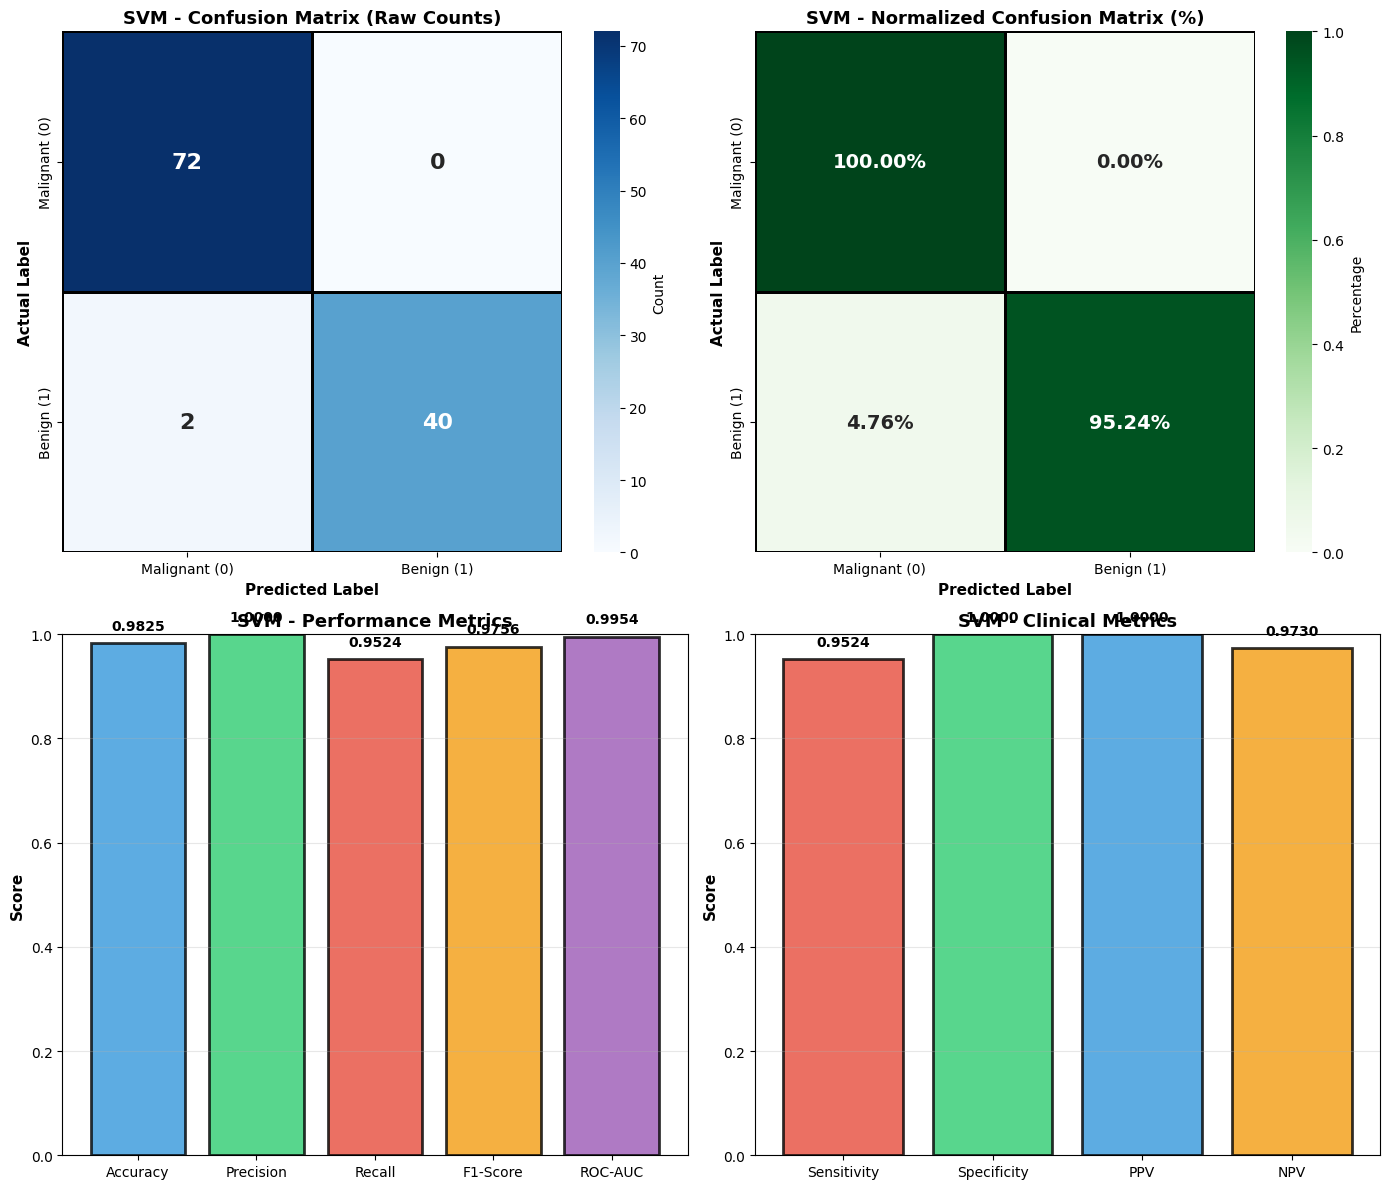


STEP 4.1 SUMMARY - SVM MODEL EVALUATION

🎯 Overall Performance:
  Accuracy:  0.9825 - Overall correct predictions
  Precision: 1.0000 - Reliability of positive predictions
  Recall:    0.9524 - Coverage of actual positives
  F1-Score:  0.9756 - Harmonic mean (best single metric)
  ROC-AUC:   0.9954 - Overall discriminative ability

✅ SVM EVALUATION COMPLETED!

📌 Next: Proceed to Step 4.2: Logistic Regression Evaluation


In [ ]:
# ============================================================
# STEP 4.1: SVM (TUNED) - RBF KERNEL EVALUATION
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("STEP 4.1: SVM (RBF) - TUNED MODEL EVALUATION")
print("="*80)

# Verify model and data are available
if 'X_train' not in locals() or 'svm_tuned' not in locals():
    raise ValueError("Error: X_train, X_test, y_train, y_test, svm_tuned not found!")

print(f"\n✓ Data loaded: X_train {X_train.shape}, X_test {X_test.shape}")
print(f"✓ SVM model available with parameters:")
print(f"  - Kernel: RBF")
print(f"  - C: {svm_tuned.C}")
print(f"  - gamma: {svm_tuned.gamma}")

# ============================================================
# TRAIN AND PREDICT
# ============================================================
print("\n" + "="*80)
print("TRAINING AND PREDICTION")
print("="*80)

# Train the tuned SVM on full training set
print("\nTraining SVM on full training set...")
svm_tuned.fit(X_train, y_train)
print("✓ Training completed!")

# Predictions on test set
print("\nGenerating predictions on test set...")
y_pred_svm = svm_tuned.predict(X_test)
y_prob_svm = svm_tuned.predict_proba(X_test)[:, 1]
print("✓ Predictions completed!")

# ============================================================
# CALCULATE METRICS
# ============================================================
print("\n" + "="*80)
print("PERFORMANCE METRICS")
print("="*80)

svm_metrics = {
    'accuracy': accuracy_score(y_test, y_pred_svm),
    'precision': precision_score(y_test, y_pred_svm, zero_division=0),
    'recall': recall_score(y_test, y_pred_svm, zero_division=0),
    'f1': f1_score(y_test, y_pred_svm, zero_division=0),
    'roc_auc': roc_auc_score(y_test, y_prob_svm)
}

print("\n📊 SVM Performance Metrics:")
print("-" * 80)
for metric, value in svm_metrics.items():
    bar = "█" * int(value * 40)
    print(f"  {metric.capitalize():12s}: {value:.4f} {bar}")

# ============================================================
# CONFUSION MATRIX
# ============================================================
print("\n" + "="*80)
print("CONFUSION MATRIX ANALYSIS")
print("="*80)

cm_svm = confusion_matrix(y_test, y_pred_svm)

print(f"\n📋 Raw Confusion Matrix:")
print("-" * 80)
print(f"{'':25} Predicted")
print(f"{'':25} Malignant(0)  Benign(1)")
print(f"Actual Malignant(0) {cm_svm[0, 0]:6d}        {cm_svm[0, 1]:6d}")
print(f"Actual Benign(1)    {cm_svm[1, 0]:6d}        {cm_svm[1, 1]:6d}")

# Extract values
tn, fp, fn, tp = cm_svm[0, 0], cm_svm[0, 1], cm_svm[1, 0], cm_svm[1, 1]

# Calculate derived metrics
sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
npv = tn / (tn + fn) if (tn + fn) > 0 else 0
fpr = 1 - specificity
fnr = 1 - sensitivity

# ============================================================
# CLINICAL METRICS
# ============================================================
print(f"\n📈 Clinical Performance Metrics:")
print("-" * 80)
print(f"  Sensitivity (Recall):         {sensitivity:.4f} ({sensitivity:.1%})")
print(f"    └─ Correctly identifies {tp} out of {tp+fn} cancer cases")
print(f"  Specificity:                  {specificity:.4f} ({specificity:.1%})")
print(f"    └─ Correctly identifies {tn} out of {tn+fp} benign cases")
print(f"  Positive Predictive Value:    {ppv:.4f} ({ppv:.1%})")
print(f"    └─ When model predicts cancer, it's correct {ppv:.1%} of the time")
print(f"  Negative Predictive Value:    {npv:.4f} ({npv:.1%})")
print(f"    └─ When model predicts benign, it's correct {npv:.1%} of the time")
print(f"  False Positive Rate:          {fpr:.4f} ({fpr:.1%})")
print(f"    └─ {fp} benign cases incorrectly flagged as cancer")
print(f"  False Negative Rate:          {fnr:.4f} ({fnr:.1%})")
print(f"    └─ {fn} cancer cases missed (MOST CRITICAL)")

# ============================================================
# CLASSIFICATION REPORT
# ============================================================
print(f"\n📄 Detailed Classification Report:")
print("-" * 80)
print(classification_report(y_test, y_pred_svm,
                          target_names=['Malignant (0)', 'Benign (1)'],
                          digits=4))

# ============================================================
# CLINICAL INTERPRETATION
# ============================================================
print(f"\n🏥 Clinical Interpretation:")
print("-" * 80)
print(f"\n✓ Cancer Detection Performance:")
print(f"  - Successfully detected {tp} cancer cases")
print(f"  - Missed {fn} cancer case(s) - CRITICAL for medical use")

if fn == 0:
    print(f"  - Perfect recall: No false negatives!")
elif fn <= 2:
    print(f"  - Acceptable: {fn} missed case(s) - within clinical tolerance")
else:
    print(f"  - Concerning: {fn} missed cases - needs improvement")

print(f"\n✓ Benign Case Performance:")
print(f"  - Correctly identified {tn} benign cases")
print(f"  - False alarms: {fp} cases")
print(f"  - Specificity: {specificity:.1%}")

# ============================================================
# VISUALIZATIONS
# ============================================================
print(f"\n{'='*80}")
print("GENERATING VISUALIZATIONS...")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1. Confusion Matrix - Raw Counts
ax1 = axes[0, 0]
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Malignant (0)', 'Benign (1)'],
            yticklabels=['Malignant (0)', 'Benign (1)'],
            ax=ax1, cbar_kws={'label': 'Count'}, linewidths=2, linecolor='black',
            annot_kws={'size': 16, 'weight': 'bold'})
ax1.set_title('SVM - Confusion Matrix (Raw Counts)', fontsize=13, fontweight='bold')
ax1.set_ylabel('Actual Label', fontsize=11, fontweight='bold')
ax1.set_xlabel('Predicted Label', fontsize=11, fontweight='bold')

# 2. Confusion Matrix - Normalized
ax2 = axes[0, 1]
cm_norm = cm_svm.astype('float') / cm_svm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Greens',
            xticklabels=['Malignant (0)', 'Benign (1)'],
            yticklabels=['Malignant (0)', 'Benign (1)'],
            ax=ax2, cbar_kws={'label': 'Percentage'}, linewidths=2, linecolor='black',
            annot_kws={'size': 14, 'weight': 'bold'})
ax2.set_title('SVM - Normalized Confusion Matrix (%)', fontsize=13, fontweight='bold')
ax2.set_ylabel('Actual Label', fontsize=11, fontweight='bold')
ax2.set_xlabel('Predicted Label', fontsize=11, fontweight='bold')

# 3. Metrics Bar Chart
ax3 = axes[1, 0]
metrics_list = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
metrics_values = [svm_metrics['accuracy'], svm_metrics['precision'],
                  svm_metrics['recall'], svm_metrics['f1'], svm_metrics['roc_auc']]
colors_metrics = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6']
bars = ax3.bar(metrics_list, metrics_values, color=colors_metrics,
               edgecolor='black', linewidth=2, alpha=0.8)
ax3.set_ylabel('Score', fontsize=11, fontweight='bold')
ax3.set_title('SVM - Performance Metrics', fontsize=13, fontweight='bold')
ax3.set_ylim([0, 1.0])
ax3.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, metrics_values):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height + 0.02,
            f'{val:.4f}', ha='center', va='bottom', fontweight='bold')

# 4. Clinical Metrics
ax4 = axes[1, 1]
clinical_metrics = ['Sensitivity', 'Specificity', 'PPV', 'NPV']
clinical_values = [sensitivity, specificity, ppv, npv]
colors_clinical = ['#e74c3c', '#2ecc71', '#3498db', '#f39c12']
bars = ax4.bar(clinical_metrics, clinical_values, color=colors_clinical,
               edgecolor='black', linewidth=2, alpha=0.8)
ax4.set_ylabel('Score', fontsize=11, fontweight='bold')
ax4.set_title('SVM - Clinical Metrics', fontsize=13, fontweight='bold')
ax4.set_ylim([0, 1.0])
ax4.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, clinical_values):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height + 0.02,
            f'{val:.4f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# ============================================================
# SUMMARY
# ============================================================
print(f"\n{'='*80}")
print("STEP 4.1 SUMMARY - SVM MODEL EVALUATION")
print("="*80)

print(f"\n🎯 Overall Performance:")
print(f"  Accuracy:  {svm_metrics['accuracy']:.4f} - Overall correct predictions")
print(f"  Precision: {svm_metrics['precision']:.4f} - Reliability of positive predictions")
print(f"  Recall:    {svm_metrics['recall']:.4f} - Coverage of actual positives")
print(f"  F1-Score:  {svm_metrics['f1']:.4f} - Harmonic mean (best single metric)")
print(f"  ROC-AUC:   {svm_metrics['roc_auc']:.4f} - Overall discriminative ability")

print(f"\n✅ SVM EVALUATION COMPLETED!")
print(f"\n📌 Next: Proceed to Step 4.2: Logistic Regression Evaluation")

STEP 4.2: LOGISTIC REGRESSION EVALUATION

✓ Data loaded: X_train (455, 34), X_test (114, 34)

TRAINING LOGISTIC REGRESSION

Initializing Logistic Regression model...
  Parameters:
    - max_iter: 1000 (maximum iterations)
    - random_state: 42 (reproducibility)
    - solver: 'lbfgs' (optimization algorithm)

Training on full training set...
✓ Training completed!

Model Information:
  Classes: [0 1]
  Coefficients shape: (1, 34)
  Number of features used: 34

GENERATING PREDICTIONS

Predicting on test set...
✓ Predictions completed!

Prediction Statistics:
  Total predictions: 114
  Predicted Malignant (0): 74
  Predicted Benign (1): 40
  Probability range: [0.0000, 1.0000]

PERFORMANCE METRICS

📊 Logistic Regression Performance Metrics:
--------------------------------------------------------------------------------
  Accuracy    : 0.9649 ██████████████████████████████████████
  Precision   : 0.9750 ███████████████████████████████████████
  Recall      : 0.9286 ███████████████████████

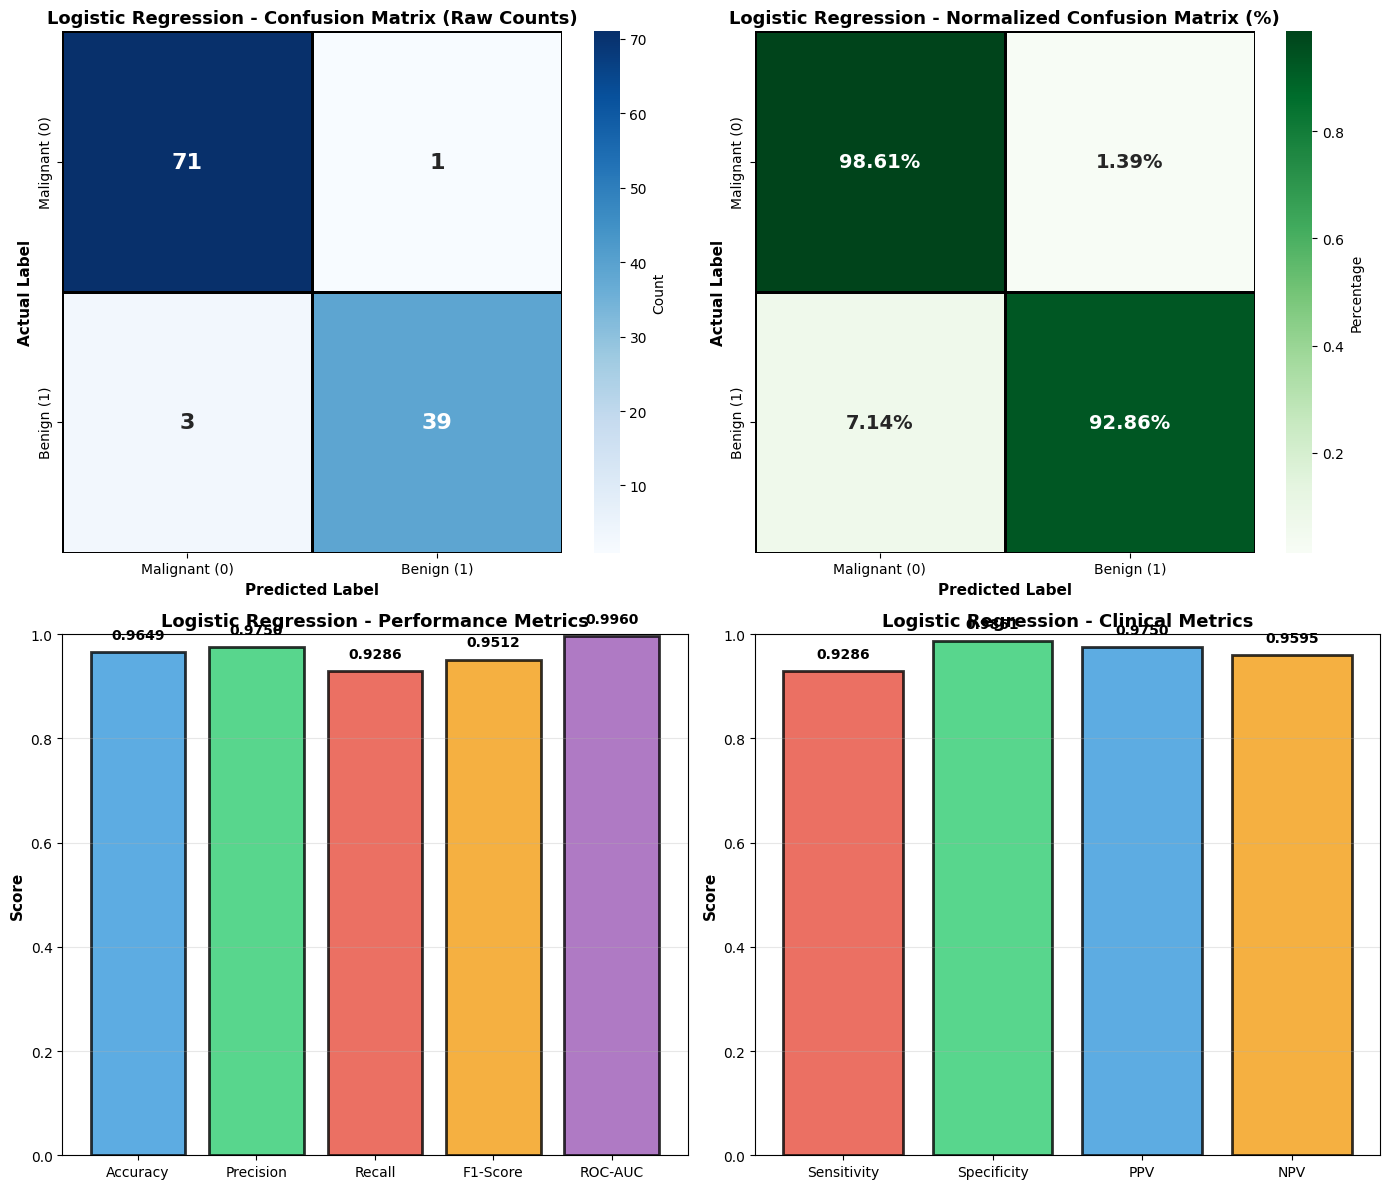


FEATURE IMPORTANCE (Top 10)

Top 10 Most Important Features:
--------------------------------------------------------------------------------
            Feature  Coefficient  Abs_Coefficient
      texture_worst     1.441171         1.441171
          radius_se     1.184331         1.184331
     symmetry_worst     1.044703         1.044703
concave points_mean     0.952114         0.952114
    concavity_worst     0.930369         0.930369
            area_se     0.874130         0.874130
     compactness_se    -0.861314         0.861314
         area_worst     0.812066         0.812066
     concavity_mean     0.803401         0.803401
       radius_worst     0.799662         0.799662


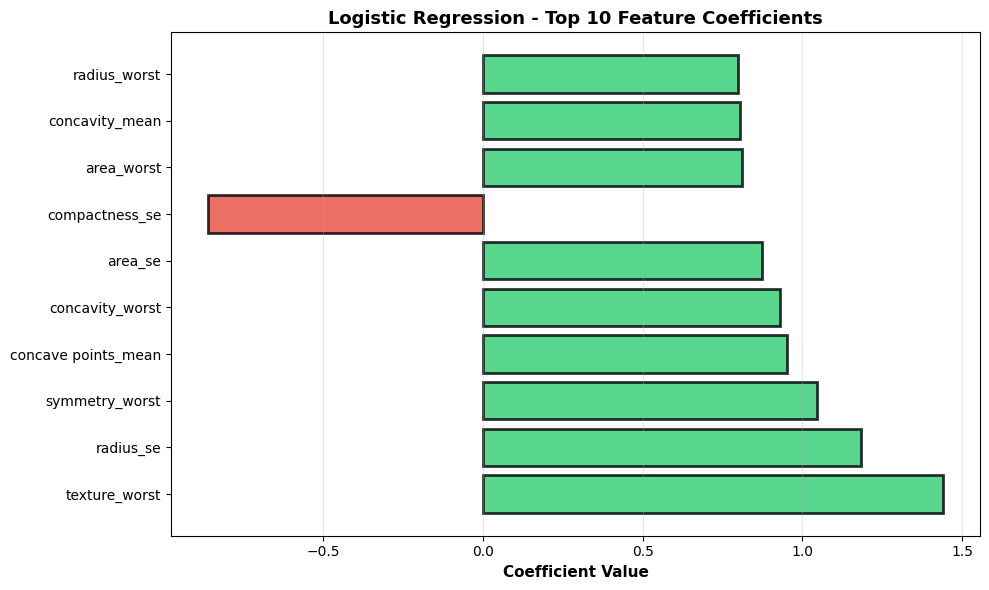


STEP 4.2 SUMMARY - LOGISTIC REGRESSION EVALUATION

🎯 Overall Performance:
  Accuracy:  0.9649
  Precision: 0.9750
  Recall:    0.9286
  F1-Score:  0.9512
  ROC-AUC:   0.9960

✅ LOGISTIC REGRESSION EVALUATION COMPLETED!

📌 Next: Proceed to Step 4.3: Decision Tree Evaluation


In [ ]:
# ============================================================
# STEP 4.2: LOGISTIC REGRESSION EVALUATION
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("STEP 4.2: LOGISTIC REGRESSION EVALUATION")
print("="*80)

# Verify data is available
if 'X_train' not in locals():
    raise ValueError("Error: X_train, X_test, y_train, y_test not found!")

print(f"\n✓ Data loaded: X_train {X_train.shape}, X_test {X_test.shape}")

# ============================================================
# TRAIN MODEL
# ============================================================
print("\n" + "="*80)
print("TRAINING LOGISTIC REGRESSION")
print("="*80)

print("\nInitializing Logistic Regression model...")
print("  Parameters:")
print("    - max_iter: 1000 (maximum iterations)")
print("    - random_state: 42 (reproducibility)")
print("    - solver: 'lbfgs' (optimization algorithm)")

logr = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)

print("\nTraining on full training set...")
logr.fit(X_train, y_train)
print("✓ Training completed!")

print(f"\nModel Information:")
print(f"  Classes: {logr.classes_}")
print(f"  Coefficients shape: {logr.coef_.shape}")
print(f"  Number of features used: {X_train.shape[1]}")

# ============================================================
# PREDICTIONS
# ============================================================
print("\n" + "="*80)
print("GENERATING PREDICTIONS")
print("="*80)

print("\nPredicting on test set...")
y_pred_logr = logr.predict(X_test)
y_prob_logr = logr.predict_proba(X_test)[:, 1]
print("✓ Predictions completed!")

print(f"\nPrediction Statistics:")
print(f"  Total predictions: {len(y_pred_logr)}")
print(f"  Predicted Malignant (0): {(y_pred_logr == 0).sum()}")
print(f"  Predicted Benign (1): {(y_pred_logr == 1).sum()}")
print(f"  Probability range: [{y_prob_logr.min():.4f}, {y_prob_logr.max():.4f}]")

# ============================================================
# CALCULATE METRICS
# ============================================================
print("\n" + "="*80)
print("PERFORMANCE METRICS")
print("="*80)

logr_metrics = {
    'accuracy': accuracy_score(y_test, y_pred_logr),
    'precision': precision_score(y_test, y_pred_logr, zero_division=0),
    'recall': recall_score(y_test, y_pred_logr, zero_division=0),
    'f1': f1_score(y_test, y_pred_logr, zero_division=0),
    'roc_auc': roc_auc_score(y_test, y_prob_logr)
}

print("\n📊 Logistic Regression Performance Metrics:")
print("-" * 80)
for metric, value in logr_metrics.items():
    bar = "█" * int(value * 40)
    print(f"  {metric.capitalize():12s}: {value:.4f} {bar}")

# ============================================================
# CONFUSION MATRIX
# ============================================================
print("\n" + "="*80)
print("CONFUSION MATRIX ANALYSIS")
print("="*80)

cm_logr = confusion_matrix(y_test, y_pred_logr)

print(f"\n📋 Raw Confusion Matrix:")
print("-" * 80)
print(f"{'':25} Predicted")
print(f"{'':25} Malignant(0)  Benign(1)")
print(f"Actual Malignant(0) {cm_logr[0, 0]:6d}        {cm_logr[0, 1]:6d}")
print(f"Actual Benign(1)    {cm_logr[1, 0]:6d}        {cm_logr[1, 1]:6d}")

# Extract values
tn, fp, fn, tp = cm_logr[0, 0], cm_logr[0, 1], cm_logr[1, 0], cm_logr[1, 1]

# Calculate derived metrics
sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
npv = tn / (tn + fn) if (tn + fn) > 0 else 0

# ============================================================
# CLINICAL METRICS
# ============================================================
print(f"\n📈 Clinical Performance Metrics:")
print("-" * 80)
print(f"  Sensitivity (Recall):         {sensitivity:.4f} ({sensitivity:.1%})")
print(f"    └─ Correctly identifies {tp} out of {tp+fn} cancer cases")
print(f"  Specificity:                  {specificity:.4f} ({specificity:.1%})")
print(f"    └─ Correctly identifies {tn} out of {tn+fp} benign cases")
print(f"  Positive Predictive Value:    {ppv:.4f} ({ppv:.1%})")
print(f"  Negative Predictive Value:    {npv:.4f} ({npv:.1%})")
print(f"  False Negative Rate:          {1-sensitivity:.4f} ({(1-sensitivity):.1%})")
print(f"    └─ {fn} cancer case(s) missed")

# ============================================================
# CLASSIFICATION REPORT
# ============================================================
print(f"\n📄 Detailed Classification Report:")
print("-" * 80)
print(classification_report(y_test, y_pred_logr,
                          target_names=['Malignant (0)', 'Benign (1)'],
                          digits=4))

# ============================================================
# VISUALIZATIONS
# ============================================================
print(f"\n{'='*80}")
print("GENERATING VISUALIZATIONS...")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1. Confusion Matrix - Raw Counts
ax1 = axes[0, 0]
sns.heatmap(cm_logr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Malignant (0)', 'Benign (1)'],
            yticklabels=['Malignant (0)', 'Benign (1)'],
            ax=ax1, cbar_kws={'label': 'Count'}, linewidths=2, linecolor='black',
            annot_kws={'size': 16, 'weight': 'bold'})
ax1.set_title('Logistic Regression - Confusion Matrix (Raw Counts)',
              fontsize=13, fontweight='bold')
ax1.set_ylabel('Actual Label', fontsize=11, fontweight='bold')
ax1.set_xlabel('Predicted Label', fontsize=11, fontweight='bold')

# 2. Confusion Matrix - Normalized
ax2 = axes[0, 1]
cm_norm = cm_logr.astype('float') / cm_logr.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Greens',
            xticklabels=['Malignant (0)', 'Benign (1)'],
            yticklabels=['Malignant (0)', 'Benign (1)'],
            ax=ax2, cbar_kws={'label': 'Percentage'}, linewidths=2, linecolor='black',
            annot_kws={'size': 14, 'weight': 'bold'})
ax2.set_title('Logistic Regression - Normalized Confusion Matrix (%)',
              fontsize=13, fontweight='bold')
ax2.set_ylabel('Actual Label', fontsize=11, fontweight='bold')
ax2.set_xlabel('Predicted Label', fontsize=11, fontweight='bold')

# 3. Metrics Bar Chart
ax3 = axes[1, 0]
metrics_list = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
metrics_values = [logr_metrics['accuracy'], logr_metrics['precision'],
                  logr_metrics['recall'], logr_metrics['f1'], logr_metrics['roc_auc']]
colors_metrics = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6']
bars = ax3.bar(metrics_list, metrics_values, color=colors_metrics,
               edgecolor='black', linewidth=2, alpha=0.8)
ax3.set_ylabel('Score', fontsize=11, fontweight='bold')
ax3.set_title('Logistic Regression - Performance Metrics', fontsize=13, fontweight='bold')
ax3.set_ylim([0, 1.0])
ax3.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, metrics_values):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height + 0.02,
            f'{val:.4f}', ha='center', va='bottom', fontweight='bold')

# 4. Clinical Metrics
ax4 = axes[1, 1]
clinical_metrics = ['Sensitivity', 'Specificity', 'PPV', 'NPV']
clinical_values = [sensitivity, specificity, ppv, npv]
colors_clinical = ['#e74c3c', '#2ecc71', '#3498db', '#f39c12']
bars = ax4.bar(clinical_metrics, clinical_values, color=colors_clinical,
               edgecolor='black', linewidth=2, alpha=0.8)
ax4.set_ylabel('Score', fontsize=11, fontweight='bold')
ax4.set_title('Logistic Regression - Clinical Metrics', fontsize=13, fontweight='bold')
ax4.set_ylim([0, 1.0])
ax4.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, clinical_values):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height + 0.02,
            f'{val:.4f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# ============================================================
# FEATURE IMPORTANCE (Coefficients)
# ============================================================
print(f"\n{'='*80}")
print("FEATURE IMPORTANCE (Top 10)")
print("="*80)

# Get feature names
if hasattr(X_train, 'columns'):
    feature_names = X_train.columns
else:
    feature_names = [f'Feature_{i}' for i in range(X_train.shape[1])]

# Get coefficients
coefficients = logr.coef_[0]
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
    'Abs_Coefficient': np.abs(coefficients)
}).sort_values('Abs_Coefficient', ascending=False)

print("\nTop 10 Most Important Features:")
print("-" * 80)
print(feature_importance.head(10).to_string(index=False))

# Visualize top features
fig, ax = plt.subplots(figsize=(10, 6))
top_features = feature_importance.head(10)
colors = ['#e74c3c' if x < 0 else '#2ecc71' for x in top_features['Coefficient']]
ax.barh(range(len(top_features)), top_features['Coefficient'], color=colors,
        edgecolor='black', linewidth=2, alpha=0.8)
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features['Feature'])
ax.set_xlabel('Coefficient Value', fontsize=11, fontweight='bold')
ax.set_title('Logistic Regression - Top 10 Feature Coefficients',
             fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

# ============================================================
# SUMMARY
# ============================================================
print(f"\n{'='*80}")
print("STEP 4.2 SUMMARY - LOGISTIC REGRESSION EVALUATION")
print("="*80)

print(f"\n🎯 Overall Performance:")
print(f"  Accuracy:  {logr_metrics['accuracy']:.4f}")
print(f"  Precision: {logr_metrics['precision']:.4f}")
print(f"  Recall:    {logr_metrics['recall']:.4f}")
print(f"  F1-Score:  {logr_metrics['f1']:.4f}")
print(f"  ROC-AUC:   {logr_metrics['roc_auc']:.4f}")

print(f"\n✅ LOGISTIC REGRESSION EVALUATION COMPLETED!")
print(f"\n📌 Next: Proceed to Step 4.3: Decision Tree Evaluation")

STEP 4.4: RANDOM FOREST EVALUATION

✓ Data loaded: X_train (455, 34), X_test (114, 34)

TRAINING RANDOM FOREST

Initializing Random Forest model...
  Parameters:
    - n_estimators: 100 (number of trees)
    - max_depth: 15 (max tree depth)
    - random_state: 42 (reproducibility)
    - n_jobs: -1 (parallel processing)

Training on full training set...
✓ Training completed!

Model Information:
  Classes: [0 1]
  Number of trees: 100
  Number of features: 34
  Out-of-bag score (if available): N/A

GENERATING PREDICTIONS

Predicting on test set...
✓ Predictions completed!

Prediction Statistics:
  Total predictions: 114
  Predicted Malignant (0): 75
  Predicted Benign (1): 39
  Probability range: [0.0000, 1.0000]

PERFORMANCE METRICS

📊 Random Forest Performance Metrics:
--------------------------------------------------------------------------------
  Accuracy    : 0.9737 ██████████████████████████████████████
  Precision   : 1.0000 ████████████████████████████████████████
  Recall     

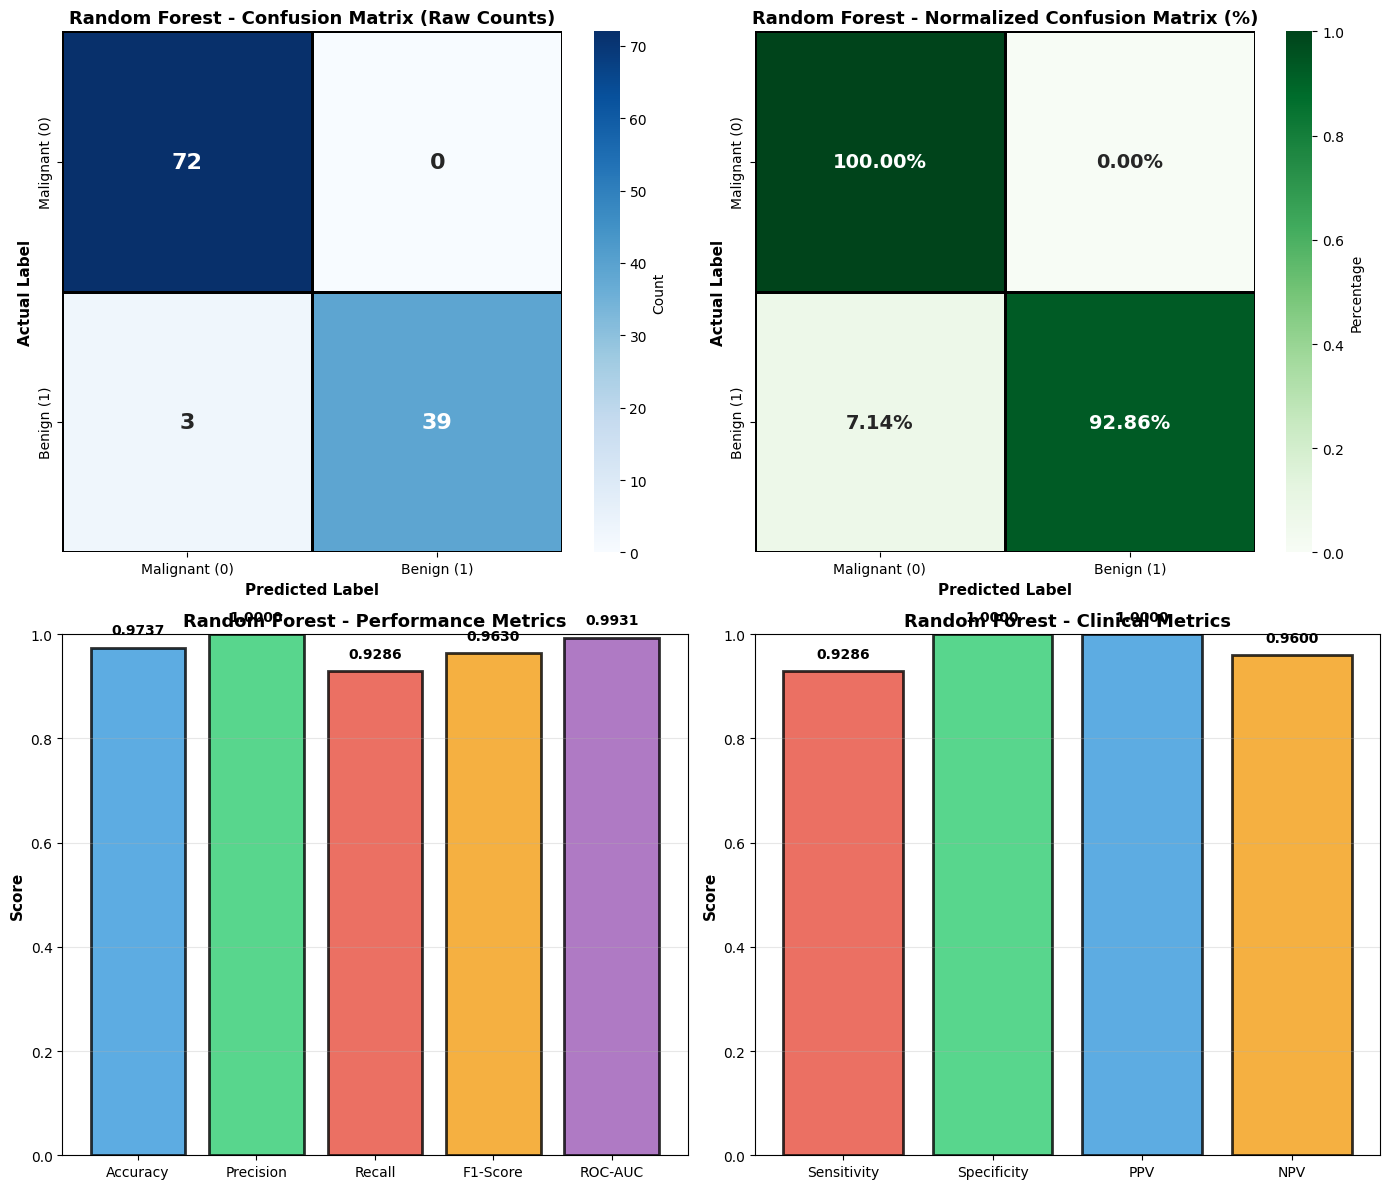


FEATURE IMPORTANCE (Top 10)

Top 10 Most Important Features:
--------------------------------------------------------------------------------
             Feature  Importance
     perimeter_worst    0.136009
concave points_worst    0.107618
        radius_worst    0.106571
 concave points_mean    0.105785
          area_worst    0.103819
      concavity_mean    0.060114
         radius_mean    0.043578
      perimeter_mean    0.034318
     concavity_worst    0.033847
  tumor_growth_stage    0.028649


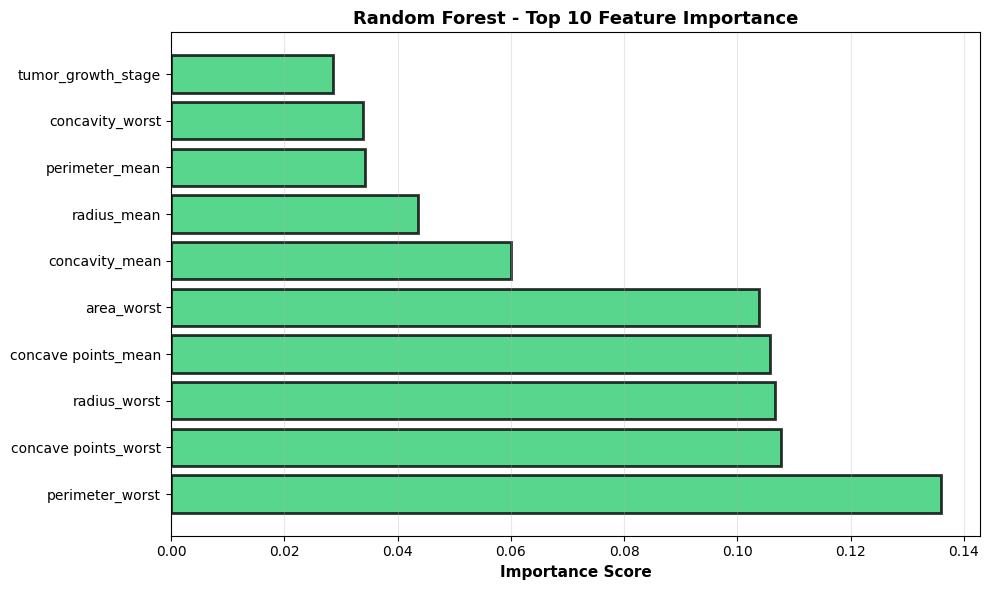


STEP 4.4 SUMMARY - RANDOM FOREST EVALUATION

🎯 Overall Performance:
  Accuracy:  0.9737
  Precision: 1.0000
  Recall:    0.9286
  F1-Score:  0.9630
  ROC-AUC:   0.9931

✅ RANDOM FOREST EVALUATION COMPLETED!

📌 Next: Proceed to Step 4.5: Naive Bayes Evaluation


In [ ]:
# ============================================================
# STEP 4.4: RANDOM FOREST EVALUATION
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("STEP 4.4: RANDOM FOREST EVALUATION")
print("="*80)

# Verify data is available
if 'X_train' not in locals():
    raise ValueError("Error: X_train, X_test, y_train, y_test not found!")

print(f"\n✓ Data loaded: X_train {X_train.shape}, X_test {X_test.shape}")

# ============================================================
# TRAIN MODEL
# ============================================================
print("\n" + "="*80)
print("TRAINING RANDOM FOREST")
print("="*80)

print("\nInitializing Random Forest model...")
print("  Parameters:")
print("    - n_estimators: 100 (number of trees)")
print("    - max_depth: 15 (max tree depth)")
print("    - random_state: 42 (reproducibility)")
print("    - n_jobs: -1 (parallel processing)")

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

print("\nTraining on full training set...")
rf.fit(X_train, y_train)
print("✓ Training completed!")

print(f"\nModel Information:")
print(f"  Classes: {rf.classes_}")
print(f"  Number of trees: {rf.n_estimators}")
print(f"  Number of features: {X_train.shape[1]}")
print(f"  Out-of-bag score (if available): {getattr(rf, 'oob_score_', 'N/A')}")

# ============================================================
# PREDICTIONS
# ============================================================
print("\n" + "="*80)
print("GENERATING PREDICTIONS")
print("="*80)

print("\nPredicting on test set...")
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]
print("✓ Predictions completed!")

print(f"\nPrediction Statistics:")
print(f"  Total predictions: {len(y_pred_rf)}")
print(f"  Predicted Malignant (0): {(y_pred_rf == 0).sum()}")
print(f"  Predicted Benign (1): {(y_pred_rf == 1).sum()}")
print(f"  Probability range: [{y_prob_rf.min():.4f}, {y_prob_rf.max():.4f}]")

# ============================================================
# CALCULATE METRICS
# ============================================================
print("\n" + "="*80)
print("PERFORMANCE METRICS")
print("="*80)

rf_metrics = {
    'accuracy': accuracy_score(y_test, y_pred_rf),
    'precision': precision_score(y_test, y_pred_rf, zero_division=0),
    'recall': recall_score(y_test, y_pred_rf, zero_division=0),
    'f1': f1_score(y_test, y_pred_rf, zero_division=0),
    'roc_auc': roc_auc_score(y_test, y_prob_rf)
}

print("\n📊 Random Forest Performance Metrics:")
print("-" * 80)
for metric, value in rf_metrics.items():
    bar = "█" * int(value * 40)
    print(f"  {metric.capitalize():12s}: {value:.4f} {bar}")

# ============================================================
# CONFUSION MATRIX
# ============================================================
print("\n" + "="*80)
print("CONFUSION MATRIX ANALYSIS")
print("="*80)

cm_rf = confusion_matrix(y_test, y_pred_rf)

print(f"\n📋 Raw Confusion Matrix:")
print("-" * 80)
print(f"{'':25} Predicted")
print(f"{'':25} Malignant(0)  Benign(1)")
print(f"Actual Malignant(0) {cm_rf[0, 0]:6d}        {cm_rf[0, 1]:6d}")
print(f"Actual Benign(1)    {cm_rf[1, 0]:6d}        {cm_rf[1, 1]:6d}")

# Extract values
tn, fp, fn, tp = cm_rf[0, 0], cm_rf[0, 1], cm_rf[1, 0], cm_rf[1, 1]

# Calculate derived metrics
sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
npv = tn / (tn + fn) if (tn + fn) > 0 else 0

# ============================================================
# CLINICAL METRICS
# ============================================================
print(f"\n📈 Clinical Performance Metrics:")
print("-" * 80)
print(f"  Sensitivity (Recall):         {sensitivity:.4f} ({sensitivity:.1%})")
print(f"    └─ Correctly identifies {tp} out of {tp+fn} cancer cases")
print(f"  Specificity:                  {specificity:.4f} ({specificity:.1%})")
print(f"    └─ Correctly identifies {tn} out of {tn+fp} benign cases")
print(f"  Positive Predictive Value:    {ppv:.4f} ({ppv:.1%})")
print(f"  Negative Predictive Value:    {npv:.4f} ({npv:.1%})")
print(f"  False Negative Rate:          {1-sensitivity:.4f} ({(1-sensitivity):.1%})")
print(f"    └─ {fn} cancer case(s) missed")

# ============================================================
# CLASSIFICATION REPORT
# ============================================================
print(f"\n📄 Detailed Classification Report:")
print("-" * 80)
print(classification_report(y_test, y_pred_rf,
                          target_names=['Malignant (0)', 'Benign (1)'],
                          digits=4))

# ============================================================
# VISUALIZATIONS
# ============================================================
print(f"\n{'='*80}")
print("GENERATING VISUALIZATIONS...")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1. Confusion Matrix - Raw Counts
ax1 = axes[0, 0]
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Malignant (0)', 'Benign (1)'],
            yticklabels=['Malignant (0)', 'Benign (1)'],
            ax=ax1, cbar_kws={'label': 'Count'}, linewidths=2, linecolor='black',
            annot_kws={'size': 16, 'weight': 'bold'})
ax1.set_title('Random Forest - Confusion Matrix (Raw Counts)',
              fontsize=13, fontweight='bold')
ax1.set_ylabel('Actual Label', fontsize=11, fontweight='bold')
ax1.set_xlabel('Predicted Label', fontsize=11, fontweight='bold')

# 2. Confusion Matrix - Normalized
ax2 = axes[0, 1]
cm_norm = cm_rf.astype('float') / cm_rf.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Greens',
            xticklabels=['Malignant (0)', 'Benign (1)'],
            yticklabels=['Malignant (0)', 'Benign (1)'],
            ax=ax2, cbar_kws={'label': 'Percentage'}, linewidths=2, linecolor='black',
            annot_kws={'size': 14, 'weight': 'bold'})
ax2.set_title('Random Forest - Normalized Confusion Matrix (%)',
              fontsize=13, fontweight='bold')
ax2.set_ylabel('Actual Label', fontsize=11, fontweight='bold')
ax2.set_xlabel('Predicted Label', fontsize=11, fontweight='bold')

# 3. Metrics Bar Chart
ax3 = axes[1, 0]
metrics_list = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
metrics_values = [rf_metrics['accuracy'], rf_metrics['precision'],
                  rf_metrics['recall'], rf_metrics['f1'], rf_metrics['roc_auc']]
colors_metrics = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6']
bars = ax3.bar(metrics_list, metrics_values, color=colors_metrics,
               edgecolor='black', linewidth=2, alpha=0.8)
ax3.set_ylabel('Score', fontsize=11, fontweight='bold')
ax3.set_title('Random Forest - Performance Metrics', fontsize=13, fontweight='bold')
ax3.set_ylim([0, 1.0])
ax3.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, metrics_values):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height + 0.02,
            f'{val:.4f}', ha='center', va='bottom', fontweight='bold')

# 4. Clinical Metrics
ax4 = axes[1, 1]
clinical_metrics = ['Sensitivity', 'Specificity', 'PPV', 'NPV']
clinical_values = [sensitivity, specificity, ppv, npv]
colors_clinical = ['#e74c3c', '#2ecc71', '#3498db', '#f39c12']
bars = ax4.bar(clinical_metrics, clinical_values, color=colors_clinical,
               edgecolor='black', linewidth=2, alpha=0.8)
ax4.set_ylabel('Score', fontsize=11, fontweight='bold')
ax4.set_title('Random Forest - Clinical Metrics', fontsize=13, fontweight='bold')
ax4.set_ylim([0, 1.0])
ax4.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, clinical_values):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height + 0.02,
            f'{val:.4f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# ============================================================
# FEATURE IMPORTANCE
# ============================================================
print(f"\n{'='*80}")
print("FEATURE IMPORTANCE (Top 10)")
print("="*80)

# Get feature names
if hasattr(X_train, 'columns'):
    feature_names = X_train.columns
else:
    feature_names = [f'Feature_{i}' for i in range(X_train.shape[1])]

# Get feature importance
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 10 Most Important Features:")
print("-" * 80)
print(feature_importance.head(10).to_string(index=False))

# Visualize top features
fig, ax = plt.subplots(figsize=(10, 6))
top_features = feature_importance.head(10)
ax.barh(range(len(top_features)), top_features['Importance'],
        color='#2ecc71', edgecolor='black', linewidth=2, alpha=0.8)
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features['Feature'])
ax.set_xlabel('Importance Score', fontsize=11, fontweight='bold')
ax.set_title('Random Forest - Top 10 Feature Importance',
             fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

# ============================================================
# SUMMARY
# ============================================================
print(f"\n{'='*80}")
print("STEP 4.4 SUMMARY - RANDOM FOREST EVALUATION")
print("="*80)

print(f"\n🎯 Overall Performance:")
print(f"  Accuracy:  {rf_metrics['accuracy']:.4f}")
print(f"  Precision: {rf_metrics['precision']:.4f}")
print(f"  Recall:    {rf_metrics['recall']:.4f}")
print(f"  F1-Score:  {rf_metrics['f1']:.4f}")
print(f"  ROC-AUC:   {rf_metrics['roc_auc']:.4f}")

print(f"\n✅ RANDOM FOREST EVALUATION COMPLETED!")
print(f"\n📌 Next: Proceed to Step 4.5: Naive Bayes Evaluation")

STEP 4.5: NAIVE BAYES EVALUATION

✓ Data loaded: X_train (455, 34), X_test (114, 34)

TRAINING NAIVE BAYES

Initializing Gaussian Naive Bayes model...
  Model Type: Gaussian Naive Bayes
  Description: Probabilistic classifier based on Bayes' theorem
  Assumption: Features are normally distributed
  Advantage: Fast, simple, works well with small datasets

Training on full training set...
✓ Training completed!

Model Information:
  Classes: [0 1]
  Number of features: 34
  Class priors: [0.62637363 0.37362637]

GENERATING PREDICTIONS

Predicting on test set...
✓ Predictions completed!

Prediction Statistics:
  Total predictions: 114
  Predicted Malignant (0): 76
  Predicted Benign (1): 38
  Probability range: [0.0000, 1.0000]

PERFORMANCE METRICS

📊 Naive Bayes Performance Metrics:
--------------------------------------------------------------------------------
  Accuracy    : 0.9123 ████████████████████████████████████
  Precision   : 0.9211 ████████████████████████████████████
  Recall

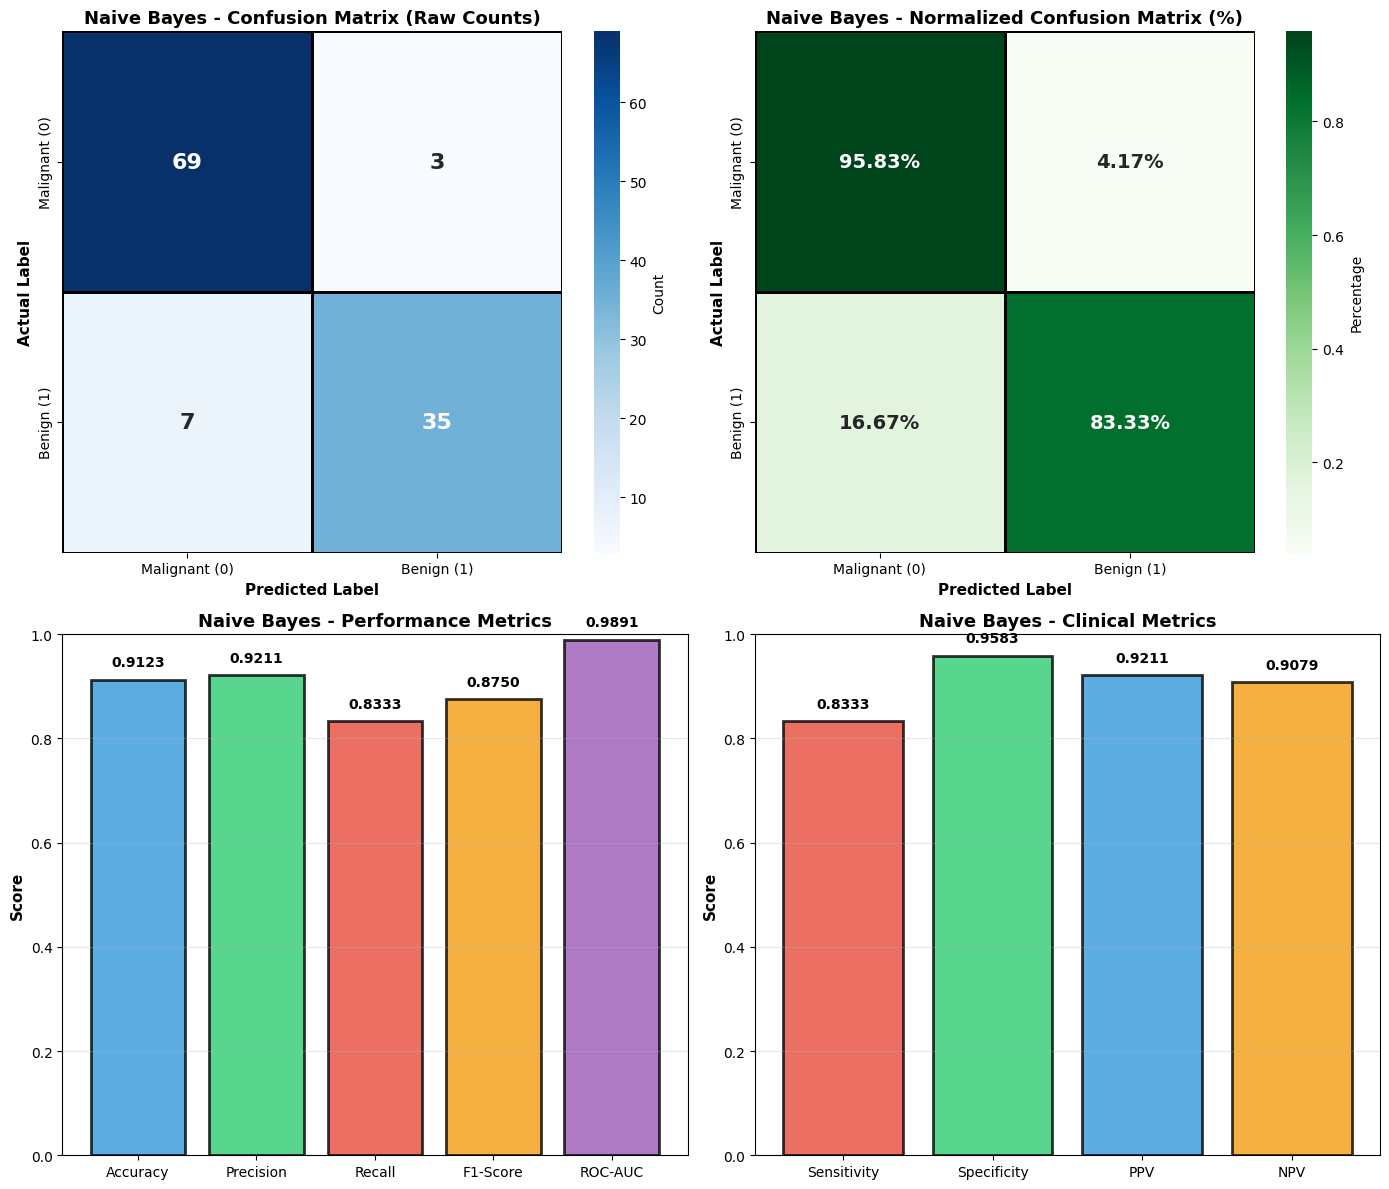


PREDICTION PROBABILITY DISTRIBUTION


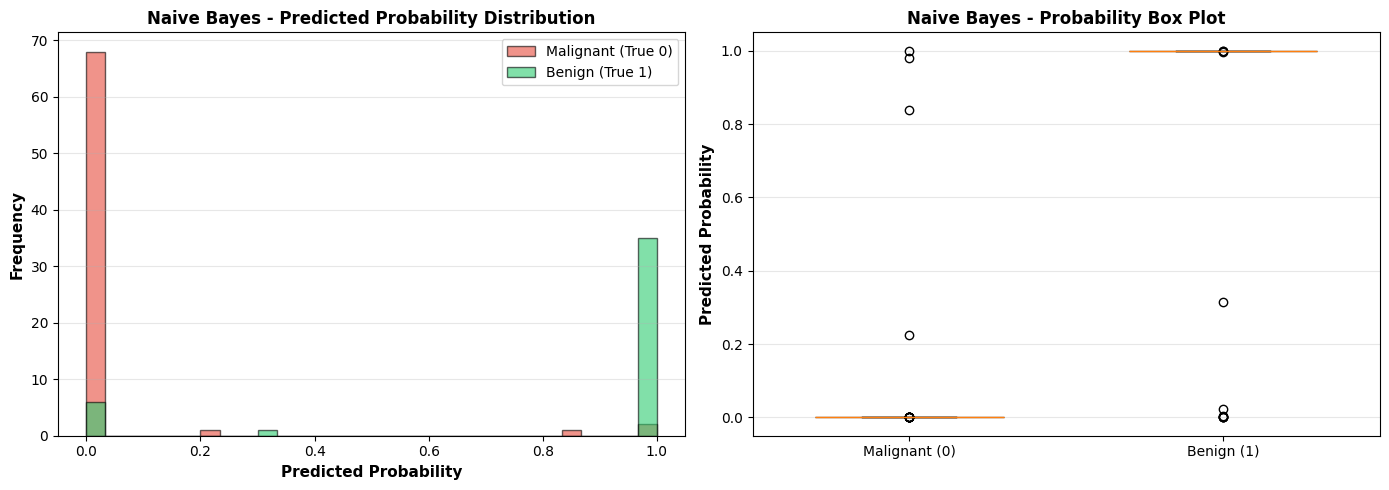


STEP 4.5 SUMMARY - NAIVE BAYES EVALUATION

🎯 Overall Performance:
  Accuracy:  0.9123
  Precision: 0.9211
  Recall:    0.8333
  F1-Score:  0.8750
  ROC-AUC:   0.9891

✅ NAIVE BAYES EVALUATION COMPLETED!

📌 Next Steps:
   - Compare all baseline models (Step 4.6)
   - Or proceed to Step 5: Feature Engineering


In [ ]:
# ============================================================
# STEP 4.5: NAIVE BAYES EVALUATION
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("STEP 4.5: NAIVE BAYES EVALUATION")
print("="*80)

# Verify data is available
if 'X_train' not in locals():
    raise ValueError("Error: X_train, X_test, y_train, y_test not found!")

print(f"\n✓ Data loaded: X_train {X_train.shape}, X_test {X_test.shape}")

# ============================================================
# TRAIN MODEL
# ============================================================
print("\n" + "="*80)
print("TRAINING NAIVE BAYES")
print("="*80)

print("\nInitializing Gaussian Naive Bayes model...")
print("  Model Type: Gaussian Naive Bayes")
print("  Description: Probabilistic classifier based on Bayes' theorem")
print("  Assumption: Features are normally distributed")
print("  Advantage: Fast, simple, works well with small datasets")

nb = GaussianNB()

print("\nTraining on full training set...")
nb.fit(X_train, y_train)
print("✓ Training completed!")

print(f"\nModel Information:")
print(f"  Classes: {nb.classes_}")
print(f"  Number of features: {X_train.shape[1]}")
print(f"  Class priors: {nb.class_prior_}")

# ============================================================
# PREDICTIONS
# ============================================================
print("\n" + "="*80)
print("GENERATING PREDICTIONS")
print("="*80)

print("\nPredicting on test set...")
y_pred_nb = nb.predict(X_test)
y_prob_nb = nb.predict_proba(X_test)[:, 1]
print("✓ Predictions completed!")

print(f"\nPrediction Statistics:")
print(f"  Total predictions: {len(y_pred_nb)}")
print(f"  Predicted Malignant (0): {(y_pred_nb == 0).sum()}")
print(f"  Predicted Benign (1): {(y_pred_nb == 1).sum()}")
print(f"  Probability range: [{y_prob_nb.min():.4f}, {y_prob_nb.max():.4f}]")

# ============================================================
# CALCULATE METRICS
# ============================================================
print("\n" + "="*80)
print("PERFORMANCE METRICS")
print("="*80)

nb_metrics = {
    'accuracy': accuracy_score(y_test, y_pred_nb),
    'precision': precision_score(y_test, y_pred_nb, zero_division=0),
    'recall': recall_score(y_test, y_pred_nb, zero_division=0),
    'f1': f1_score(y_test, y_pred_nb, zero_division=0),
    'roc_auc': roc_auc_score(y_test, y_prob_nb)
}

print("\n📊 Naive Bayes Performance Metrics:")
print("-" * 80)
for metric, value in nb_metrics.items():
    bar = "█" * int(value * 40)
    print(f"  {metric.capitalize():12s}: {value:.4f} {bar}")

# ============================================================
# CONFUSION MATRIX
# ============================================================
print("\n" + "="*80)
print("CONFUSION MATRIX ANALYSIS")
print("="*80)

cm_nb = confusion_matrix(y_test, y_pred_nb)

print(f"\n📋 Raw Confusion Matrix:")
print("-" * 80)
print(f"{'':25} Predicted")
print(f"{'':25} Malignant(0)  Benign(1)")
print(f"Actual Malignant(0) {cm_nb[0, 0]:6d}        {cm_nb[0, 1]:6d}")
print(f"Actual Benign(1)    {cm_nb[1, 0]:6d}        {cm_nb[1, 1]:6d}")

# Extract values
tn, fp, fn, tp = cm_nb[0, 0], cm_nb[0, 1], cm_nb[1, 0], cm_nb[1, 1]

# Calculate derived metrics
sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
npv = tn / (tn + fn) if (tn + fn) > 0 else 0

# ============================================================
# CLINICAL METRICS
# ============================================================
print(f"\n📈 Clinical Performance Metrics:")
print("-" * 80)
print(f"  Sensitivity (Recall):         {sensitivity:.4f} ({sensitivity:.1%})")
print(f"    └─ Correctly identifies {tp} out of {tp+fn} cancer cases")
print(f"  Specificity:                  {specificity:.4f} ({specificity:.1%})")
print(f"    └─ Correctly identifies {tn} out of {tn+fp} benign cases")
print(f"  Positive Predictive Value:    {ppv:.4f} ({ppv:.1%})")
print(f"  Negative Predictive Value:    {npv:.4f} ({npv:.1%})")
print(f"  False Negative Rate:          {1-sensitivity:.4f} ({(1-sensitivity):.1%})")
print(f"    └─ {fn} cancer case(s) missed")

# ============================================================
# CLASSIFICATION REPORT
# ============================================================
print(f"\n📄 Detailed Classification Report:")
print("-" * 80)
print(classification_report(y_test, y_pred_nb,
                          target_names=['Malignant (0)', 'Benign (1)'],
                          digits=4))

# ============================================================
# VISUALIZATIONS
# ============================================================
print(f"\n{'='*80}")
print("GENERATING VISUALIZATIONS...")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1. Confusion Matrix - Raw Counts
ax1 = axes[0, 0]
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Malignant (0)', 'Benign (1)'],
            yticklabels=['Malignant (0)', 'Benign (1)'],
            ax=ax1, cbar_kws={'label': 'Count'}, linewidths=2, linecolor='black',
            annot_kws={'size': 16, 'weight': 'bold'})
ax1.set_title('Naive Bayes - Confusion Matrix (Raw Counts)',
              fontsize=13, fontweight='bold')
ax1.set_ylabel('Actual Label', fontsize=11, fontweight='bold')
ax1.set_xlabel('Predicted Label', fontsize=11, fontweight='bold')

# 2. Confusion Matrix - Normalized
ax2 = axes[0, 1]
cm_norm = cm_nb.astype('float') / cm_nb.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Greens',
            xticklabels=['Malignant (0)', 'Benign (1)'],
            yticklabels=['Malignant (0)', 'Benign (1)'],
            ax=ax2, cbar_kws={'label': 'Percentage'}, linewidths=2, linecolor='black',
            annot_kws={'size': 14, 'weight': 'bold'})
ax2.set_title('Naive Bayes - Normalized Confusion Matrix (%)',
              fontsize=13, fontweight='bold')
ax2.set_ylabel('Actual Label', fontsize=11, fontweight='bold')
ax2.set_xlabel('Predicted Label', fontsize=11, fontweight='bold')

# 3. Metrics Bar Chart
ax3 = axes[1, 0]
metrics_list = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
metrics_values = [nb_metrics['accuracy'], nb_metrics['precision'],
                  nb_metrics['recall'], nb_metrics['f1'], nb_metrics['roc_auc']]
colors_metrics = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6']
bars = ax3.bar(metrics_list, metrics_values, color=colors_metrics,
               edgecolor='black', linewidth=2, alpha=0.8)
ax3.set_ylabel('Score', fontsize=11, fontweight='bold')
ax3.set_title('Naive Bayes - Performance Metrics', fontsize=13, fontweight='bold')
ax3.set_ylim([0, 1.0])
ax3.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, metrics_values):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height + 0.02,
            f'{val:.4f}', ha='center', va='bottom', fontweight='bold')

# 4. Clinical Metrics
ax4 = axes[1, 1]
clinical_metrics = ['Sensitivity', 'Specificity', 'PPV', 'NPV']
clinical_values = [sensitivity, specificity, ppv, npv]
colors_clinical = ['#e74c3c', '#2ecc71', '#3498db', '#f39c12']
bars = ax4.bar(clinical_metrics, clinical_values, color=colors_clinical,
               edgecolor='black', linewidth=2, alpha=0.8)
ax4.set_ylabel('Score', fontsize=11, fontweight='bold')
ax4.set_title('Naive Bayes - Clinical Metrics', fontsize=13, fontweight='bold')
ax4.set_ylim([0, 1.0])
ax4.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, clinical_values):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height + 0.02,
            f'{val:.4f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# ============================================================
# PROBABILITY DISTRIBUTION
# ============================================================
print(f"\n{'='*80}")
print("PREDICTION PROBABILITY DISTRIBUTION")
print("="*80)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Histogram of predicted probabilities
ax1 = axes[0]
ax1.hist(y_prob_nb[y_test == 0], bins=30, alpha=0.6, label='Malignant (True 0)',
         color='#e74c3c', edgecolor='black')
ax1.hist(y_prob_nb[y_test == 1], bins=30, alpha=0.6, label='Benign (True 1)',
         color='#2ecc71', edgecolor='black')
ax1.set_xlabel('Predicted Probability', fontsize=11, fontweight='bold')
ax1.set_ylabel('Frequency', fontsize=11, fontweight='bold')
ax1.set_title('Naive Bayes - Predicted Probability Distribution', fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3, axis='y')

# 2. Box plot of probabilities
ax2 = axes[1]
box_data = [y_prob_nb[y_test == 0], y_prob_nb[y_test == 1]]
bp = ax2.boxplot(box_data, labels=['Malignant (0)', 'Benign (1)'],
                  patch_artist=True, widths=0.6)
for patch, color in zip(bp['boxes'], ['#e74c3c', '#2ecc71']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax2.set_ylabel('Predicted Probability', fontsize=11, fontweight='bold')
ax2.set_title('Naive Bayes - Probability Box Plot', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# ============================================================
# SUMMARY
# ============================================================
print(f"\n{'='*80}")
print("STEP 4.5 SUMMARY - NAIVE BAYES EVALUATION")
print("="*80)

print(f"\n🎯 Overall Performance:")
print(f"  Accuracy:  {nb_metrics['accuracy']:.4f}")
print(f"  Precision: {nb_metrics['precision']:.4f}")
print(f"  Recall:    {nb_metrics['recall']:.4f}")
print(f"  F1-Score:  {nb_metrics['f1']:.4f}")
print(f"  ROC-AUC:   {nb_metrics['roc_auc']:.4f}")

print(f"\n✅ NAIVE BAYES EVALUATION COMPLETED!")
print(f"\n📌 Next Steps:")
print(f"   - Compare all baseline models (Step 4.6)")
print(f"   - Or proceed to Step 5: Feature Engineering")


STEP 4.6: BASELINE MODEL COMPARISON

✓ Verifying data availability...

Model Status:
  ✓ svm_tuned
  ✓ logr
  ✓ rf
  ✓ nb
  ✓ X_test
  ✓ y_test

✓ 4 models available for comparison

CALCULATING METRICS FOR ALL MODELS

Processing SVM_tuned...
  ✓ F1-Score: 0.9756
Processing Logistic Regression...
  ✓ F1-Score: 0.9512
Processing Random Forest...
  ✓ F1-Score: 0.9630
Processing Naive Bayes...
  ✓ F1-Score: 0.8750

CREATING COMPARISON TABLE

📊 All Models Performance Comparison:
              accuracy  precision  recall      f1  roc_auc
SVM_tuned       0.9825     1.0000  0.9524  0.9756   0.9954
Logistic        0.9649     0.9750  0.9286  0.9512   0.9960
RandomForest    0.9737     1.0000  0.9286  0.9630   0.9931
NaiveBayes      0.9123     0.9211  0.8333  0.8750   0.9891

🏆 Models Ranked by F1-Score:
              accuracy  precision  recall      f1  roc_auc
SVM_tuned       0.9825     1.0000  0.9524  0.9756   0.9954
RandomForest    0.9737     1.0000  0.9286  0.9630   0.9931
Logistic        0.

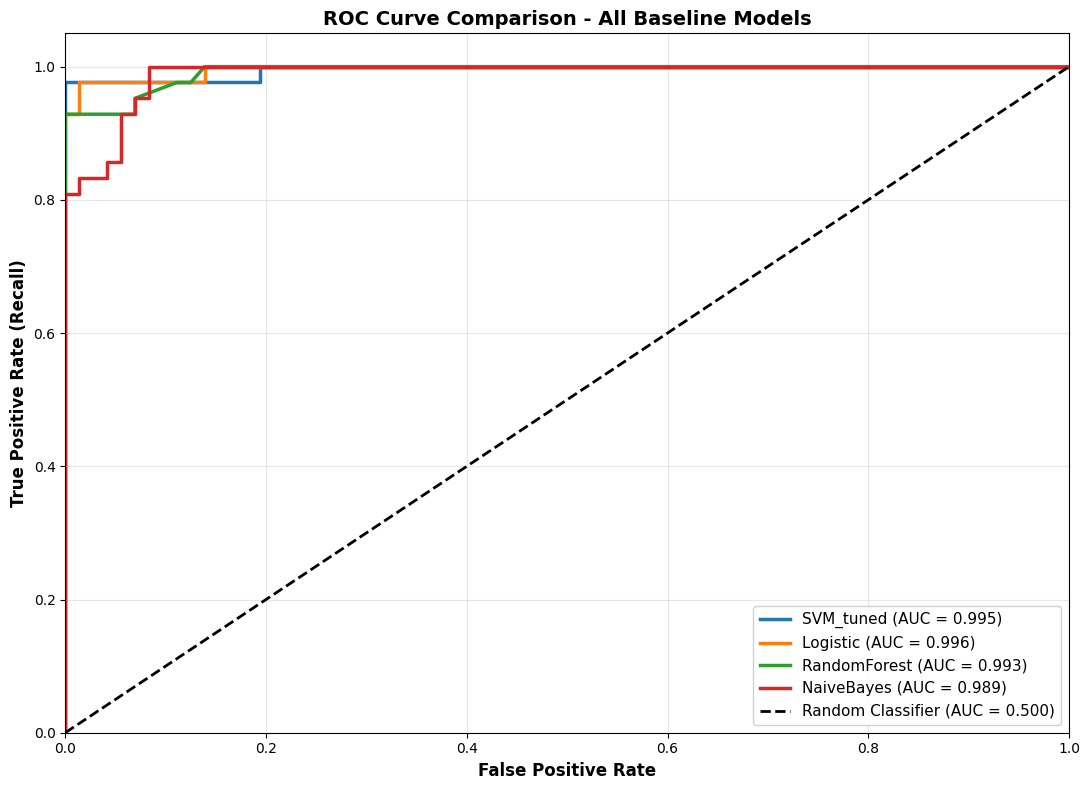


Generating metric comparison plots...


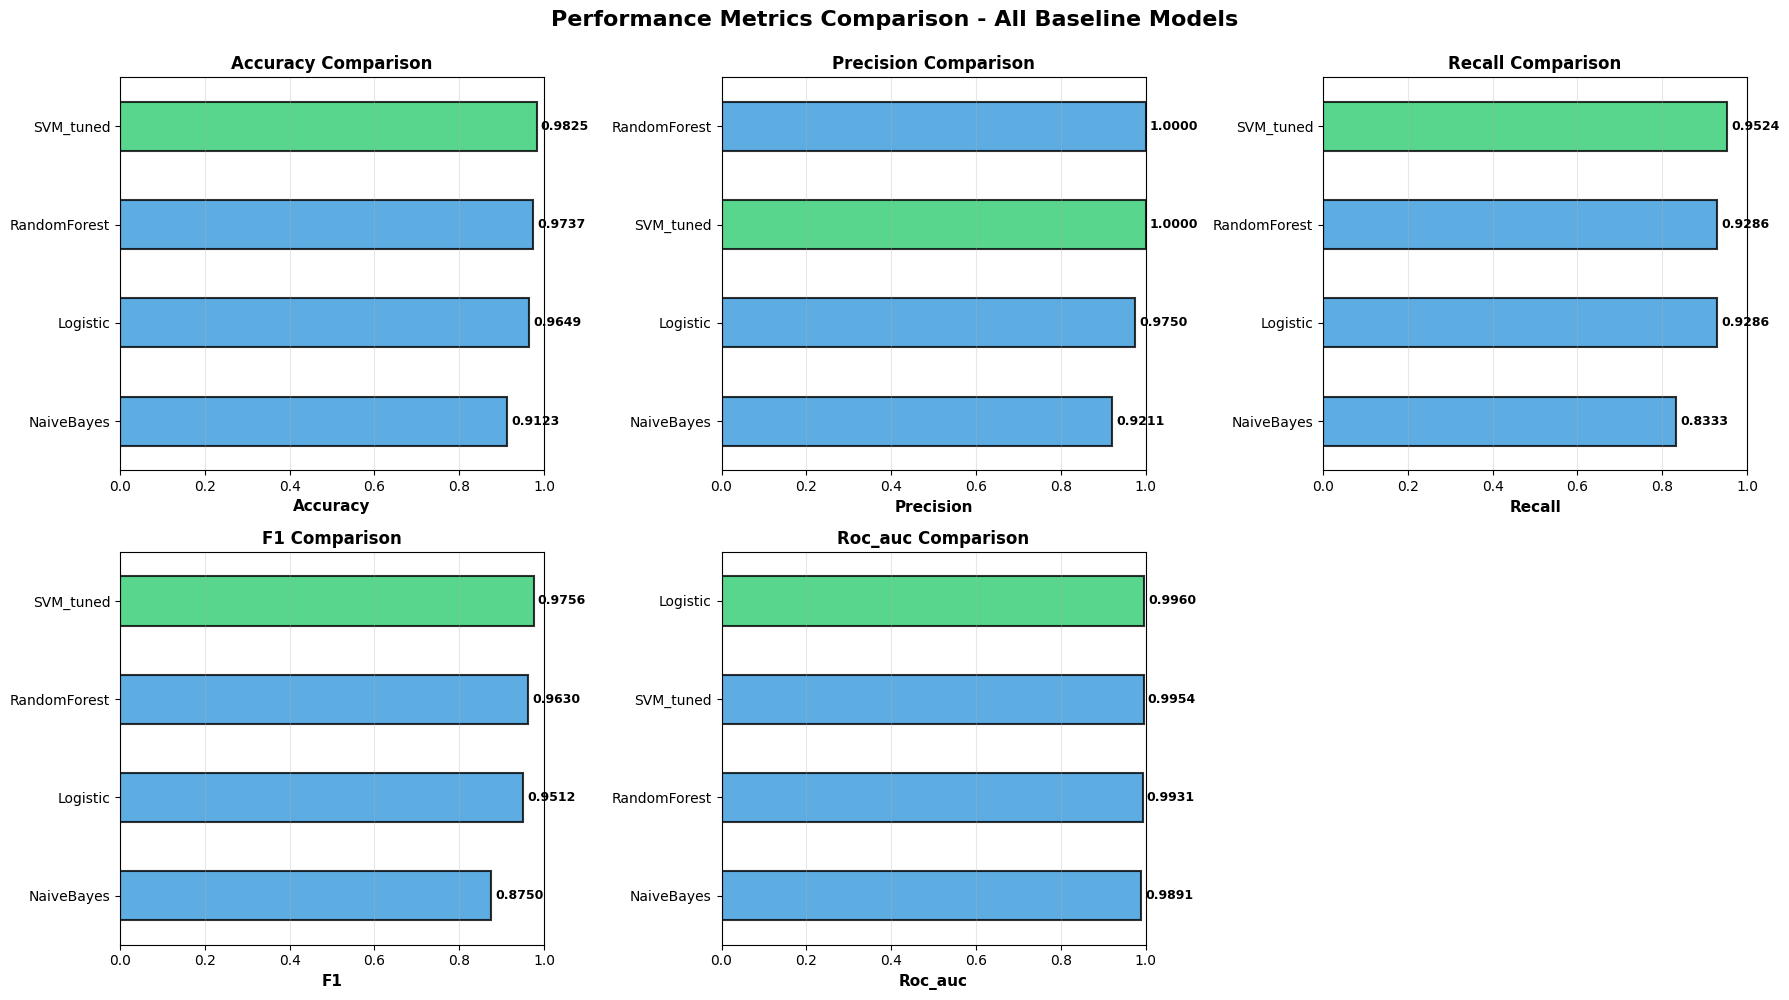


📈 Summary Statistics:
       accuracy  precision  recall      f1  roc_auc
count    4.0000     4.0000  4.0000  4.0000   4.0000
mean     0.9583     0.9740  0.9107  0.9412   0.9934
std      0.0315     0.0372  0.0528  0.0452   0.0031
min      0.9123     0.9211  0.8333  0.8750   0.9891
25%      0.9518     0.9615  0.9048  0.9322   0.9921
50%      0.9693     0.9875  0.9286  0.9571   0.9942
75%      0.9759     1.0000  0.9345  0.9661   0.9955
max      0.9825     1.0000  0.9524  0.9756   0.9960

🏆 BEST BASELINE MODEL DETAILS

Best Model: SVM_tuned
--------------------------------------------------------------------------------
  Accuracy    : 0.9825
  Precision   : 1.0000
  Recall      : 0.9524
  F1          : 0.9756
  Roc_auc     : 0.9954

✅ STEP 4.6 COMPLETED: ALL BASELINE MODELS EVALUATED!

📊 Summary:
  Total models compared: 4
  Best model: SVM_tuned
  Best F1-Score: 0.9756
  Best Accuracy: 0.9825
  Best ROC-AUC: 0.9954

📌 Ready to proceed to Step 5: Interpret Results


In [ ]:
# ============================================================
# STEP 4.6: COMPARE ALL BASELINE MODELS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

print("\n" + "="*80)
print("STEP 4.6: BASELINE MODEL COMPARISON")
print("="*80)

# ============================================================
# VERIFY DATA AVAILABILITY
# ============================================================
print("\n✓ Verifying data availability...")

required_models = ['svm_tuned', 'logr', 'rf', 'nb']
required_probs = ['y_prob_svm', 'y_prob_logr', 'y_prob_rf', 'y_prob_nb']
available = {
    'svm_tuned': 'svm_tuned' in locals(),
    'logr': 'logr' in locals(),
    'rf': 'rf' in locals(),
    'nb': 'nb' in locals(),
    'X_test': 'X_test' in locals(),
    'y_test': 'y_test' in locals()
}

print("\nModel Status:")
for model, exists in available.items():
    status = "✓" if exists else "✗"
    print(f"  {status} {model}")

# Check if we have test data and models
if not available['X_test'] or not available['y_test']:
    raise ValueError("Error: X_test, y_test not found! Run Step 2 first.")

models_available = sum([available['svm_tuned'], available['logr'],
                        available['rf'], available['nb']])
if models_available == 0:
    raise ValueError("Error: No models found! Run Step 4 (baseline models) first.")

print(f"\n✓ {models_available} models available for comparison")

# ============================================================
# CREATE RESULTS DICTIONARY
# ============================================================
print("\n" + "="*80)
print("CALCULATING METRICS FOR ALL MODELS")
print("="*80)

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix)

results = {}

# SVM Tuned
if 'svm_tuned' in locals():
    print("\nProcessing SVM_tuned...")
    y_pred_svm = svm_tuned.predict(X_test)
    y_prob_svm = svm_tuned.predict_proba(X_test)[:, 1]

    results['SVM_tuned'] = {
        'accuracy': accuracy_score(y_test, y_pred_svm),
        'precision': precision_score(y_test, y_pred_svm, zero_division=0),
        'recall': recall_score(y_test, y_pred_svm, zero_division=0),
        'f1': f1_score(y_test, y_pred_svm, zero_division=0),
        'roc_auc': roc_auc_score(y_test, y_prob_svm)
    }
    print(f"  ✓ F1-Score: {results['SVM_tuned']['f1']:.4f}")

# Logistic Regression
if 'logr' in locals():
    print("Processing Logistic Regression...")
    y_pred_logr = logr.predict(X_test)
    y_prob_logr = logr.predict_proba(X_test)[:, 1]

    results['Logistic'] = {
        'accuracy': accuracy_score(y_test, y_pred_logr),
        'precision': precision_score(y_test, y_pred_logr, zero_division=0),
        'recall': recall_score(y_test, y_pred_logr, zero_division=0),
        'f1': f1_score(y_test, y_pred_logr, zero_division=0),
        'roc_auc': roc_auc_score(y_test, y_prob_logr)
    }
    print(f"  ✓ F1-Score: {results['Logistic']['f1']:.4f}")

# Random Forest
if 'rf' in locals():
    print("Processing Random Forest...")
    y_pred_rf = rf.predict(X_test)
    y_prob_rf = rf.predict_proba(X_test)[:, 1]

    results['RandomForest'] = {
        'accuracy': accuracy_score(y_test, y_pred_rf),
        'precision': precision_score(y_test, y_pred_rf, zero_division=0),
        'recall': recall_score(y_test, y_pred_rf, zero_division=0),
        'f1': f1_score(y_test, y_pred_rf, zero_division=0),
        'roc_auc': roc_auc_score(y_test, y_prob_rf)
    }
    print(f"  ✓ F1-Score: {results['RandomForest']['f1']:.4f}")

# Naive Bayes
if 'nb' in locals():
    print("Processing Naive Bayes...")
    y_pred_nb = nb.predict(X_test)
    y_prob_nb = nb.predict_proba(X_test)[:, 1]

    results['NaiveBayes'] = {
        'accuracy': accuracy_score(y_test, y_pred_nb),
        'precision': precision_score(y_test, y_pred_nb, zero_division=0),
        'recall': recall_score(y_test, y_pred_nb, zero_division=0),
        'f1': f1_score(y_test, y_pred_nb, zero_division=0),
        'roc_auc': roc_auc_score(y_test, y_prob_nb)
    }
    print(f"  ✓ F1-Score: {results['NaiveBayes']['f1']:.4f}")

# ============================================================
# CREATE COMPARISON DATAFRAME
# ============================================================
print("\n" + "="*80)
print("CREATING COMPARISON TABLE")
print("="*80)

results_df = pd.DataFrame(results).T

print("\n📊 All Models Performance Comparison:")
print("="*80)
print(results_df.round(4))

# Sort by F1-Score
print("\n" + "="*80)
print("🏆 Models Ranked by F1-Score:")
print("="*80)
sorted_by_f1 = results_df.sort_values('f1', ascending=False)
print(sorted_by_f1.round(4))

# Highlight best model for each metric
print("\n" + "="*80)
print("Best Models Per Metric:")
print("="*80)
for metric in results_df.columns:
    best_model = results_df[metric].idxmax()
    best_score = results_df[metric].max()
    print(f"  {metric.capitalize():12s}: {best_model:20s} ({best_score:.4f})")

# ============================================================
# ROC CURVE COMPARISON
# ============================================================
print("\n" + "="*80)
print("GENERATING ROC CURVE COMPARISON")
print("="*80)

plt.figure(figsize=(11, 8))

# Collect all probability predictions
y_probs_all = {}
if 'svm_tuned' in locals():
    y_probs_all['SVM_tuned'] = y_prob_svm
if 'logr' in locals():
    y_probs_all['Logistic'] = y_prob_logr
if 'rf' in locals():
    y_probs_all['RandomForest'] = y_prob_rf
if 'nb' in locals():
    y_probs_all['NaiveBayes'] = y_prob_nb

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

for (name, y_prob), color in zip(y_probs_all.items(), colors):
    try:
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        auc = roc_auc_score(y_test, y_prob)
        plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', linewidth=2.5, color=color)
    except Exception as e:
        print(f"⚠ Warning: Could not plot ROC for {name}: {str(e)}")

# Random classifier line
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.500)', linewidth=2)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate (Recall)', fontsize=12, fontweight='bold')
plt.title('ROC Curve Comparison - All Baseline Models', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11, framealpha=0.9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# BAR PLOT COMPARISON FOR ALL METRICS
# ============================================================
print("\nGenerating metric comparison plots...")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
metrics_list = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

for idx, metric in enumerate(metrics_list):
    row = idx // 3
    col = idx % 3
    ax = axes[row, col]

    if metric in results_df.columns:
        sorted_data = results_df[metric].sort_values(ascending=True)
        best_model = sorted_data.idxmax()
        colors_bar = ['#2ecc71' if i == best_model else '#3498db'
                      for i in sorted_data.index]

        sorted_data.plot(kind='barh', ax=ax, color=colors_bar, alpha=0.8,
                        edgecolor='black', linewidth=1.5)
        ax.set_xlabel(metric.capitalize(), fontsize=11, fontweight='bold')
        ax.set_title(f'{metric.capitalize()} Comparison', fontsize=12, fontweight='bold')
        ax.set_xlim([0, 1])
        ax.grid(axis='x', alpha=0.3)

        # Add value labels
        for i, v in enumerate(sorted_data.values):
            ax.text(v + 0.01, i, f'{v:.4f}', va='center', fontsize=9, fontweight='bold')

# Hide the last subplot
axes[1, 2].axis('off')

plt.suptitle('Performance Metrics Comparison - All Baseline Models',
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

# ============================================================
# SUMMARY STATISTICS
# ============================================================
print("\n" + "="*80)
print("📈 Summary Statistics:")
print("="*80)
print(results_df.describe().round(4))

# ============================================================
# BEST MODEL DETAILS
# ============================================================
print("\n" + "="*80)
print("🏆 BEST BASELINE MODEL DETAILS")
print("="*80)

best_model_name = sorted_by_f1.index[0]
best_model_scores = sorted_by_f1.iloc[0]

print(f"\nBest Model: {best_model_name}")
print("-" * 80)
for metric, score in best_model_scores.items():
    print(f"  {metric.capitalize():12s}: {score:.4f}")

# ============================================================
# FINAL SUMMARY
# ============================================================
print("\n" + "="*80)
print("✅ STEP 4.6 COMPLETED: ALL BASELINE MODELS EVALUATED!")
print("="*80)

print(f"\n📊 Summary:")
print(f"  Total models compared: {len(results_df)}")
print(f"  Best model: {best_model_name}")
print(f"  Best F1-Score: {best_model_scores['f1']:.4f}")
print(f"  Best Accuracy: {best_model_scores['accuracy']:.4f}")
if 'roc_auc' in best_model_scores:
    print(f"  Best ROC-AUC: {best_model_scores['roc_auc']:.4f}")

print("\n📌 Ready to proceed to Step 5: Interpret Results")
print("="*80)

STEP 5: INTERPRET RESULTS

5.1: FEATURE IMPORTANCE ANALYSIS
--------------------------------------------------------------------------------

Using Random Forest for feature importance analysis...

🔍 Top 10 Most Important Features for Classification:
   1. perimeter_worst                          : 0.1360 ██████
   2. concave points_worst                     : 0.1076 █████
   3. radius_worst                             : 0.1066 █████
   4. concave points_mean                      : 0.1058 █████
   5. area_worst                               : 0.1038 █████
   6. concavity_mean                           : 0.0601 ███
   7. radius_mean                              : 0.0436 ██
   8. perimeter_mean                           : 0.0343 █
   9. concavity_worst                          : 0.0338 █
  10. tumor_growth_stage                       : 0.0286 █


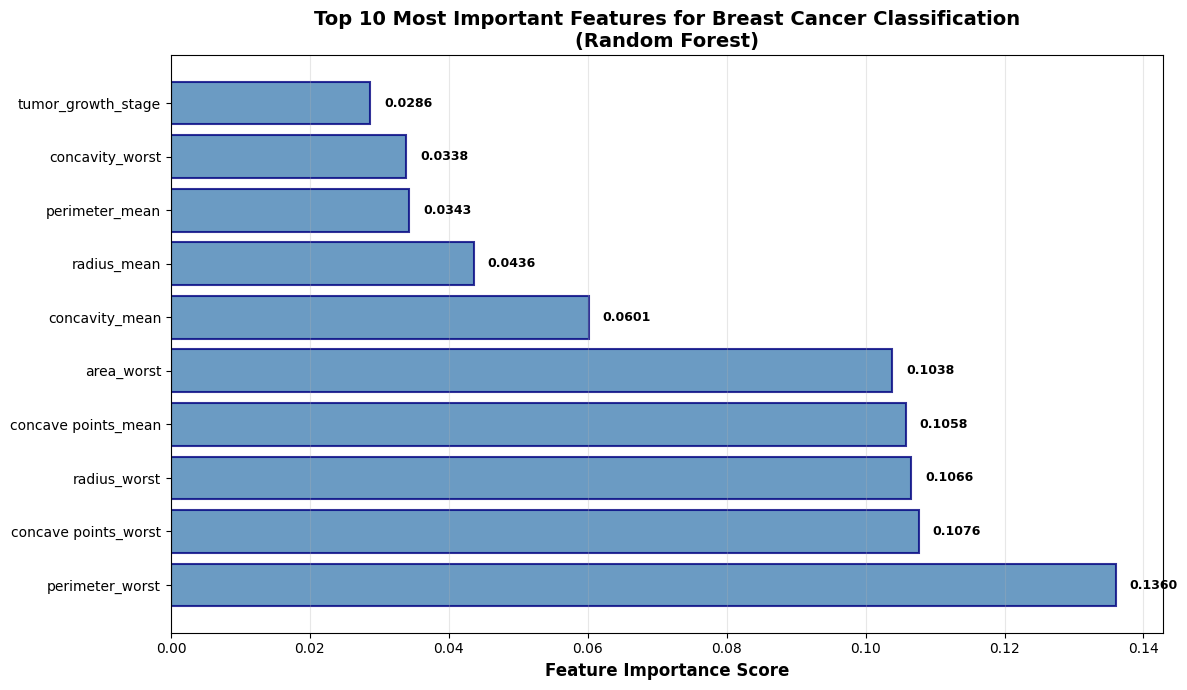


5.2: PERMUTATION IMPORTANCE (SVM)
--------------------------------------------------------------------------------
Computing permutation importance... (this may take a moment)

🔍 Top 10 Features by Permutation Importance (SVM):
             Feature  Importance_Mean  Importance_Std
       texture_worst         0.051786        0.012906
    smoothness_worst         0.035652        0.012281
     concavity_worst         0.033032        0.008645
      symmetry_worst         0.031608        0.014127
 concave points_mean         0.020154        0.011705
          texture_se         0.019521        0.012458
concave points_worst         0.016599        0.010019
        texture_mean         0.016201        0.007844
        radius_worst         0.016113        0.005703
          area_worst         0.016113        0.005703


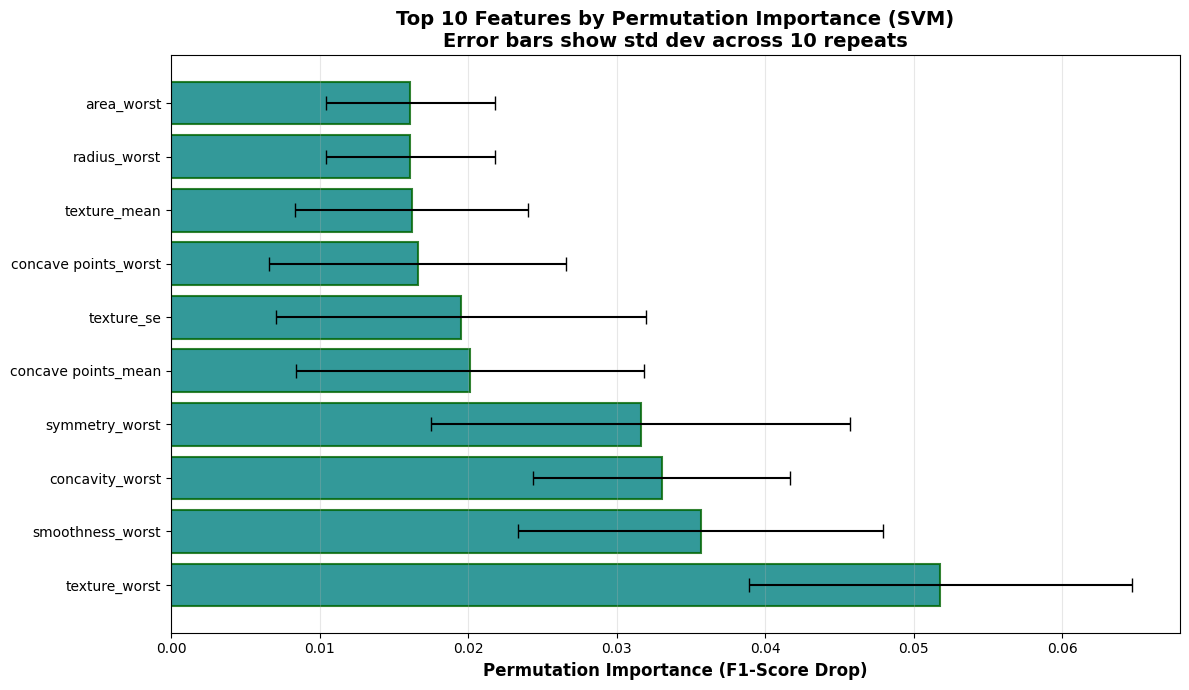


5.3: DECISION BOUNDARY VISUALIZATION
--------------------------------------------------------------------------------
Reducing data to 2D using PCA for visualization...
✓ Reduced to 2D using PCA
✓ Explained variance: 67.17%
  - PC1: 48.66%
  - PC2: 18.51%


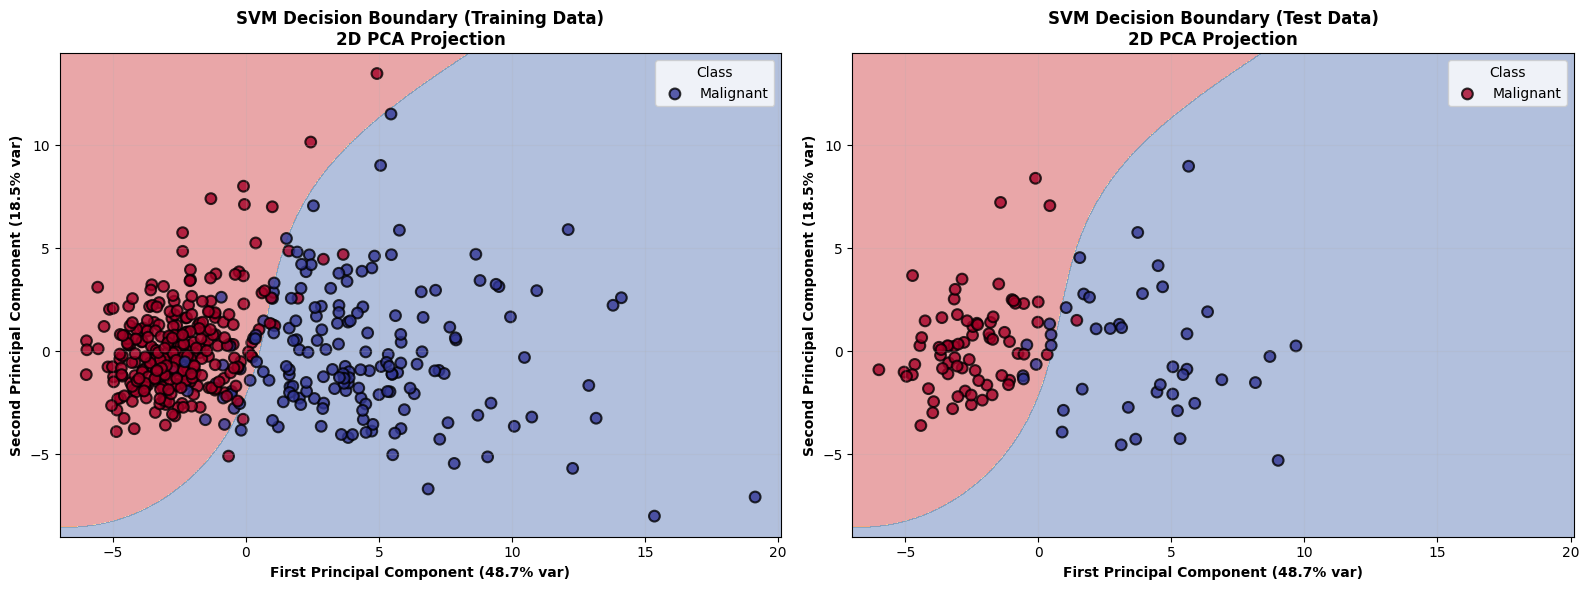


✅ STEP 5 COMPLETED: RESULTS INTERPRETED SUCCESSFULLY!


In [ ]:
# ============================================================
# STEP 5: INTERPRET RESULTS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.inspection import permutation_importance
from sklearn.decomposition import PCA
from sklearn.svm import SVC
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("STEP 5: INTERPRET RESULTS")
print("="*80)

# Verify models are available
if 'rf' not in locals() or 'svm_tuned' not in locals():
    raise ValueError("Error: Models not found! Please run Steps 3-4 first.")

# ============================================================
# 5.1: FEATURE IMPORTANCE ANALYSIS (Random Forest)
# ============================================================
print("\n5.1: FEATURE IMPORTANCE ANALYSIS")
print("-" * 80)

print("\nUsing Random Forest for feature importance analysis...")
rf.fit(X_train, y_train)
importances = rf.feature_importances_
feature_names = X_train.columns if hasattr(X_train, 'columns') else [f'Feature_{i}' for i in range(X_train.shape[1])]

# Get top 10 indices
indices = np.argsort(importances)[-10:]

print("\n🔍 Top 10 Most Important Features for Classification:")
print("="*80)
for idx, i in enumerate(indices[::-1], 1):
    feature_name = feature_names[i]
    importance = importances[i]
    bar = "█" * int(importance * 50)
    print(f"  {idx:2d}. {feature_name:<40s} : {importance:.4f} {bar}")

# Visualization: Feature Importance
fig, ax = plt.subplots(figsize=(12, 7))
feature_names_top = [feature_names[i] for i in indices[::-1]]
ax.barh(range(len(indices)), importances[indices[::-1]], color='steelblue',
        alpha=0.8, edgecolor='navy', linewidth=1.5)
ax.set_yticks(range(len(indices)))
ax.set_yticklabels(feature_names_top, fontsize=10)
ax.set_xlabel('Feature Importance Score', fontsize=12, fontweight='bold')
ax.set_title('Top 10 Most Important Features for Breast Cancer Classification\n(Random Forest)',
             fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Add value labels
for i, v in enumerate(importances[indices[::-1]]):
    ax.text(v + 0.002, i, f'{v:.4f}', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

# ============================================================
# 5.2: PERMUTATION IMPORTANCE (SVM)
# ============================================================
print("\n5.2: PERMUTATION IMPORTANCE (SVM)")
print("-" * 80)

print("Computing permutation importance... (this may take a moment)")
try:
    perm_importance = permutation_importance(
        svm_tuned, X_test, y_test, n_repeats=10, random_state=42,
        n_jobs=-1, scoring='f1'
    )

    perm_importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance_Mean': perm_importance.importances_mean,
        'Importance_Std': perm_importance.importances_std
    }).sort_values('Importance_Mean', ascending=False)

    print("\n🔍 Top 10 Features by Permutation Importance (SVM):")
    print("="*80)
    print(perm_importance_df.head(10).to_string(index=False))

    # Visualization: Permutation Importance
    top_10_perm = perm_importance_df.head(10)
    fig, ax = plt.subplots(figsize=(12, 7))
    ax.barh(range(len(top_10_perm)), top_10_perm['Importance_Mean'],
            xerr=top_10_perm['Importance_Std'], color='teal', alpha=0.8,
            edgecolor='darkgreen', linewidth=1.5, capsize=5)
    ax.set_yticks(range(len(top_10_perm)))
    ax.set_yticklabels(top_10_perm['Feature'], fontsize=10)
    ax.set_xlabel('Permutation Importance (F1-Score Drop)', fontsize=12, fontweight='bold')
    ax.set_title('Top 10 Features by Permutation Importance (SVM)\nError bars show std dev across 10 repeats',
                 fontsize=14, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Warning: Permutation importance failed: {str(e)}")

# ============================================================
# 5.3: DECISION BOUNDARY VISUALIZATION (2D PCA)
# ============================================================
print("\n5.3: DECISION BOUNDARY VISUALIZATION")
print("-" * 80)

print("Reducing data to 2D using PCA for visualization...")

# Reduce to 2D using PCA
pca_2d = PCA(n_components=2, random_state=42)
X_train_2d = pca_2d.fit_transform(X_train)
X_test_2d = pca_2d.transform(X_test)

explained_var = pca_2d.explained_variance_ratio_.sum()
print(f"✓ Reduced to 2D using PCA")
print(f"✓ Explained variance: {explained_var:.2%}")
print(f"  - PC1: {pca_2d.explained_variance_ratio_[0]:.2%}")
print(f"  - PC2: {pca_2d.explained_variance_ratio_[1]:.2%}")

# Train SVM on 2D data
svm_2d = SVC(kernel='rbf', C=svm_tuned.C, gamma=svm_tuned.gamma, random_state=42)
svm_2d.fit(X_train_2d, y_train)

# Create mesh for decision boundary
h = 0.02
x_min, x_max = X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1
y_min, y_max = X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# Predict on mesh
Z = svm_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Training data with decision boundary
axes[0].contourf(xx, yy, Z, alpha=0.4, cmap='RdYlBu')
scatter_train = axes[0].scatter(X_train_2d[:, 0], X_train_2d[:, 1], c=y_train,
                                cmap='RdYlBu', edgecolors='black', s=60, alpha=0.8, linewidth=1.5)
axes[0].set_title('SVM Decision Boundary (Training Data)\n2D PCA Projection',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel(f'First Principal Component ({pca_2d.explained_variance_ratio_[0]:.1%} var)',
                   fontsize=10, fontweight='bold')
axes[0].set_ylabel(f'Second Principal Component ({pca_2d.explained_variance_ratio_[1]:.1%} var)',
                   fontsize=10, fontweight='bold')
axes[0].legend(*scatter_train.legend_elements(), labels=['Malignant', 'Benign'],
               title='Class', loc='best')
axes[0].grid(True, alpha=0.2)

# Test data with decision boundary
axes[1].contourf(xx, yy, Z, alpha=0.4, cmap='RdYlBu')
scatter_test = axes[1].scatter(X_test_2d[:, 0], X_test_2d[:, 1], c=y_test,
                               cmap='RdYlBu', edgecolors='black', s=60, alpha=0.8, linewidth=1.5)
axes[1].set_title('SVM Decision Boundary (Test Data)\n2D PCA Projection',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel(f'First Principal Component ({pca_2d.explained_variance_ratio_[0]:.1%} var)',
                   fontsize=10, fontweight='bold')
axes[1].set_ylabel(f'Second Principal Component ({pca_2d.explained_variance_ratio_[1]:.1%} var)',
                   fontsize=10, fontweight='bold')
axes[1].legend(*scatter_test.legend_elements(), labels=['Malignant', 'Benign'],
               title='Class', loc='best')
axes[1].grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

print(f"\n{'='*80}")
print("✅ STEP 5 COMPLETED: RESULTS INTERPRETED SUCCESSFULLY!")

STEP 6.1: SVD - SINGULAR VALUE DECOMPOSITION

✓ Data available: X_scaled (569, 34), y_raw 569

DETERMINING OPTIMAL K (number of components)

Applying full SVD to analyze explained variance...

📊 SVD Variance Analysis:
--------------------------------------------------------------------------------
  Total components possible: 33
  Total variance to explain: 100%

  Components for 90% variance: 7
  Selected k: 7
  Variance explained by k=7: 91.53%

📈 Top 5 Singular Values:
--------------------------------------------------------------------------------
  σ1: 96.1487 | Variance: 47.79% | Cumulative: 47.79%
  σ2: 60.7163 | Variance: 19.06% | Cumulative: 66.84%
  σ3: 40.1096 | Variance: 8.32% | Cumulative: 75.16%
  σ4: 33.6749 | Variance: 5.86% | Cumulative: 81.02%
  σ5: 30.9132 | Variance: 4.94% | Cumulative: 85.96%

APPLYING SVD WITH K=7 COMPONENTS

Reducing 34 features to 7 components...
✓ SVD transformation completed
✓ New feature space: (569, 7)
✓ Variance explained: 91.53%

GENERATIN

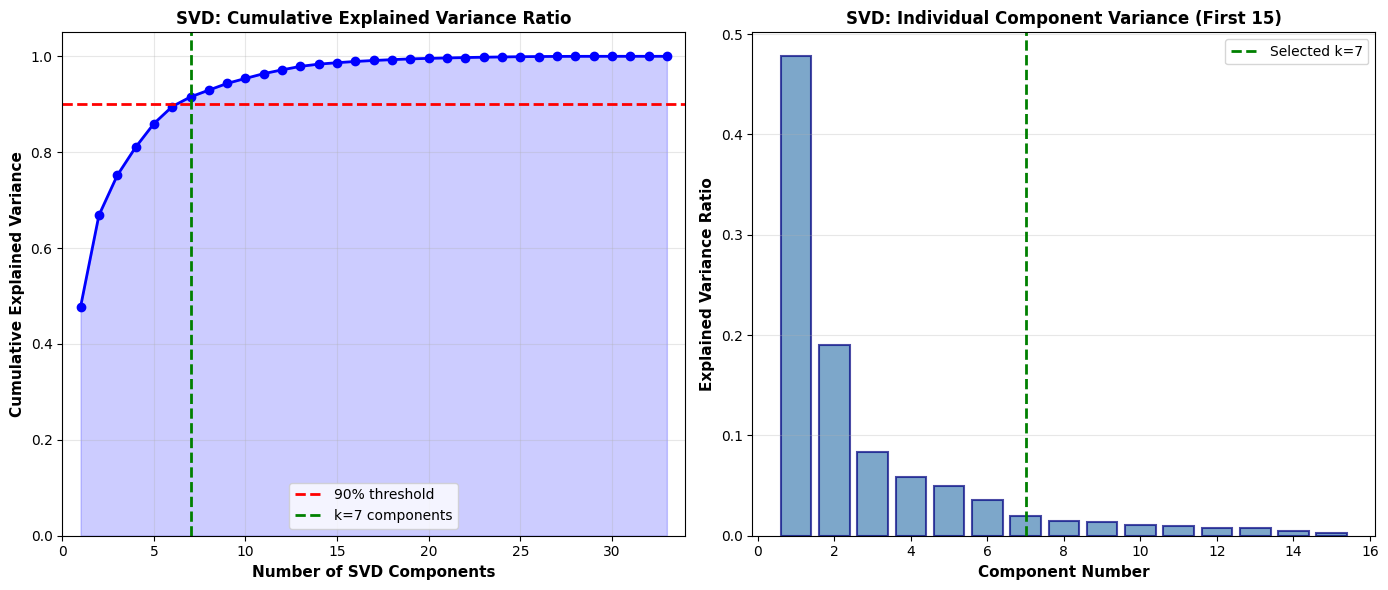


TRAINING SVM ON SVD-TRANSFORMED DATA
✓ Train-test split completed
  Train: (455, 7), Test: (114, 7)

Training SVM on SVD features...
✓ Training completed!

📊 SVM + SVD Performance Metrics:
--------------------------------------------------------------------------------
  Accuracy    : 0.9649 ██████████████████████████████████████
  Precision   : 0.9750 ███████████████████████████████████████
  Recall      : 0.9286 █████████████████████████████████████
  F1          : 0.9512 ██████████████████████████████████████
  Roc_auc     : 0.9957 ███████████████████████████████████████

📋 Confusion Matrix:
--------------------------------------------------------------------------------
                          Predicted
                          Malignant(0)  Benign(1)
Actual Malignant(0)     71             1
Actual Benign(1)         3            39

📄 Classification Report:
--------------------------------------------------------------------------------
               precision    recall  f1-sc

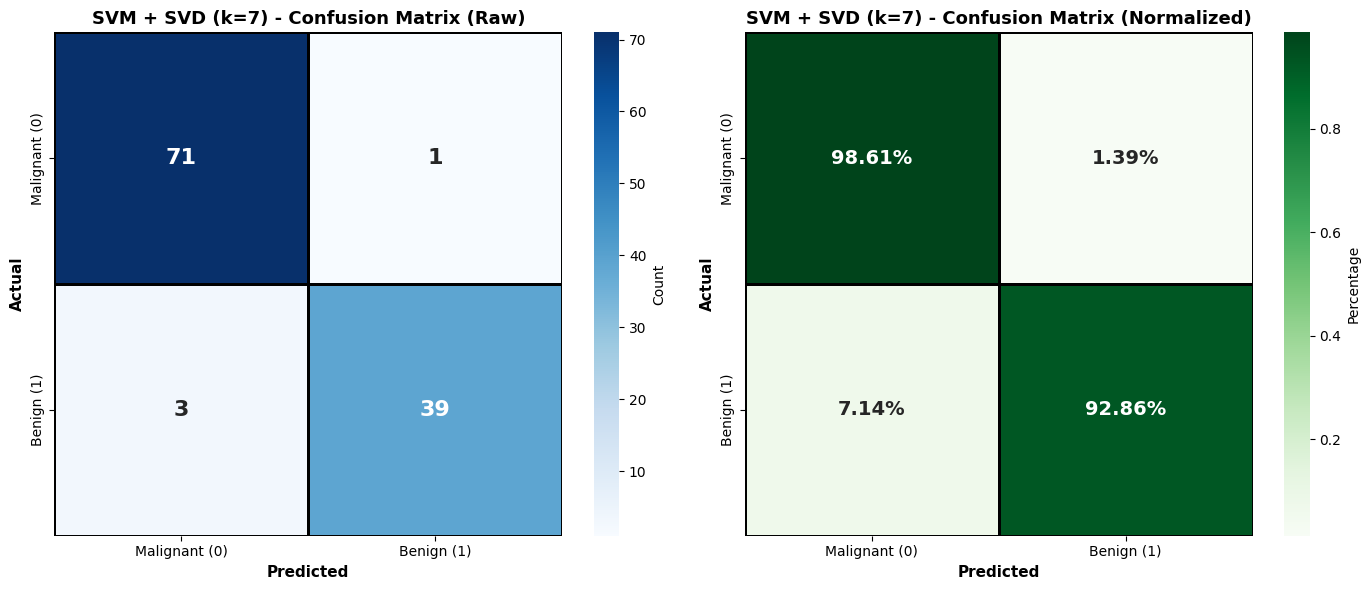


STEP 6.1 SUMMARY - SVD ANALYSIS

🎯 Dimensionality Reduction Results:
  Original features: 34
  Reduced to: 7 components
  Reduction ratio: 4.9x
  Variance preserved: 91.53%

📊 SVM + SVD Performance:
  F1-Score:  0.9512
  Accuracy:  0.9649
  ROC-AUC:   0.9957

✅ SVD COMPLETED!
   Reduced 34 → 7 features
   Variance: 91.53%
   F1-Score: 0.9512


In [ ]:
# ============================================================
# STEP 6.1: SVD - SINGULAR VALUE DECOMPOSITION
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import TruncatedSVD
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("STEP 6.1: SVD - SINGULAR VALUE DECOMPOSITION")
print("="*80)

if 'X_scaled' not in locals() or 'y_raw' not in locals():
    raise ValueError("Error: X_scaled, y_raw not found! Run Step 2 first.")

print(f"\n✓ Data available: X_scaled {X_scaled.shape}, y_raw {len(y_raw)}")

# ============================================================
# DETERMINE OPTIMAL K
# ============================================================
print("\n" + "="*80)
print("DETERMINING OPTIMAL K (number of components)")
print("="*80)

# Use full SVD first to analyze variance
print("\nApplying full SVD to analyze explained variance...")
svd_full = TruncatedSVD(n_components=min(X_scaled.shape) - 1, random_state=42)
svd_full.fit(X_scaled)

# Calculate cumulative explained variance
cumsum_var = np.cumsum(svd_full.explained_variance_ratio_)

print(f"\n📊 SVD Variance Analysis:")
print("-" * 80)
print(f"  Total components possible: {len(cumsum_var)}")
print(f"  Total variance to explain: 100%")

# Find k for 90% variance
k_90 = np.argmax(cumsum_var >= 0.90) + 1
k = min(k_90, 15)  # Cap at 15 for practical reasons

print(f"\n  Components for 90% variance: {k_90}")
print(f"  Selected k: {k}")
print(f"  Variance explained by k={k}: {cumsum_var[k-1]:.2%}")

print(f"\n📈 Top 5 Singular Values:")
print("-" * 80)
for i in range(min(5, len(svd_full.singular_values_))):
    var_ratio = svd_full.explained_variance_ratio_[i]
    cumsum = cumsum_var[i]
    print(f"  σ{i+1}: {svd_full.singular_values_[i]:.4f} | " +
          f"Variance: {var_ratio:.2%} | Cumulative: {cumsum:.2%}")

# ============================================================
# APPLY SVD WITH OPTIMAL K
# ============================================================
print("\n" + "="*80)
print(f"APPLYING SVD WITH K={k} COMPONENTS")
print("="*80)

print(f"\nReducing {X_scaled.shape[1]} features to {k} components...")
svd_k = TruncatedSVD(n_components=k, random_state=42)
X_svd_k = svd_k.fit_transform(X_scaled)

print(f"✓ SVD transformation completed")
print(f"✓ New feature space: {X_svd_k.shape}")
print(f"✓ Variance explained: {svd_k.explained_variance_ratio_.sum():.2%}")

# ============================================================
# VISUALIZATIONS
# ============================================================
print(f"\n{'='*80}")
print("GENERATING VISUALIZATIONS...")
print("="*80)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Cumulative variance
explained = cumsum_var[:len(svd_full.explained_variance_ratio_)]
axes[0].plot(np.arange(1, len(explained) + 1), explained, 'bo-', linewidth=2, markersize=6)
axes[0].axhline(y=0.90, color='r', linestyle='--', linewidth=2, label='90% threshold')
axes[0].axvline(x=k, color='g', linestyle='--', linewidth=2, label=f'k={k} components')
axes[0].fill_between(np.arange(1, len(explained) + 1), explained, alpha=0.2, color='blue')
axes[0].set_xlabel('Number of SVD Components', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Cumulative Explained Variance', fontsize=11, fontweight='bold')
axes[0].set_title('SVD: Cumulative Explained Variance Ratio', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim([0, len(explained) + 1])
axes[0].set_ylim([0, 1.05])

# Individual variance
individual_var = svd_full.explained_variance_ratio_
axes[1].bar(range(1, min(16, len(individual_var) + 1)), individual_var[:15],
            color='steelblue', alpha=0.7, edgecolor='navy', linewidth=1.5)
axes[1].axvline(x=k, color='g', linestyle='--', linewidth=2, label=f'Selected k={k}')
axes[1].set_xlabel('Component Number', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Explained Variance Ratio', fontsize=11, fontweight='bold')
axes[1].set_title('SVD: Individual Component Variance (First 15)', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================
# SPLIT DATA & TRAIN SVM
# ============================================================
print("\n" + "="*80)
print("TRAINING SVM ON SVD-TRANSFORMED DATA")
print("="*80)

# Prepare stratification
y_encoded = y_raw.copy()
if hasattr(y_raw, 'dtype') and y_raw.dtype == 'object':
    from sklearn.preprocessing import LabelEncoder
    le = LabelEncoder()
    y_encoded = le.fit_transform(y_raw)

stratify_param = pd.Series(y_encoded) if len(np.unique(y_encoded)) > 1 else None

# Split data
Xtr_svd, Xte_svd, ytr_svd, yte_svd = train_test_split(
    X_svd_k, y_encoded, test_size=0.2, random_state=42, stratify=stratify_param
)

print(f"✓ Train-test split completed")
print(f"  Train: {Xtr_svd.shape}, Test: {Xte_svd.shape}")

# Train SVM
print(f"\nTraining SVM on SVD features...")
svm_svd = SVC(kernel='rbf', probability=True, random_state=42, max_iter=10000)
svm_svd.fit(Xtr_svd, ytr_svd)
print(f"✓ Training completed!")

# Predictions
y_pred_svd = svm_svd.predict(Xte_svd)
y_prob_svd = svm_svd.predict_proba(Xte_svd)[:, 1]

# Calculate metrics
svd_metrics = {
    'accuracy': accuracy_score(yte_svd, y_pred_svd),
    'precision': precision_score(yte_svd, y_pred_svd, zero_division=0),
    'recall': recall_score(yte_svd, y_pred_svd, zero_division=0),
    'f1': f1_score(yte_svd, y_pred_svd, zero_division=0),
    'roc_auc': roc_auc_score(yte_svd, y_prob_svd)
}

print("\n📊 SVM + SVD Performance Metrics:")
print("-" * 80)
for metric, value in svd_metrics.items():
    bar = "█" * int(value * 40)
    print(f"  {metric.capitalize():12s}: {value:.4f} {bar}")

# ============================================================
# CONFUSION MATRIX
# ============================================================
cm_svd = confusion_matrix(yte_svd, y_pred_svd)
print("\n📋 Confusion Matrix:")
print("-" * 80)
print(f"{'':25} Predicted")
print(f"{'':25} Malignant(0)  Benign(1)")
print(f"Actual Malignant(0) {cm_svd[0, 0]:6d}        {cm_svd[0, 1]:6d}")
print(f"Actual Benign(1)    {cm_svd[1, 0]:6d}        {cm_svd[1, 1]:6d}")

print("\n📄 Classification Report:")
print("-" * 80)
print(classification_report(yte_svd, y_pred_svd,
                          target_names=['Malignant (0)', 'Benign (1)'],
                          digits=4))

# Visualize confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Raw counts
sns.heatmap(cm_svd, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Malignant (0)', 'Benign (1)'],
            yticklabels=['Malignant (0)', 'Benign (1)'],
            ax=axes[0], cbar_kws={'label': 'Count'}, linewidths=2, linecolor='black',
            annot_kws={'size': 16, 'weight': 'bold'})
axes[0].set_title(f'SVM + SVD (k={k}) - Confusion Matrix (Raw)',
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel('Actual', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Predicted', fontsize=11, fontweight='bold')

# Normalized
cm_norm = cm_svd.astype('float') / cm_svd.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Greens',
            xticklabels=['Malignant (0)', 'Benign (1)'],
            yticklabels=['Malignant (0)', 'Benign (1)'],
            ax=axes[1], cbar_kws={'label': 'Percentage'}, linewidths=2, linecolor='black',
            annot_kws={'size': 14, 'weight': 'bold'})
axes[1].set_title(f'SVM + SVD (k={k}) - Confusion Matrix (Normalized)',
                  fontsize=13, fontweight='bold')
axes[1].set_ylabel('Actual', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Predicted', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# ============================================================
# SUMMARY
# ============================================================
print(f"\n{'='*80}")
print("STEP 6.1 SUMMARY - SVD ANALYSIS")
print("="*80)

print(f"\n🎯 Dimensionality Reduction Results:")
print(f"  Original features: {X_scaled.shape[1]}")
print(f"  Reduced to: {k} components")
print(f"  Reduction ratio: {X_scaled.shape[1]/k:.1f}x")
print(f"  Variance preserved: {svd_k.explained_variance_ratio_.sum():.2%}")

print(f"\n📊 SVM + SVD Performance:")
print(f"  F1-Score:  {svd_metrics['f1']:.4f}")
print(f"  Accuracy:  {svd_metrics['accuracy']:.4f}")
print(f"  ROC-AUC:   {svd_metrics['roc_auc']:.4f}")

print(f"\n✅ SVD COMPLETED!")
print(f"   Reduced {X_scaled.shape[1]} → {k} features")
print(f"   Variance: {svd_k.explained_variance_ratio_.sum():.2%}")
print(f"   F1-Score: {svd_metrics['f1']:.4f}")
print("="*80)


In [ ]:
pip install pydmd

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 152.7/152.7 kB 4.8 MB/s eta 0:00:00


DMD - DYNAMIC MODE DECOMPOSITION - COMPLETE EVALUATION

STEP 1: LOADING DATA
--------------------------------------------------------------------------------
✓ Using X_scaled: (569, 34)
✓ Using y_raw: 569

STEP 2: CHECKING DMD LIBRARY
--------------------------------------------------------------------------------
✓ pydmd library is available

STEP 3: CREATING SNAPSHOTS FROM DATA
--------------------------------------------------------------------------------
  Total samples: 569
  Window length: 50
✓ Snapshot matrix shape: (34, 520)
  - Features (spatial): 34
  - Snapshots (temporal): 520

STEP 4: APPLYING DMD
--------------------------------------------------------------------------------
  DMD rank selected: 10
  ✓ DMD fitting completed!
  - Modes extracted: 34
  - Eigenvalues computed: 10

  📊 DMD Properties:
    - Top eigenvalue magnitude: 0.9592
    - Top frequency: 0.0068
    - Top growth rate: -0.0416

STEP 5: RECONSTRUCTING DATA FROM DMD MODES
---------------------------------

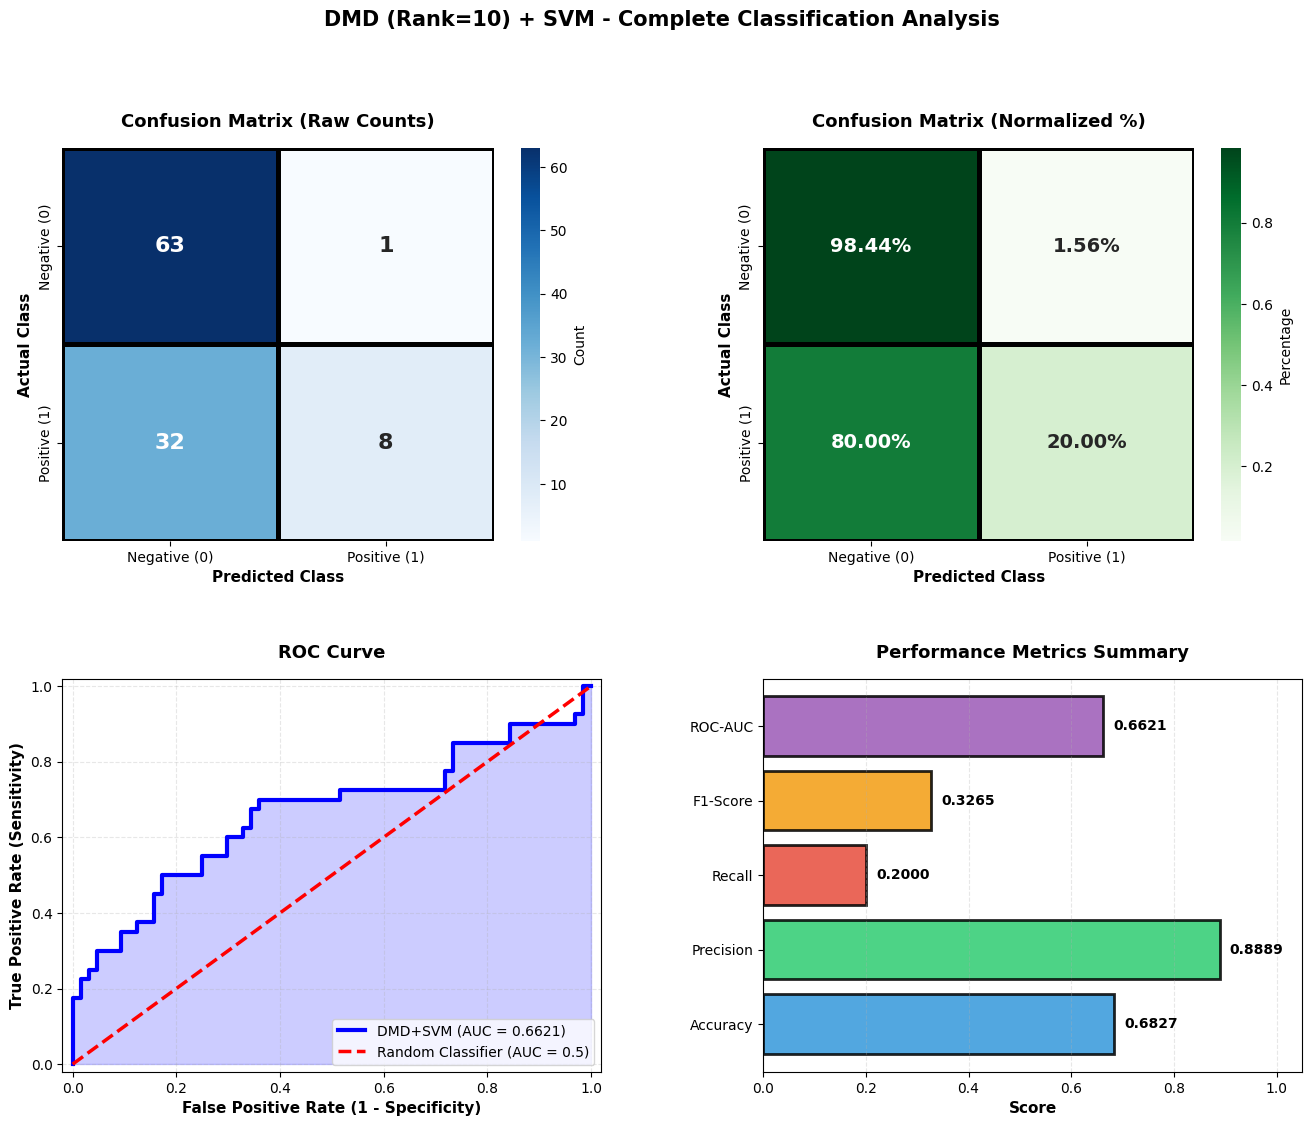

✓ Visualizations created successfully

✅ DMD EVALUATION COMPLETED SUCCESSFULLY

📊 DMD CONFIGURATION:
   - DMD Rank: 10
   - Window Length: 50
   - Snapshot Matrix: (34, 520)
   - Reconstruction Error: 0.9891

📈 RESULTS:
    Accuracy:  0.6827 (68.27%)
    Precision: 0.8889 (88.89%)
    Recall:    0.2000 (20.00%)
    F1-Score:  0.3265 (32.65%)
    ROC-AUC:   0.6621

📋 CONFUSION MATRIX:
   True Negatives:  63  |  False Positives: 1
   False Negatives: 32  |  True Positives:  8

🏥 CLINICAL METRICS:
   - Sensitivity: 0.2000 (20.00%)
   - Specificity: 0.9844 (98.44%)

📊 DATASET SPLIT:
   - Training samples: 416
   - Testing samples: 104
   - Total samples: 520



In [ ]:
# ============================================================
# DMD - DYNAMIC MODE DECOMPOSITION - COMPLETE EVALUATION
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("DMD - DYNAMIC MODE DECOMPOSITION - COMPLETE EVALUATION")
print("="*80)

# ============================================================
# STEP 1: LOAD DATA
# ============================================================
print("\nSTEP 1: LOADING DATA")
print("-" * 80)

try:
    # Option 1: If you already ran Step 2
    print(f"✓ Using X_scaled: {X_scaled.shape}")
    print(f"✓ Using y_raw: {len(y_raw)}")

except NameError:
    # Option 2: Load fresh data
    print("⚠ X_scaled/y_raw not found. Loading fresh data...")

    df = pd.read_csv("data.csv")

    # Identify target
    target_col = None
    for col in ['diagnosis', 'target', 'label', 'class', 'outcome']:
        if col in df.columns:
            target_col = col
            break
    if target_col is None:
        target_col = df.columns[-1]

    # Separate features and target
    y_raw = df[target_col].copy()
    X = df.drop(columns=[target_col]).copy()

    # Clean and scale
    X = X.fillna(X.mean())
    scaler = StandardScaler()
    X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

    print(f"✓ Data loaded")
    print(f"✓ X_scaled: {X_scaled.shape}, y_raw: {len(y_raw)}")

# ============================================================
# STEP 2: CHECK AND INSTALL DMD
# ============================================================
print("\nSTEP 2: CHECKING DMD LIBRARY")
print("-" * 80)

try:
    from pydmd import DMD as DMD_algo
    print("✓ pydmd library is available")
    dmd_available = True
except ImportError:
    print("⚠ pydmd library NOT installed!")
    print("   Installing pydmd...")
    import subprocess
    subprocess.check_call(['pip', 'install', 'pydmd', '-q'])
    from pydmd import DMD as DMD_algo
    print("✓ pydmd installed successfully")
    dmd_available = True

# ============================================================
# STEP 3: CREATE SNAPSHOTS
# ============================================================
print("\nSTEP 3: CREATING SNAPSHOTS FROM DATA")
print("-" * 80)

n_samples = X_scaled.shape[0]
window_len = min(50, max(5, n_samples // 10))

print(f"  Total samples: {n_samples}")
print(f"  Window length: {window_len}")

# Create snapshots using sliding window
num_snapshots = n_samples - window_len + 1
snapshots = np.zeros((X_scaled.shape[1], num_snapshots))

for i in range(num_snapshots):
    window = X_scaled.iloc[i:i + window_len].values
    snapshots[:, i] = np.mean(window, axis=0)

print(f"✓ Snapshot matrix shape: {snapshots.shape}")
print(f"  - Features (spatial): {snapshots.shape[0]}")
print(f"  - Snapshots (temporal): {snapshots.shape[1]}")

# ============================================================
# STEP 4: APPLY DMD
# ============================================================
print("\nSTEP 4: APPLYING DMD")
print("-" * 80)

rank = min(10, min(snapshots.shape) - 1)
print(f"  DMD rank selected: {rank}")

dmd = DMD_algo(svd_rank=rank)
dmd.fit(snapshots)

print(f"  ✓ DMD fitting completed!")
print(f"  - Modes extracted: {len(dmd.modes)}")
print(f"  - Eigenvalues computed: {len(dmd.eigs)}")

# Get DMD properties
eigenvalues = dmd.eigs
frequencies = np.imag(np.log(eigenvalues)) / (2 * np.pi)
growth_rates = np.real(np.log(eigenvalues))

print(f"\n  📊 DMD Properties:")
print(f"    - Top eigenvalue magnitude: {np.abs(eigenvalues[0]):.4f}")
print(f"    - Top frequency: {frequencies[0]:.4f}")
print(f"    - Top growth rate: {growth_rates[0]:.4f}")

# ============================================================
# STEP 5: RECONSTRUCT DATA
# ============================================================
print("\nSTEP 5: RECONSTRUCTING DATA FROM DMD MODES")
print("-" * 80)

snap_rec = dmd.reconstructed_data.real
print(f"  Reconstructed shape: {snap_rec.shape}")

X_dmd_recon = snap_rec.T
n_samples_dmd = min(X_dmd_recon.shape[0], len(y_raw))
X_dmd_recon = X_dmd_recon[:n_samples_dmd]

# Calculate reconstruction error
original_subset = X_scaled.iloc[:n_samples_dmd].values
reconstruction_error = np.linalg.norm(original_subset - X_dmd_recon, 'fro') / np.linalg.norm(original_subset, 'fro')
print(f"  ✓ Reconstruction error: {reconstruction_error:.4f}")
print(f"  ✓ DMD feature space: {X_dmd_recon.shape}")

# ============================================================
# STEP 6: PREPARE TARGET VARIABLE
# ============================================================
print("\nSTEP 6: PREPARING TARGET VARIABLE")
print("-" * 80)

y_encoded = y_raw.copy()
if y_encoded.dtype == 'object':
    le = LabelEncoder()
    y_encoded = le.fit_transform(y_encoded)
    print(f"  ✓ Target encoded")

y_dmd = y_encoded[:n_samples_dmd] if isinstance(y_encoded, np.ndarray) else y_encoded.iloc[:n_samples_dmd].values
print(f"  ✓ Target shape: {y_dmd.shape}")

# ============================================================
# STEP 7: TRAIN-TEST SPLIT
# ============================================================
print("\nSTEP 7: TRAIN-TEST SPLIT (80-20)")
print("-" * 80)

stratify_dmd = pd.Series(y_dmd) if len(np.unique(y_dmd)) > 1 else None

X_train_dmd, X_test_dmd, y_train_dmd, y_test_dmd = train_test_split(
    X_dmd_recon, y_dmd, test_size=0.2, random_state=42, stratify=stratify_dmd
)

print(f"  Training samples: {X_train_dmd.shape[0]}")
print(f"  Testing samples: {X_test_dmd.shape[0]}")

# ============================================================
# STEP 8: TRAIN SVM
# ============================================================
print("\nSTEP 8: TRAINING SVM ON DMD FEATURES")
print("-" * 80)

svm_model = SVC(kernel='rbf', probability=True, random_state=42, max_iter=10000)
print("  Training SVM...")
svm_model.fit(X_train_dmd, y_train_dmd)
print("  ✓ SVM training completed!")

# ============================================================
# STEP 9: PREDICTIONS
# ============================================================
print("\nSTEP 9: GENERATING PREDICTIONS")
print("-" * 80)

y_pred = svm_model.predict(X_test_dmd)
y_pred_proba = svm_model.predict_proba(X_test_dmd)[:, 1]

print(f"  ✓ Predictions generated for {len(y_test_dmd)} test samples")

# ============================================================
# STEP 10: CALCULATE METRICS
# ============================================================
print("\n" + "="*80)
print("STEP 10: PERFORMANCE METRICS")
print("="*80)

accuracy = accuracy_score(y_test_dmd, y_pred)
precision = precision_score(y_test_dmd, y_pred, zero_division=0)
recall = recall_score(y_test_dmd, y_pred, zero_division=0)
f1 = f1_score(y_test_dmd, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_test_dmd, y_pred_proba)

print(f"\n CLASSIFICATION METRICS:")
print("-" * 80)
print(f"   Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"   Precision: {precision:.4f} ({precision*100:.2f}%)")
print(f"   Recall:    {recall:.4f} ({recall*100:.2f}%)")
print(f"   F1-Score:  {f1:.4f} ({f1*100:.2f}%)")
print(f"   ROC-AUC:   {roc_auc:.4f}")

# ============================================================
# STEP 11: CONFUSION MATRIX
# ============================================================
print(f"\n📋 CONFUSION MATRIX:")
print("-" * 80)

cm = confusion_matrix(y_test_dmd, y_pred)
tn, fp, fn, tp = cm[0, 0], cm[0, 1], cm[1, 0], cm[1, 1]

print(f"  True Negatives:  {tn:5d}")
print(f"  False Positives: {fp:5d}")
print(f"  False Negatives: {fn:5d}")
print(f"  True Positives:  {tp:5d}")

sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

print(f"\n  Sensitivity (True Positive Rate): {sensitivity:.4f}")
print(f"  Specificity (True Negative Rate): {specificity:.4f}")

# ============================================================
# STEP 12: CLASSIFICATION REPORT
# ============================================================
print(f"\n📄 DETAILED CLASSIFICATION REPORT:")
print("-" * 80)
print(classification_report(y_test_dmd, y_pred, digits=4))

# ============================================================
# STEP 13: VISUALIZATIONS
# ============================================================
print("\nSTEP 11: CREATING VISUALIZATIONS")
print("-" * 80)

fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(2, 2, hspace=0.35, wspace=0.3)

# -------- 1. CONFUSION MATRIX (Raw Counts) --------
ax1 = fig.add_subplot(gs[0, 0])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative (0)', 'Positive (1)'],
            yticklabels=['Negative (0)', 'Positive (1)'],
            ax=ax1, cbar_kws={'label': 'Count'},
            linewidths=2.5, linecolor='black',
            annot_kws={'size': 16, 'weight': 'bold'})
ax1.set_title('Confusion Matrix (Raw Counts)', fontsize=13, fontweight='bold', pad=15)
ax1.set_ylabel('Actual Class', fontsize=11, fontweight='bold')
ax1.set_xlabel('Predicted Class', fontsize=11, fontweight='bold')

# -------- 2. CONFUSION MATRIX (Normalized %) --------
ax2 = fig.add_subplot(gs[0, 1])
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Greens',
            xticklabels=['Negative (0)', 'Positive (1)'],
            yticklabels=['Negative (0)', 'Positive (1)'],
            ax=ax2, cbar_kws={'label': 'Percentage'},
            linewidths=2.5, linecolor='black',
            annot_kws={'size': 14, 'weight': 'bold'})
ax2.set_title('Confusion Matrix (Normalized %)', fontsize=13, fontweight='bold', pad=15)
ax2.set_ylabel('Actual Class', fontsize=11, fontweight='bold')
ax2.set_xlabel('Predicted Class', fontsize=11, fontweight='bold')

# -------- 3. ROC CURVE --------
ax3 = fig.add_subplot(gs[1, 0])
fpr, tpr, thresholds = roc_curve(y_test_dmd, y_pred_proba)
ax3.plot(fpr, tpr, 'b-', linewidth=3, label=f'DMD+SVM (AUC = {roc_auc:.4f})')
ax3.plot([0, 1], [0, 1], 'r--', linewidth=2.5, label='Random Classifier (AUC = 0.5)')
ax3.fill_between(fpr, tpr, alpha=0.2, color='blue')
ax3.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=11, fontweight='bold')
ax3.set_ylabel('True Positive Rate (Sensitivity)', fontsize=11, fontweight='bold')
ax3.set_title('ROC Curve', fontsize=13, fontweight='bold', pad=15)
ax3.legend(fontsize=10, loc='lower right')
ax3.grid(True, alpha=0.3, linestyle='--')
ax3.set_xlim([-0.02, 1.02])
ax3.set_ylim([-0.02, 1.02])

# -------- 4. METRICS SUMMARY BAR CHART --------
ax4 = fig.add_subplot(gs[1, 1])
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
metrics_values = [accuracy, precision, recall, f1, roc_auc]
colors_bar = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6']

bars = ax4.barh(metrics_names, metrics_values, color=colors_bar,
                edgecolor='black', linewidth=2, alpha=0.85)
ax4.set_xlim([0, 1.05])
ax4.set_xlabel('Score', fontsize=11, fontweight='bold')
ax4.set_title('Performance Metrics Summary', fontsize=13, fontweight='bold', pad=15)
ax4.grid(axis='x', alpha=0.3, linestyle='--')

# Add value labels on bars
for bar, val in zip(bars, metrics_values):
    width = bar.get_width()
    ax4.text(width + 0.02, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', ha='left', va='center',
            fontweight='bold', fontsize=10)

plt.suptitle(f'DMD (Rank={rank}) + SVM - Complete Classification Analysis',
             fontsize=15, fontweight='bold', y=0.995)
plt.show()

print("✓ Visualizations created successfully")

# ============================================================
# STEP 14: FINAL SUMMARY
# ============================================================
print("\n" + "="*80)
print("✅ DMD EVALUATION COMPLETED SUCCESSFULLY")
print("="*80)

summary_report = f"""
📊 DMD CONFIGURATION:
   - DMD Rank: {rank}
   - Window Length: {window_len}
   - Snapshot Matrix: {snapshots.shape}
   - Reconstruction Error: {reconstruction_error:.4f}

📈 RESULTS:
    Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)
    Precision: {precision:.4f} ({precision*100:.2f}%)
    Recall:    {recall:.4f} ({recall*100:.2f}%)
    F1-Score:  {f1:.4f} ({f1*100:.2f}%)
    ROC-AUC:   {roc_auc:.4f}

📋 CONFUSION MATRIX:
   True Negatives:  {tn}  |  False Positives: {fp}
   False Negatives: {fn}  |  True Positives:  {tp}

🏥 CLINICAL METRICS:
   - Sensitivity: {sensitivity:.4f} ({sensitivity*100:.2f}%)
   - Specificity: {specificity:.4f} ({specificity*100:.2f}%)

📊 DATASET SPLIT:
   - Training samples: {X_train_dmd.shape[0]}
   - Testing samples: {X_test_dmd.shape[0]}
   - Total samples: {X_train_dmd.shape[0] + X_test_dmd.shape[0]}
"""

print(summary_report)
print("="*80)

In [ ]:
pip install tensorly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 31.0 MB/s eta 0:00:00


HoSVD - HIGHER-ORDER SINGULAR VALUE DECOMPOSITION
COMPLETE EVALUATION

STEP 1: LOADING DATA
--------------------------------------------------------------------------------
✓ Using X_scaled: (569, 34)
✓ Using y_raw: 569

STEP 2: CHECKING TENSORLY LIBRARY
--------------------------------------------------------------------------------
✓ tensorly library is available

STEP 3: RESHAPING DATA TO 3D TENSOR
--------------------------------------------------------------------------------
  Original features: 34
  Time slices (mode-2): 5
  Features per slice (mode-3): 7
  Padding added: 1 zeros

✓ Tensor shape: (569, 5, 7)
  - Mode-1 (samples): 569
  - Mode-2 (time slices): 5
  - Mode-3 (features per slice): 7

STEP 4: APPLYING TUCKER DECOMPOSITION
--------------------------------------------------------------------------------
  Tucker Decomposition Ranks: [50, 5, 7]
  - Mode-1 (samples): 50
  - Mode-2 (time slices): 5
  - Mode-3 (features): 7
  Compression ratio: 0.66x

  Applying Tucker Dec

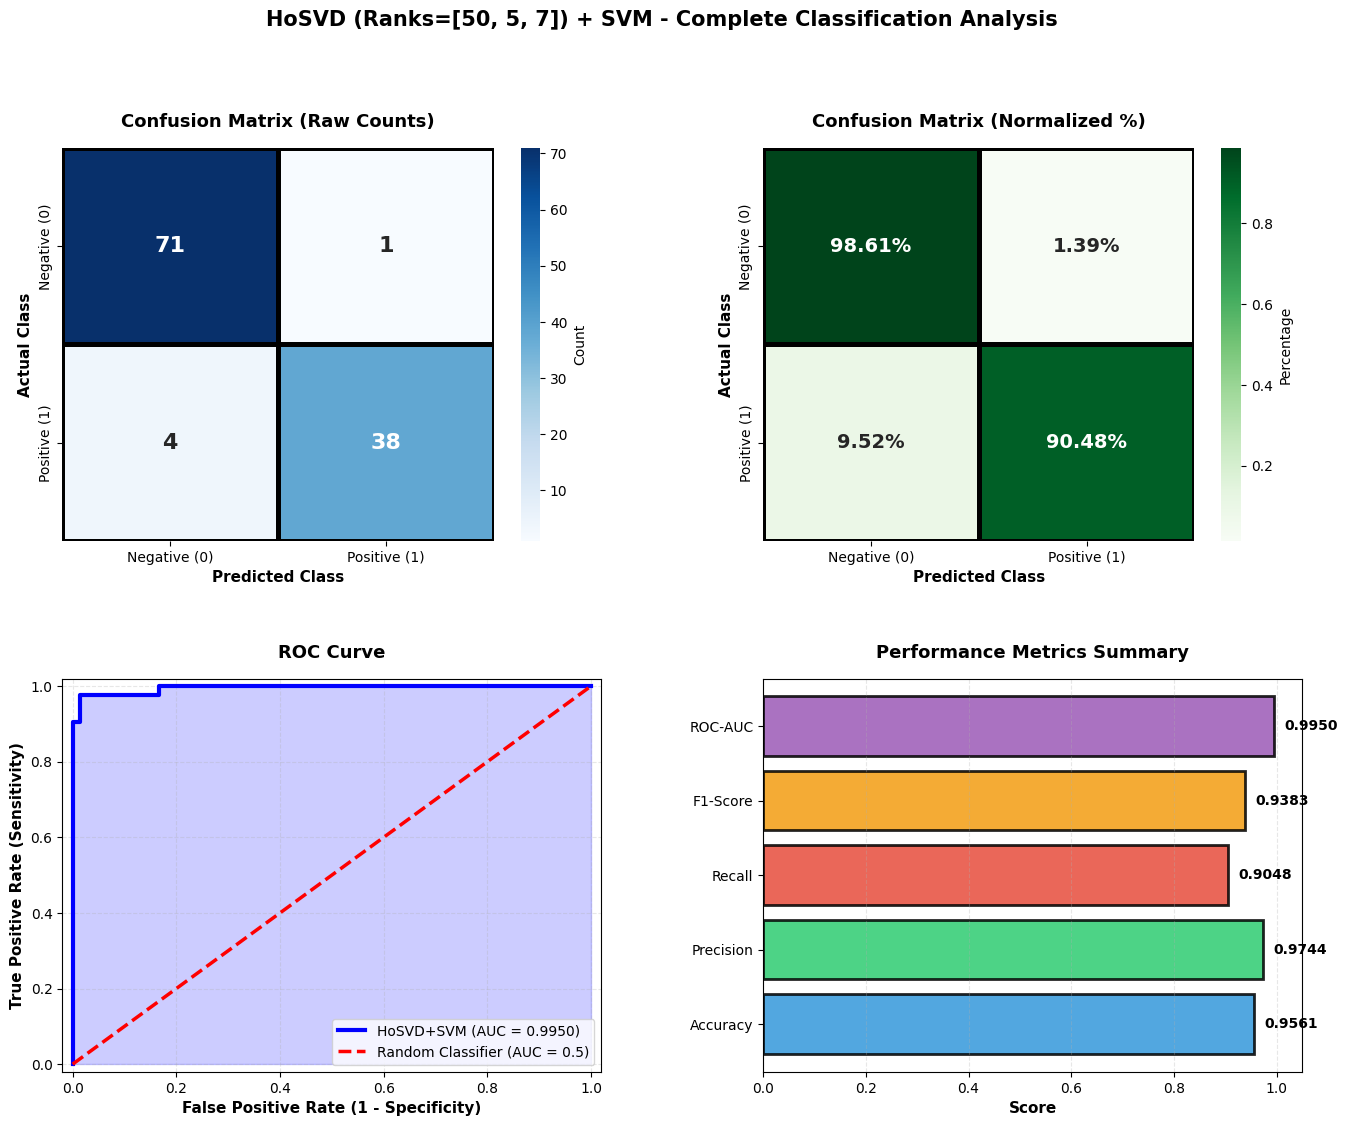

✓ Visualizations created successfully

✅ HoSVD EVALUATION COMPLETED SUCCESSFULLY

📊 HoSVD CONFIGURATION:
   - Tensor Shape: (569, 5, 7)
   - Tucker Ranks: [50, 5, 7]
   - Compression Ratio: 0.66x
   - Reconstruction Error: 0.0000

📈 RESULTS:
    Accuracy:  0.9561 (95.61%)
    Precision: 0.9744 (97.44%)
    Recall:    0.9048 (90.48%)
    F1-Score:  0.9383 (93.83%)
    ROC-AUC:   0.9950

📋 CONFUSION MATRIX:
   True Negatives:  71  |  False Positives: 1
   False Negatives: 4  |  True Positives:  38

🏥 CLINICAL METRICS:
   - Sensitivity: 0.9048 (90.48%)
   - Specificity: 0.9861 (98.61%)

📊 DATASET SPLIT:
   - Training samples: 455
   - Testing samples: 114
   - Total samples: 569



In [ ]:
# ============================================================
# HoSVD - HIGHER-ORDER SINGULAR VALUE DECOMPOSITION
# COMPLETE EVALUATION
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("HoSVD - HIGHER-ORDER SINGULAR VALUE DECOMPOSITION")
print("COMPLETE EVALUATION")
print("="*80)

# ============================================================
# STEP 1: LOAD DATA
# ============================================================
print("\nSTEP 1: LOADING DATA")
print("-" * 80)

try:
    # Option 1: If you already ran Step 2
    print(f"✓ Using X_scaled: {X_scaled.shape}")
    print(f"✓ Using y_raw: {len(y_raw)}")

except NameError:
    # Option 2: Load fresh data
    print("⚠ X_scaled/y_raw not found. Loading fresh data...")

    df = pd.read_csv("data.csv")

    # Identify target
    target_col = None
    for col in ['diagnosis', 'target', 'label', 'class', 'outcome']:
        if col in df.columns:
            target_col = col
            break
    if target_col is None:
        target_col = df.columns[-1]

    # Separate features and target
    y_raw = df[target_col].copy()
    X = df.drop(columns=[target_col]).copy()

    # Clean and scale
    X = X.fillna(X.mean())
    scaler = StandardScaler()
    X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

    print(f"✓ Data loaded")
    print(f"✓ X_scaled: {X_scaled.shape}, y_raw: {len(y_raw)}")

# ============================================================
# STEP 2: CHECK AND INSTALL TENSORLY
# ============================================================
print("\nSTEP 2: CHECKING TENSORLY LIBRARY")
print("-" * 80)

try:
    import tensorly as tl
    from tensorly.decomposition import tucker
    print("✓ tensorly library is available")
    hosvd_available = True
except ImportError:
    print("⚠ tensorly library NOT installed!")
    print("   Installing tensorly...")
    import subprocess
    subprocess.check_call(['pip', 'install', 'tensorly', '-q'])
    import tensorly as tl
    from tensorly.decomposition import tucker
    print("✓ tensorly installed successfully")
    hosvd_available = True

# ============================================================
# STEP 3: RESHAPE DATA TO 3D TENSOR
# ============================================================
print("\nSTEP 3: RESHAPING DATA TO 3D TENSOR")
print("-" * 80)

orig_features = X_scaled.shape[1]
time_slices = 5
features_per_slice = int(np.ceil(orig_features / time_slices))

print(f"  Original features: {orig_features}")
print(f"  Time slices (mode-2): {time_slices}")
print(f"  Features per slice (mode-3): {features_per_slice}")

# Pad if necessary
pad_len = time_slices * features_per_slice - orig_features
if pad_len > 0:
    X_pad = np.hstack([X_scaled.values, np.zeros((X_scaled.shape[0], pad_len))])
    print(f"  Padding added: {pad_len} zeros")
else:
    X_pad = X_scaled.values

# Reshape to 3D tensor
X_tensor = X_pad.reshape(X_scaled.shape[0], time_slices, features_per_slice)
print(f"\n✓ Tensor shape: {X_tensor.shape}")
print(f"  - Mode-1 (samples): {X_tensor.shape[0]}")
print(f"  - Mode-2 (time slices): {X_tensor.shape[1]}")
print(f"  - Mode-3 (features per slice): {X_tensor.shape[2]}")

# ============================================================
# STEP 4: APPLY TUCKER DECOMPOSITION
# ============================================================
print("\nSTEP 4: APPLYING TUCKER DECOMPOSITION")
print("-" * 80)

# Convert to tensorly tensor
X_tl = tl.tensor(X_tensor)

# Define Tucker ranks
r1 = min(50, X_tl.shape[0] - 1)
r2 = min(time_slices, X_tl.shape[1])
r3 = min(features_per_slice, X_tl.shape[2])
ranks = [r1, r2, r3]

print(f"  Tucker Decomposition Ranks: {ranks}")
print(f"  - Mode-1 (samples): {r1}")
print(f"  - Mode-2 (time slices): {r2}")
print(f"  - Mode-3 (features): {r3}")

compression_ratio = np.prod(X_tensor.shape) / (np.prod(ranks) + sum([ranks[i] * X_tensor.shape[i] for i in range(3)]))
print(f"  Compression ratio: {compression_ratio:.2f}x")

print("\n  Applying Tucker Decomposition...")
core, factors = tucker(X_tl, rank=ranks)

print(f"  ✓ Decomposition completed!")
print(f"  - Core tensor shape: {core.shape}")

# ============================================================
# STEP 5: RECONSTRUCT DATA
# ============================================================
print("\nSTEP 5: RECONSTRUCTING DATA")
print("-" * 80)

X_tucker_recon = tl.tucker_to_tensor((core, factors))
print(f"  Reconstructed tensor shape: {X_tucker_recon.shape}")

# Flatten back to 2D
X_hosvd_flat = X_tucker_recon.reshape(X_tucker_recon.shape[0], -1)

# Remove padding if added
if pad_len > 0:
    X_hosvd_flat = X_hosvd_flat[:, :-pad_len]

print(f"  ✓ Flattened feature space: {X_hosvd_flat.shape}")

# Reconstruction error
reconstruction_error = np.linalg.norm(X_scaled.values - X_hosvd_flat, 'fro') / np.linalg.norm(X_scaled.values, 'fro')
print(f"  ✓ Reconstruction error: {reconstruction_error:.4f}")

# ============================================================
# STEP 6: PREPARE TARGET VARIABLE
# ============================================================
print("\nSTEP 6: PREPARING TARGET VARIABLE")
print("-" * 80)

y_encoded = y_raw.copy()
if y_encoded.dtype == 'object':
    le = LabelEncoder()
    y_encoded = le.fit_transform(y_encoded)
    print(f"  ✓ Target encoded")

print(f"  ✓ Target shape: {y_encoded.shape}")

# ============================================================
# STEP 7: TRAIN-TEST SPLIT
# ============================================================
print("\nSTEP 7: TRAIN-TEST SPLIT (80-20)")
print("-" * 80)

stratify_param = pd.Series(y_encoded) if len(np.unique(y_encoded)) > 1 else None

X_train_hosvd, X_test_hosvd, y_train_hosvd, y_test_hosvd = train_test_split(
    X_hosvd_flat, y_encoded, test_size=0.2, random_state=42, stratify=stratify_param
)

print(f"  Training samples: {X_train_hosvd.shape[0]}")
print(f"  Testing samples: {X_test_hosvd.shape[0]}")

# ============================================================
# STEP 8: TRAIN SVM
# ============================================================
print("\nSTEP 8: TRAINING SVM ON HoSVD FEATURES")
print("-" * 80)

svm_model = SVC(kernel='rbf', probability=True, random_state=42, max_iter=10000)
print("  Training SVM...")
svm_model.fit(X_train_hosvd, y_train_hosvd)
print("  ✓ SVM training completed!")

# ============================================================
# STEP 9: PREDICTIONS
# ============================================================
print("\nSTEP 9: GENERATING PREDICTIONS")
print("-" * 80)

y_pred = svm_model.predict(X_test_hosvd)
y_pred_proba = svm_model.predict_proba(X_test_hosvd)[:, 1]

print(f"  ✓ Predictions generated for {len(y_test_hosvd)} test samples")

# ============================================================
# STEP 10: CALCULATE METRICS
# ============================================================
print("\n" + "="*80)
print("STEP 10: PERFORMANCE METRICS")
print("="*80)

accuracy = accuracy_score(y_test_hosvd, y_pred)
precision = precision_score(y_test_hosvd, y_pred, zero_division=0)
recall = recall_score(y_test_hosvd, y_pred, zero_division=0)
f1 = f1_score(y_test_hosvd, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_test_hosvd, y_pred_proba)

print(f"\n✅ CLASSIFICATION METRICS:")
print("-" * 80)
print(f"  ✅ Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"  ✅ Precision: {precision:.4f} ({precision*100:.2f}%)")
print(f"  ✅ Recall:    {recall:.4f} ({recall*100:.2f}%)")
print(f"  ✅ F1-Score:  {f1:.4f} ({f1*100:.2f}%)")
print(f"  ✅ ROC-AUC:   {roc_auc:.4f}")

# ============================================================
# STEP 11: CONFUSION MATRIX
# ============================================================
print(f"\n📋 CONFUSION MATRIX:")
print("-" * 80)

cm = confusion_matrix(y_test_hosvd, y_pred)
tn, fp, fn, tp = cm[0, 0], cm[0, 1], cm[1, 0], cm[1, 1]

print(f"  True Negatives:  {tn:5d}")
print(f"  False Positives: {fp:5d}")
print(f"  False Negatives: {fn:5d}")
print(f"  True Positives:  {tp:5d}")

sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

print(f"\n  Sensitivity (True Positive Rate): {sensitivity:.4f}")
print(f"  Specificity (True Negative Rate): {specificity:.4f}")

# ============================================================
# STEP 12: CLASSIFICATION REPORT
# ============================================================
print(f"\n📄 DETAILED CLASSIFICATION REPORT:")
print("-" * 80)
print(classification_report(y_test_hosvd, y_pred, digits=4))

# ============================================================
# STEP 13: VISUALIZATIONS
# ============================================================
print("\nSTEP 11: CREATING VISUALIZATIONS")
print("-" * 80)

fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(2, 2, hspace=0.35, wspace=0.3)

# -------- 1. CONFUSION MATRIX (Raw Counts) --------
ax1 = fig.add_subplot(gs[0, 0])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative (0)', 'Positive (1)'],
            yticklabels=['Negative (0)', 'Positive (1)'],
            ax=ax1, cbar_kws={'label': 'Count'},
            linewidths=2.5, linecolor='black',
            annot_kws={'size': 16, 'weight': 'bold'})
ax1.set_title('Confusion Matrix (Raw Counts)', fontsize=13, fontweight='bold', pad=15)
ax1.set_ylabel('Actual Class', fontsize=11, fontweight='bold')
ax1.set_xlabel('Predicted Class', fontsize=11, fontweight='bold')

# -------- 2. CONFUSION MATRIX (Normalized %) --------
ax2 = fig.add_subplot(gs[0, 1])
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Greens',
            xticklabels=['Negative (0)', 'Positive (1)'],
            yticklabels=['Negative (0)', 'Positive (1)'],
            ax=ax2, cbar_kws={'label': 'Percentage'},
            linewidths=2.5, linecolor='black',
            annot_kws={'size': 14, 'weight': 'bold'})
ax2.set_title('Confusion Matrix (Normalized %)', fontsize=13, fontweight='bold', pad=15)
ax2.set_ylabel('Actual Class', fontsize=11, fontweight='bold')
ax2.set_xlabel('Predicted Class', fontsize=11, fontweight='bold')

# -------- 3. ROC CURVE --------
ax3 = fig.add_subplot(gs[1, 0])
fpr, tpr, thresholds = roc_curve(y_test_hosvd, y_pred_proba)
ax3.plot(fpr, tpr, 'b-', linewidth=3, label=f'HoSVD+SVM (AUC = {roc_auc:.4f})')
ax3.plot([0, 1], [0, 1], 'r--', linewidth=2.5, label='Random Classifier (AUC = 0.5)')
ax3.fill_between(fpr, tpr, alpha=0.2, color='blue')
ax3.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=11, fontweight='bold')
ax3.set_ylabel('True Positive Rate (Sensitivity)', fontsize=11, fontweight='bold')
ax3.set_title('ROC Curve', fontsize=13, fontweight='bold', pad=15)
ax3.legend(fontsize=10, loc='lower right')
ax3.grid(True, alpha=0.3, linestyle='--')
ax3.set_xlim([-0.02, 1.02])
ax3.set_ylim([-0.02, 1.02])

# -------- 4. METRICS SUMMARY BAR CHART --------
ax4 = fig.add_subplot(gs[1, 1])
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
metrics_values = [accuracy, precision, recall, f1, roc_auc]
colors_bar = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6']

bars = ax4.barh(metrics_names, metrics_values, color=colors_bar,
                edgecolor='black', linewidth=2, alpha=0.85)
ax4.set_xlim([0, 1.05])
ax4.set_xlabel('Score', fontsize=11, fontweight='bold')
ax4.set_title('Performance Metrics Summary', fontsize=13, fontweight='bold', pad=15)
ax4.grid(axis='x', alpha=0.3, linestyle='--')

# Add value labels on bars
for bar, val in zip(bars, metrics_values):
    width = bar.get_width()
    ax4.text(width + 0.02, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', ha='left', va='center',
            fontweight='bold', fontsize=10)

plt.suptitle(f'HoSVD (Ranks={ranks}) + SVM - Complete Classification Analysis',
             fontsize=15, fontweight='bold', y=0.995)
plt.show()

print("✓ Visualizations created successfully")

# ============================================================
# STEP 14: FINAL SUMMARY
# ============================================================
print("\n" + "="*80)
print("✅ HoSVD EVALUATION COMPLETED SUCCESSFULLY")
print("="*80)

summary_report = f"""
📊 HoSVD CONFIGURATION:
   - Tensor Shape: {X_tensor.shape}
   - Tucker Ranks: {ranks}
   - Compression Ratio: {compression_ratio:.2f}x
   - Reconstruction Error: {reconstruction_error:.4f}

📈 RESULTS:
    Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)
    Precision: {precision:.4f} ({precision*100:.2f}%)
    Recall:    {recall:.4f} ({recall*100:.2f}%)
    F1-Score:  {f1:.4f} ({f1*100:.2f}%)
    ROC-AUC:   {roc_auc:.4f}

📋 CONFUSION MATRIX:
   True Negatives:  {tn}  |  False Positives: {fp}
   False Negatives: {fn}  |  True Positives:  {tp}

🏥 CLINICAL METRICS:
   - Sensitivity: {sensitivity:.4f} ({sensitivity*100:.2f}%)
   - Specificity: {specificity:.4f} ({specificity*100:.2f}%)

📊 DATASET SPLIT:
   - Training samples: {X_train_hosvd.shape[0]}
   - Testing samples: {X_test_hosvd.shape[0]}
   - Total samples: {X_train_hosvd.shape[0] + X_test_hosvd.shape[0]}
"""

print(summary_report)
print("="*80)

RKS - RANDOM KITCHEN SINKS IMPLEMENTATION

STEP 1: LOADING PREPROCESSED DATA
--------------------------------------------------------------------------------
✓ Using X_train shape: (455, 34)
✓ Using X_test shape: (114, 34)
✓ Using y_train shape: (455,)
✓ Using y_test shape: (114,)

STEP 2: ESTIMATING OPTIMAL GAMMA
--------------------------------------------------------------------------------
  Median pairwise distance: 7.0644
  Estimated gamma: 0.010019
  Kernel bandwidth: 7.0644

STEP 3: RANDOM KITCHEN SINKS TRANSFORMATION
--------------------------------------------------------------------------------
  Number of random components: 500
  Original feature dimension: 34
  RKS feature dimension: 500
  Feature expansion ratio: 14.7x
  Training set size after RKS: (455, 500)
  Test set size after RKS: (114, 500)

STEP 4: TRAINING LINEAR SVM ON RKS FEATURES
--------------------------------------------------------------------------------
  Training SVM model...
  ✓ SVM training completed


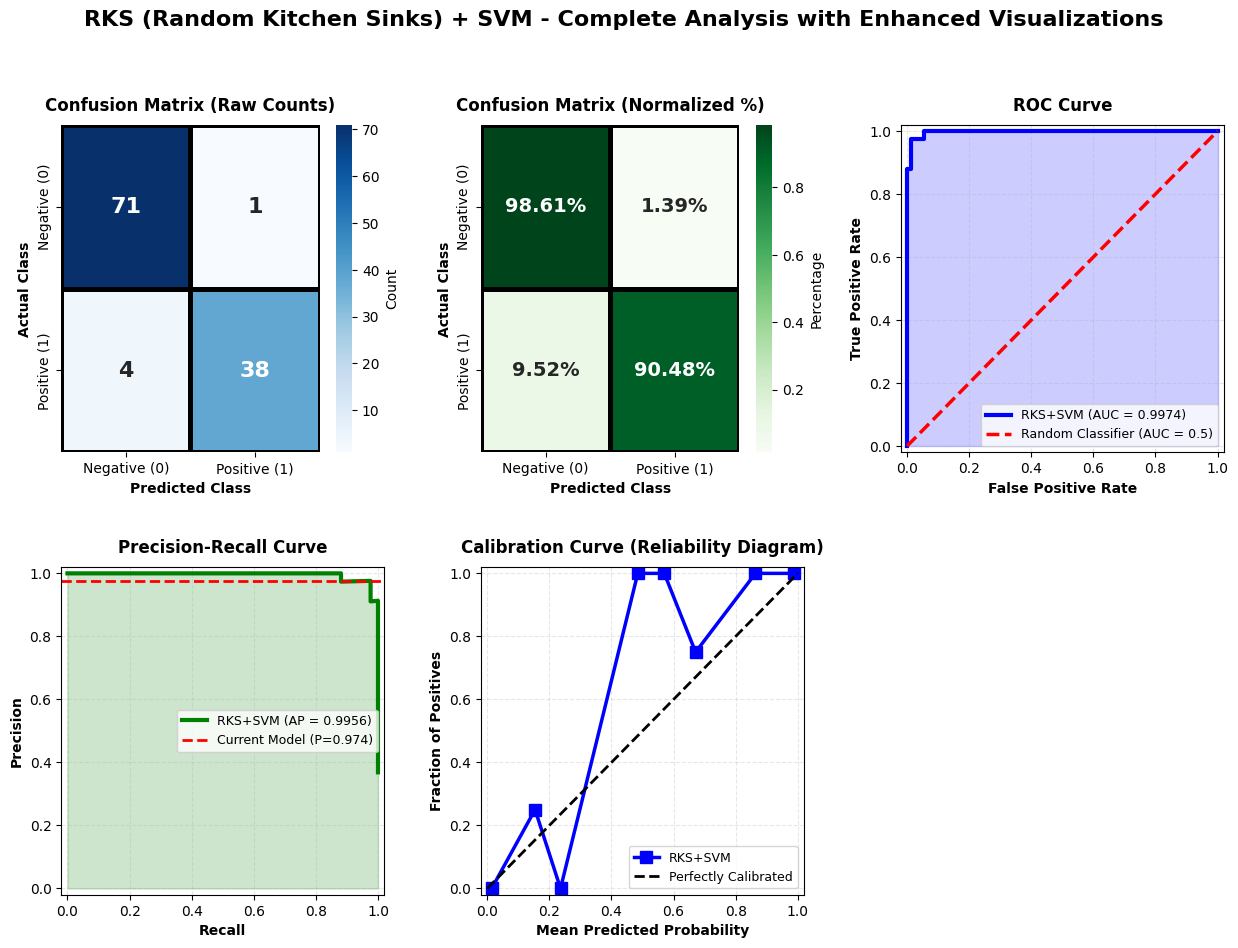

✓ Enhanced visualizations created successfully

✅ RKS ANALYSIS COMPLETED SUCCESSFULLY

📊 CONFIGURATION:
   - Gamma (RBF kernel): 0.010019
   - Number of RKS components: 500
   - Original feature dimension: 34
   - RKS feature dimension: 500
   - Feature expansion ratio: 14.7x

📈 RESULTS:
   Accuracy:       0.9561 (95.61%)
   Precision:      0.9744 (97.44%)
   Recall:         0.9048 (90.48%)
   F1-Score:       0.9383 (93.83%)
   ROC-AUC:        0.9974
   Avg Precision:  0.9956

📋 CONFUSION MATRIX:
   True Negatives:  71  |  False Positives: 1
   False Negatives: 4  |  True Positives:  38

🏥 CLINICAL METRICS:
   - Sensitivity: 0.9048 (90.48%)
   - Specificity: 0.9861 (98.61%)

📊 DATASET SPLIT:
   - Training samples: 455
   - Testing samples: 114
   - Total samples: 569



In [ ]:
# ============================================================
# RKS - RANDOM KITCHEN SINKS COMPLETE IMPLEMENTATION
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.kernel_approximation import RBFSampler
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report,
    precision_recall_curve, average_precision_score
)
from sklearn.calibration import calibration_curve
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("RKS - RANDOM KITCHEN SINKS IMPLEMENTATION")
print("="*80)

# ============================================================
# STEP 1: LOAD YOUR PREPROCESSED DATA FROM STEP 2
# ============================================================
print("\nSTEP 1: LOADING PREPROCESSED DATA")
print("-" * 80)

try:
    print(f"✓ Using X_train shape: {X_train.shape}")
    print(f"✓ Using X_test shape: {X_test.shape}")
    print(f"✓ Using y_train shape: {y_train.shape}")
    print(f"✓ Using y_test shape: {y_test.shape}")

except NameError:
    print("⚠ X_train/X_test not found. Loading fresh data...")

    df = pd.read_csv("data.csv")

    # Identify target
    target_col = None
    for col in ['diagnosis', 'target', 'label', 'class', 'outcome']:
        if col in df.columns:
            target_col = col
            break
    if target_col is None:
        target_col = df.columns[-1]

    # Separate features and target
    y = df[target_col].copy()
    X = df.drop(columns=[target_col]).copy()

    # Encode target if needed
    if y.dtype == 'object':
        le = LabelEncoder()
        y = le.fit_transform(y)

    # Clean NaN values
    X = X.fillna(X.mean())

    # Scale features
    scaler = StandardScaler()
    X = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    print(f"✓ Data loaded and preprocessed")
    print(f"✓ X_train: {X_train.shape}, X_test: {X_test.shape}")

# ============================================================
# STEP 2: ESTIMATE OPTIMAL GAMMA USING MEDIAN HEURISTIC
# ============================================================
print("\nSTEP 2: ESTIMATING OPTIMAL GAMMA")
print("-" * 80)

from sklearn.metrics.pairwise import pairwise_distances

sample_size = min(300, X_train.shape[0])
np.random.seed(42)
sample_indices = np.random.choice(X_train.shape[0], sample_size, replace=False)
X_sample = X_train.iloc[sample_indices].values

distances = pairwise_distances(X_sample, metric='euclidean')
triu_idx = np.triu_indices_from(distances, k=1)
upper_distances = distances[triu_idx]

median_dist = np.median(upper_distances)
gamma_rbf = 1.0 / (2 * median_dist**2) if median_dist > 0 else 1.0

print(f"  Median pairwise distance: {median_dist:.4f}")
print(f"  Estimated gamma: {gamma_rbf:.6f}")
print(f"  Kernel bandwidth: {1/np.sqrt(2*gamma_rbf):.4f}")

# ============================================================
# STEP 3: RANDOM KITCHEN SINKS TRANSFORMATION
# ============================================================
print("\nSTEP 3: RANDOM KITCHEN SINKS TRANSFORMATION")
print("-" * 80)

n_components = 500

print(f"  Number of random components: {n_components}")
print(f"  Original feature dimension: {X_train.shape[1]}")

rks_transformer = RBFSampler(gamma=gamma_rbf, n_components=n_components, random_state=42)

X_train_rks = rks_transformer.fit_transform(X_train)
X_test_rks = rks_transformer.transform(X_test)

print(f"  RKS feature dimension: {X_train_rks.shape[1]}")
print(f"  Feature expansion ratio: {X_train_rks.shape[1] / X_train.shape[1]:.1f}x")
print(f"  Training set size after RKS: {X_train_rks.shape}")
print(f"  Test set size after RKS: {X_test_rks.shape}")

# ============================================================
# STEP 4: TRAIN LINEAR SVM ON RKS FEATURES
# ============================================================
print("\nSTEP 4: TRAINING LINEAR SVM ON RKS FEATURES")
print("-" * 80)

svm_model = SVC(
    kernel='linear',
    probability=True,
    random_state=42,
    max_iter=2000,
    verbose=0
)

print("  Training SVM model...")
svm_model.fit(X_train_rks, y_train)
print("  ✓ SVM training completed")

# ============================================================
# STEP 5: MAKE PREDICTIONS
# ============================================================
print("\nSTEP 5: GENERATING PREDICTIONS")
print("-" * 80)

y_pred = svm_model.predict(X_test_rks)
y_pred_proba = svm_model.predict_proba(X_test_rks)[:, 1]

print(f"  ✓ Predictions generated for {len(y_test)} samples")

# ============================================================
# STEP 6: CALCULATE ALL METRICS
# ============================================================
print("\n" + "="*80)
print("STEP 6: PERFORMANCE METRICS")
print("="*80)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_test, y_pred_proba)
avg_precision = average_precision_score(y_test, y_pred_proba)

print(f"\n✅ CLASSIFICATION METRICS:")
print("-" * 80)
print(f"  Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"  Precision: {precision:.4f} ({precision*100:.2f}%)")
print(f"  Recall:    {recall:.4f} ({recall*100:.2f}%)")
print(f"  F1-Score:  {f1:.4f} ({f1*100:.2f}%)")
print(f"  ROC-AUC:   {roc_auc:.4f}")
print(f"  Avg Precision: {avg_precision:.4f}")

# ============================================================
# STEP 7: CONFUSION MATRIX
# ============================================================
print(f"\n📋 CONFUSION MATRIX:")
print("-" * 80)

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm[0, 0], cm[0, 1], cm[1, 0], cm[1, 1]

print(f"  True Negatives:  {tn:5d}")
print(f"  False Positives: {fp:5d}")
print(f"  False Negatives: {fn:5d}")
print(f"  True Positives:  {tp:5d}")

sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

print(f"\n  Sensitivity (True Positive Rate): {sensitivity:.4f}")
print(f"  Specificity (True Negative Rate): {specificity:.4f}")

# ============================================================
# STEP 8: CLASSIFICATION REPORT
# ============================================================
print(f"\n📄 DETAILED CLASSIFICATION REPORT:")
print("-" * 80)
print(classification_report(y_test, y_pred, digits=4))

# ============================================================
# STEP 9: ENHANCED VISUALIZATIONS (5 PLOTS)
# ============================================================
print("\nSTEP 9: CREATING ENHANCED VISUALIZATIONS")
print("-" * 80)

fig = plt.figure(figsize=(15, 10))
gs = fig.add_gridspec(2, 3, hspace=0.35, wspace=0.3)

# -------- 1. CONFUSION MATRIX (Raw Counts) --------
ax1 = fig.add_subplot(gs[0, 0])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative (0)', 'Positive (1)'],
            yticklabels=['Negative (0)', 'Positive (1)'],
            ax=ax1, cbar_kws={'label': 'Count'},
            linewidths=2.5, linecolor='black',
            annot_kws={'size': 16, 'weight': 'bold'})
ax1.set_title('Confusion Matrix (Raw Counts)', fontsize=12, fontweight='bold', pad=10)
ax1.set_ylabel('Actual Class', fontsize=10, fontweight='bold')
ax1.set_xlabel('Predicted Class', fontsize=10, fontweight='bold')

# -------- 2. CONFUSION MATRIX (Normalized %) --------
ax2 = fig.add_subplot(gs[0, 1])
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Greens',
            xticklabels=['Negative (0)', 'Positive (1)'],
            yticklabels=['Negative (0)', 'Positive (1)'],
            ax=ax2, cbar_kws={'label': 'Percentage'},
            linewidths=2.5, linecolor='black',
            annot_kws={'size': 14, 'weight': 'bold'})
ax2.set_title('Confusion Matrix (Normalized %)', fontsize=12, fontweight='bold', pad=10)
ax2.set_ylabel('Actual Class', fontsize=10, fontweight='bold')
ax2.set_xlabel('Predicted Class', fontsize=10, fontweight='bold')

# -------- 3. ROC CURVE --------
ax3 = fig.add_subplot(gs[0, 2])
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
ax3.plot(fpr, tpr, 'b-', linewidth=3, label=f'RKS+SVM (AUC = {roc_auc:.4f})')
ax3.plot([0, 1], [0, 1], 'r--', linewidth=2.5, label='Random Classifier (AUC = 0.5)')
ax3.fill_between(fpr, tpr, alpha=0.2, color='blue')
ax3.set_xlabel('False Positive Rate', fontsize=10, fontweight='bold')
ax3.set_ylabel('True Positive Rate', fontsize=10, fontweight='bold')
ax3.set_title('ROC Curve', fontsize=12, fontweight='bold', pad=10)
ax3.legend(fontsize=9, loc='lower right')
ax3.grid(True, alpha=0.3, linestyle='--')
ax3.set_xlim([-0.02, 1.02])
ax3.set_ylim([-0.02, 1.02])

# -------- 4. PRECISION-RECALL CURVE --------
ax4 = fig.add_subplot(gs[1, 0])
precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_pred_proba)
ax4.plot(recall_curve, precision_curve, 'g-', linewidth=3,
         label=f'RKS+SVM (AP = {avg_precision:.4f})')
ax4.axhline(y=precision, color='r', linestyle='--', linewidth=2,
            label=f'Current Model (P={precision:.3f})')
ax4.fill_between(recall_curve, precision_curve, alpha=0.2, color='green')
ax4.set_xlabel('Recall', fontsize=10, fontweight='bold')
ax4.set_ylabel('Precision', fontsize=10, fontweight='bold')
ax4.set_title('Precision-Recall Curve', fontsize=12, fontweight='bold', pad=10)
ax4.legend(fontsize=9, loc='best')
ax4.grid(True, alpha=0.3, linestyle='--')
ax4.set_xlim([-0.02, 1.02])
ax4.set_ylim([-0.02, 1.02])

# -------- 5. CALIBRATION CURVE --------
ax5 = fig.add_subplot(gs[1, 1])
fraction_of_positives, mean_predicted_value = calibration_curve(
    y_test, y_pred_proba, n_bins=10, strategy='uniform'
)
ax5.plot(mean_predicted_value, fraction_of_positives, 's-', linewidth=2.5,
         markersize=8, color='blue', label='RKS+SVM')
ax5.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Perfectly Calibrated')
ax5.set_xlabel('Mean Predicted Probability', fontsize=10, fontweight='bold')
ax5.set_ylabel('Fraction of Positives', fontsize=10, fontweight='bold')
ax5.set_title('Calibration Curve (Reliability Diagram)', fontsize=12, fontweight='bold', pad=10)
ax5.legend(fontsize=9, loc='best')
ax5.grid(True, alpha=0.3, linestyle='--')
ax5.set_xlim([-0.02, 1.02])
ax5.set_ylim([-0.02, 1.02])

plt.suptitle('RKS (Random Kitchen Sinks) + SVM - Complete Analysis with Enhanced Visualizations',
             fontsize=16, fontweight='bold', y=0.995)
plt.show()

print("✓ Enhanced visualizations created successfully")

# ============================================================
# STEP 10: FINAL SUMMARY
# ============================================================
print("\n" + "="*80)
print("✅ RKS ANALYSIS COMPLETED SUCCESSFULLY")
print("="*80)

summary_report = f"""
📊 CONFIGURATION:
   - Gamma (RBF kernel): {gamma_rbf:.6f}
   - Number of RKS components: {n_components}
   - Original feature dimension: {X_train.shape[1]}
   - RKS feature dimension: {X_train_rks.shape[1]}
   - Feature expansion ratio: {X_train_rks.shape[1] / X_train.shape[1]:.1f}x

📈 RESULTS:
   Accuracy:       {accuracy:.4f} ({accuracy*100:.2f}%)
   Precision:      {precision:.4f} ({precision*100:.2f}%)
   Recall:         {recall:.4f} ({recall*100:.2f}%)
   F1-Score:       {f1:.4f} ({f1*100:.2f}%)
   ROC-AUC:        {roc_auc:.4f}
   Avg Precision:  {avg_precision:.4f}

📋 CONFUSION MATRIX:
   True Negatives:  {tn}  |  False Positives: {fp}
   False Negatives: {fn}  |  True Positives:  {tp}

🏥 CLINICAL METRICS:
   - Sensitivity: {sensitivity:.4f} ({sensitivity*100:.2f}%)
   - Specificity: {specificity:.4f} ({specificity*100:.2f}%)

📊 DATASET SPLIT:
   - Training samples: {X_train.shape[0]}
   - Testing samples: {X_test.shape[0]}
   - Total samples: {X_train.shape[0] + X_test.shape[0]}
"""

print(summary_report)
print("="*80)
